# Table of Content

- [Table of Content](#table-of-content)
- [0-General](#0-general)
  - [Introduction](#introduction)
  - [Objectives](#objective)
  - [Analysis steps](#analysis-steps)
  - [Data dictionary](#data-dictionary)
  - [Acknowledgments](#acknowledgements)
  - [Packages](#packages)
- [1-Data Exploration](#1-data-exploration)
- [2-Data Preprocessing](#2-data-preprocessing)
- [3-Analyses - ITT](#3-analyses)
  - [In Depth Exploratory Data Analysis]
  - [Attrition Analysis]
  - [Compliance Analysis]
  - [Data Imputation]
  - [Statistical Model]
  - [Assumptions]
- [4-Analyses - PP]
  - [In Depth Exploratory Data Analysis]
  - [Attrition Analysis]
  - [Compliance Analysis]
  - [Data Imputation]
  - [Statistical Model]
  - [Assumptions]
- [5-Sensitivity Analysis]
- [6-General Conclusion]

# 0-General
[Back to Table of Content](#table-of-content)
# Exploring the Effects of Hypnotherapy and Aromatherapy via MindspaceOne

## Introduction
[Back to Table of Content](#table-of-content)

The **MindspaceOne** project investigates the effects of combining hypnotherapy and aromatherapy, delivered via a smartphone-based platform, on individuals' ability to achieve targeted states of relaxation or concentration. As modern life grows increasingly stressful, particularly among younger individuals, there is a pressing need for accessible interventions to support mental health and well-being. This project seeks to evaluate whether coupling hypnotherapy with aromatherapy through classical conditioning can enhance the effectiveness of these interventions.

In this controlled, randomized experimental pilot study, participants are assigned to one of four groups: (I) Hypnotherapy + Aromatherapy, (II) Hypnotherapy alone, (III) Aromatherapy alone, or (IV) a control group. Over a 4-week period, participants will engage with the assigned treatment daily, followed by a 1-week test phase for conditioning effects in selected groups.

## Objective
[Back to Table of Content](#table-of-content)

The primary objective of this study is to assess whether daily hypnotherapy sessions, with or without aromatherapy, can improve participants' relaxation and concentration as measured by the **Multidimensional Mood Questionnaire (MDBF)** subscales. Secondary objectives include evaluating whether the effects of hypnotherapy can be conditioned to aromatherapy and exploring the influence of other variables such as age, gender, and stress levels.

## Hypotheses
#### Primary Hypothesis (H1):
- Hypnotherapy, delivered via a smartphone-based platform, enhances relaxation and concentration, as indicated by improvements on the MDBF subscales (calculated as the change from baseline to the end of the 4-week intervention).

#### Secondary Hypotheses:
1. Aromatherapy combined with hypnotherapy enhances the conditioning effect, where aromatherapy alone can trigger the same relaxation or concentration effects as hypnotherapy.
2. Exploratory analysis will examine the effects on perceived stress (PSS) and well-being (WHO-5), as well as the moderating role of age, gender, and socioeconomic status.


## Analysis steps
[Back to Table of Content](#table-of-content)

1. **In-Depth Exploratory Data Analysis:** Examine the structure and distribution of data. Identify outliers and assess relationships between variables. Visualize data for key insights.
2. **Attrition Analysis:** Assess dropout patterns and identify potential biases due to participant attrition.
3. **Compliance Analysis:** Evaluate adherence to the intervention protocols across groups to determine the consistency of treatments.
4. **Data Imputation:** Address missing data through multiple imputation techniques, ensuring robust statistical analysis.
5. **Model:** Fit a mixed effects model to evaluate changes over time and between groups for primary and secondary outcomes. Test for differences between groups using inferential statistics.
6. **Assumptions:** Validate statistical assumptions, including normality of residuals, homogeneity of variances, and absence of significant outliers.

## Data Dictionary
[Back to Table of Content](#table-of-content)

| Variable              | Description                                             | Data Type   |
|-----------------------|---------------------------------------------------------|-------------|
| Participant_ID        | Unique identifier for each participant                  | Character   |
| Group                 | Assigned intervention group (I, II, III, IV)            | Character   |
| V0_MDBF_WM            | Baseline score for Wakefulness-Fatigue (MDBF subscale)  | Numeric     |
| V0_MDBF_RU            | Baseline score for Calmness-Restlessness (MDBF subscale)| Numeric     |
| Daily_Session_Usage   | Count of sessions completed daily                       | Numeric     |
| Aroma_Used            | Binary indicator for aromatherapy use (1 = Yes, 0 = No)| Binary      |
| VAS_Preload_Relax     | Pre-treatment relaxation score (Visual Analog Scale)    | Numeric     |
| VAS_Postload_Relax    | Post-treatment relaxation score (Visual Analog Scale)   | Numeric     |
| ...                   | ...                                                     | ...         |

## Acknowledgements
[Back to Table of Content](#table-of-content)

We extended our gratitude to Priv.-Doz. Dr. Michael Teut for his invaluable contribution to the execution of this study. We also express gratitude to the entire research group of [Prof. Dr. med. Seifert](https://kinderonkologie.charite.de/forschung/ag_seifert/team/) and all participants for their invalubale contributions to this study as well as thanks to the funding agencies. Statistical analysis was conducted by Dr. Steven Schepanski, who also oversaw this notebook.


# Packages
[Back to Table of Content](#table-of-content)

In [2]:
# Define required packages
packages <- c("dplyr", "ggplot2", "tidyr", "readr", "purrr", "stringr", "lmerTest", "readxl",
              "lubridate", "data.table", "plyr", "reshape2", "MASS", 'naniar', "broom", "metafor",
              "readxl", "mice", "gridExtra", "rlang", "glmmTMB", "DHARMa", "grid", "mitools", "visdat")

# Function to install and load packages silently
install_and_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) install.packages(pkg, quiet = TRUE)
  suppressPackageStartupMessages(library(pkg, character.only = TRUE, quietly = TRUE, warn.conflicts = FALSE))
}

# Apply function to all packages
invisible(lapply(packages, install_and_load))

Warning message:
"package 'lme4' was built under R version 4.3.3"
Warning message:
"package 'lubridate' was built under R version 4.3.3"
Warning message:
"package 'data.table' was built under R version 4.3.3"
Warning message:
"package 'plyr' was built under R version 4.3.3"
Warning message:
"package 'metafor' was built under R version 4.3.3"
Warning message:
"package 'metadat' was built under R version 4.3.3"
Warning message:
"package 'DHARMa' was built under R version 4.3.3"


In [3]:
# Define the working directory
path <- "/Users/stevenschepanski/Documents/04_ANALYSIS/MindspaceOne"

In [4]:
# Read in data
mind <- read_csv(file.path(path, "data", "cleaned_mindspaceone_2025-Jan-30.csv"))

Rows: 6828 Columns: 83
-- Column specification --------------------------------------------------------
Delimiter: ","
chr  (32): Serial_Nr, Quest_Nr, questions_ended, viewer, my_group, gender, a...
dbl  (50): where_did_the_viewer_ended, where_did_the_participant_ended, prop...
dttm  (1): time_started

i Use `spec()` to retrieve the full column specification for this data.
i Specify the column types or set `show_col_types = FALSE` to quiet this message.


# 1-Data Exploration
[Back to Table of Content](#table-of-content)

In [5]:
# Get and print the dimensions of the data frame (rows x columns)
cat("Dataset dimensions:", dim(mind)[1], "rows and", dim(mind)[2], "columns\n")

Dataset dimensions: 6828 rows and 83 columns


In [6]:
# Show the precise structure of the data frame
str(mind)

spc_tbl_ [6,828 x 83] (S3: spec_tbl_df/tbl_df/tbl/data.frame)
 $ Serial_Nr                          : chr [1:6828] "LQC2G9NUZM" "QAW8A947WE" "QAW8A947WE" "T7DET1M83P" ...
 $ Quest_Nr                           : chr [1:6828] "Sozio" "Sozio" "V0" "Sozio" ...
 $ time_started                       : POSIXct[1:6828], format: "2024-07-14 21:25:50" "2024-07-16 07:48:39" ...
 $ questions_ended                    : chr [1:6828] "finished" "finished" "finished" "finished" ...
 $ viewer                             : chr [1:6828] "participants" "participants" "participants" "participants" ...
 $ where_did_the_viewer_ended         : num [1:6828] 9 9 13 9 9 5 13 5 3 5 ...
 $ where_did_the_participant_ended    : num [1:6828] 9 9 13 9 9 5 13 5 3 5 ...
 $ proportion_missing_answers         : num [1:6828] 9 9 0 18 9 0 0 0 0 0 ...
 $ proportion_missing_answers_weighted: num [1:6828] 1 1 0 11 1 0 0 0 0 0 ...
 $ answering_speed                    : num [1:6828] 0.31 0.86 1.2 0.51 0.78 0.89 0.49 0.39 0.61 1

In [7]:
# List of variables to convert to factors
factor_vars <- c("Serial_Nr", "Quest_Nr", "my_group", "gender", "age_group", 
                 "education", "educational_degree", "income", 
                 "stressor_minors_0to6", "stressor_minor_7to13", "stressor_minor_14above",
                 "stressor_minor_handicapped", "stressor_adult_handicapped",
                 "stressor_shifting_shifts", "stressor_night_shift", "stressor_weekend_work",
                 "stressor_seated_work", "stressor_seated_stood_work", "stressor_physical_work",
                 "relaxation_pmr", "relaxation_aroma", "relaxation_yoga", "relaxation_meditation",
                 "relaxation_massagen", "relaxation_sport", "relaxation_hypnosis", 
                 "relaxation_at", "relaxation_breathing", "relaxation_rest", "occupation")

In [8]:
# Apply factor conversion
mind <- mind %>%
  mutate_at(vars(all_of(factor_vars)), as.factor)

In [9]:
# Identify duplicated participants at each time point
duplicates_per_timepoint <- mind %>%
  dplyr::group_by(Quest_Nr, Serial_Nr) %>%  # Group by time point and participant ID
  filter(n() > 1) %>%  # Keep only participants who appear more than once per time point
  ungroup()

In [10]:
# Summarize duplicate counts per time point
duplicates_summary <- duplicates_per_timepoint %>%
  dplyr::count(Quest_Nr) %>%
  arrange(desc(n))  # Sort by number of duplicates

In [11]:
# Display the number of duplicates per Quest_Nr
print(duplicates_summary)

# A tibble: 2 x 2
  Quest_Nr     n
  <fct>    <int>
1 Int_0      110
2 Int_W5_1     2


#### Interpretation of Duplicate Counts per `Quest_Nr`

Your output shows that **duplicates exist at two time points**:

| Quest_Nr  | n   | Interpretation |
|-----------|-----|----------------|
| **Int_0** | 110 | There are **110 duplicated participant responses** at `Quest_Nr = Int_0`. This suggests that some participants may have completed the questionnaire **more than once at this time point**. It could be due to re-submissions, technical issues, or unintended repeated entries. |
| **Int_W5_1** | 2 | Only **2 duplicated participant responses** were found at `Quest_Nr = Int_W5_1`. This indicates that repeated entries at this time point are very rare and may be **isolated cases** rather than a systematic issue. |

#### **What Does This Mean?**
1. **`Int_0` has a substantial number of duplicates (110 cases).**  
   - This suggests that something **systematic** happened at this time point, leading to repeated entries.
   - You should **investigate why so many duplicates exist at this time point** (e.g., did participants accidentally complete the survey twice? Was there an issue with the survey system?).
   
2. **`Int_W5_1` has only 2 duplicates, which is minor.**  
   - This is likely due to individual participant behavior rather than a broader issue.
   - You may want to review these two cases manually.

#### What do Int_0 and Int_W5_1 measure?

XXXX

In [12]:
# Check duplicates at Quest_Nr = V0
duplicates_V0 <- mind %>%
  filter(Quest_Nr == "V0") %>%
  dplyr::group_by(Serial_Nr) %>%
  filter(n() > 1) %>%
  ungroup()

In [13]:
# Check duplicates at Quest_Nr = V3W5
duplicates_V3W5 <- mind %>%
  filter(Quest_Nr == "V3W5") %>%
  dplyr::group_by(Serial_Nr) %>%
  filter(n() > 1) %>%
  ungroup()


In [14]:
# Print the duplicate rows
print(duplicates_V0)
print(duplicates_V3W5)

# A tibble: 0 x 83
# i 83 variables: Serial_Nr <fct>, Quest_Nr <fct>, time_started <dttm>,
#   questions_ended <chr>, viewer <chr>, where_did_the_viewer_ended <dbl>,
#   where_did_the_participant_ended <dbl>, proportion_missing_answers <dbl>,
#   proportion_missing_answers_weighted <dbl>, answering_speed <dbl>,
#   my_group <fct>, gender <fct>, age_group <fct>, education <fct>,
#   educational_degree <fct>, income <fct>, stressor_minors_0to6 <fct>,
#   stressor_minor_7to13 <fct>, stressor_minor_14above <fct>, ...
# A tibble: 0 x 83
# i 83 variables: Serial_Nr <fct>, Quest_Nr <fct>, time_started <dttm>,
#   questions_ended <chr>, viewer <chr>, where_did_the_viewer_ended <dbl>,
#   where_did_the_participant_ended <dbl>, proportion_missing_answers <dbl>,
#   proportion_missing_answers_weighted <dbl>, answering_speed <dbl>,
#   my_group <fct>, gender <fct>, age_group <fct>, education <fct>,
#   educational_degree <fct>, income <fct>, stressor_minors_0to6 <fct>,
#   stressor_minor_7to13 <fc

#### Interpretation of Duplicate Row Output
The output indicates that **no duplicate rows were found** for `Quest_Nr = V0` and `Quest_Nr = V3W5`. This is reflected in the empty tibbles: A tibble: 0x83 and A tibble: 0x83.
This means that, despite previously detecting **duplicate counts** in the dataset, no actual duplicated rows were found when filtering for `Quest_Nr = V0` and `Quest_Nr = V3W5`.

In [15]:
# Summarise the descriptive statistics
summary(mind)

      Serial_Nr       Quest_Nr     time_started                   
 M9D15QZTHW:  24   Sozio  : 518   Min.   :2024-07-14 21:25:50.00  
 1FEZNADLLD:  23   Int_0  : 504   1st Qu.:2024-08-16 13:27:26.25  
 1YE5YTF21B:  23   V0     : 485   Median :2024-08-29 10:03:14.00  
 4KAGBXAS9G:  23   V1     : 392   Mean   :2024-09-01 22:32:07.25  
 5RBHK9PVH2:  23   V2     : 383   3rd Qu.:2024-09-13 10:34:03.50  
 6ZZGPWBXRD:  23   Int_3  : 313   Max.   :2024-12-18 15:17:56.00  
 (Other)   :6689   (Other):4233                                   
 questions_ended       viewer          where_did_the_viewer_ended
 Length:6828        Length:6828        Min.   : 0.000            
 Class :character   Class :character   1st Qu.: 5.000            
 Mode  :character   Mode  :character   Median : 5.000            
                                       Mean   : 6.212            
                                       3rd Qu.: 8.000            
                                       Max.   :13.000            
  

In [16]:
# Overall count of missing values
total_missing <- sum(is.na(mind))
cat("Total missing values in dataset:", total_missing, "\n")

Total missing values in dataset: 403711 


The total number of missing values in the dataset, 403,711 NAs, represents all missing entries across all rows and columns. However, this number alone does not accurately reflect the actual amount of missing data in a meaningful way due to the structure of the dataset. Since each individual (Serial_Nr) appears multiple times in the dataset, corresponding to different assessment time points (Quest_Nr), some variables are only relevant at specific time points. As a result, it is expected that certain variables contain missing values at time points where they were not assessed.
Additionally, some variables are designed to be recorded only at baseline or follow-up assessments, meaning that missing values in those columns are not necessarily an indication of data loss but rather a natural consequence of the study design. A simple count of missing values across the dataset does not distinguish between these structural missing values, which are expected, and unexpected missing values, which may indicate non-response or data collection issues.

# 2-Data Preprocessing
[Back to Table of Content](#table-of-content)

In [17]:
# Recode negative items while preserving NA (-9 values)
mind <- mind %>%
  mutate(
    # Recode negative items for MDBF_GS
    mdbf_l1_4  = ifelse(mdbf_l1_4  == -9, NA, 6 - mdbf_l1_4),
    mdbf_l2_11 = ifelse(mdbf_l2_11 == -9, NA, 6 - mdbf_l2_11),
    mdbf_l2_16 = ifelse(mdbf_l2_16 == -9, NA, 6 - mdbf_l2_16),
    mdbf_l3_18 = ifelse(mdbf_l3_18 == -9, NA, 6 - mdbf_l3_18),
    
    # Recode negative items for MDBF_WM
    mdbf_l1_5  = ifelse(mdbf_l1_5  == -9, NA, 6 - mdbf_l1_5),
    mdbf_l1_7  = ifelse(mdbf_l1_7  == -9, NA, 6 - mdbf_l1_7),
    mdbf_l2_13 = ifelse(mdbf_l2_13 == -9, NA, 6 - mdbf_l2_13),
    mdbf_l3_23 = ifelse(mdbf_l3_23 == -9, NA, 6 - mdbf_l3_23),
    
    # Recode negative items for MDBF_RU
    mdbf_l1_3  = ifelse(mdbf_l1_3  == -9, NA, 6 - mdbf_l1_3),
    mdbf_l2_9  = ifelse(mdbf_l2_9  == -9, NA, 6 - mdbf_l2_9),
    mdbf_l3_19 = ifelse(mdbf_l3_19 == -9, NA, 6 - mdbf_l3_19),
    mdbf_l3_22 = ifelse(mdbf_l3_22 == -9, NA, 6 - mdbf_l3_22)
  )

In [18]:
# Calculate MDBF Subscales
mind <- mind %>%
  mutate(
    MDBF_GS = mdbf_l1_1 + mdbf_l1_8 + mdbf_l2_14 + mdbf_l3_21 +
              mdbf_l1_4 + mdbf_l2_11 + mdbf_l2_16 + mdbf_l3_18,

    MDBF_WM = mdbf_l1_2 + mdbf_l2_10 + mdbf_l3_17 + mdbf_l3_20 +
              mdbf_l1_5 + mdbf_l1_7 + mdbf_l2_13 + mdbf_l3_23,

    MDBF_RU = mdbf_l1_6 + mdbf_l2_12 + mdbf_l3_24 + mdbf_l2_15 +
              mdbf_l1_3 + mdbf_l2_9 + mdbf_l3_19 + mdbf_l3_22
  )

In [19]:
# Calculate MDBF Total Score (Hinz, A., Daig, I., Petrowski,
# K., & Brähler, E. (2012). Die stimmung in der deutschen
# bevölkerung: referenzwerte für den mehrdimensionalen
# befindlichkeitsfragebogen MDBF.
# PPmP-Psychotherapie· Psychosomatik· Medizinische Psychologie, 62(02), 52-57.)
mind <- mind %>%
  mutate(MDBF = MDBF_GS + MDBF_WM + MDBF_RU)

In [20]:
# Invert PSS items (assuming a scale from 1-5, adjust if necessary)
mind <- mind %>%
  mutate(
    pss4_inv = 6 - pss4,
    pss5_inv = 6 - pss5,
    pss7_inv = 6 - pss7,
    pss8_inv = 6 - pss8
  )

In [21]:
# Calculate PSS Subscales
mind <- mind %>%
  mutate(
    pss_helplessness = pss1 + pss2 + pss3 + pss6 + pss9 + pss10,
    pss_self_efficacy = pss4_inv + pss5_inv + pss7_inv + pss8_inv,
    pss_total = pss_helplessness + pss_self_efficacy
  )

In [22]:
# Calculate WHO-5 Total Score
mind <- mind %>%
  mutate(who5_total = who5_1 + who5_2 + who5_3 + who5_4 + who5_5)


In [23]:
# Remove individual questionnaire items (except for Serial_Nr and Quest_Nr)
questionnaire_items <- c(
  "mdbf_l1_1", "mdbf_l1_2", "mdbf_l1_3", "mdbf_l1_4", "mdbf_l1_5", "mdbf_l1_6", "mdbf_l1_7", "mdbf_l1_8",
  "mdbf_l2_9", "mdbf_l2_10", "mdbf_l2_11", "mdbf_l2_12", "mdbf_l2_13", "mdbf_l2_14", "mdbf_l2_15", "mdbf_l2_16",
  "mdbf_l3_17", "mdbf_l3_18", "mdbf_l3_19", "mdbf_l3_20", "mdbf_l3_21", "mdbf_l3_22", "mdbf_l3_23", "mdbf_l3_24",
  "pss1", "pss2", "pss3", "pss4", "pss5", "pss6", "pss7", "pss8", "pss9", "pss10",
  "who5_1", "who5_2", "who5_3", "who5_4", "who5_5", 
  "pss4_inv", "pss5_inv", "pss7_inv", "pss8_inv"
)

mind <- mind %>% dplyr::select(-all_of(questionnaire_items))

In [24]:
str(mind)


tibble [6,828 x 52] (S3: tbl_df/tbl/data.frame)
 $ Serial_Nr                          : Factor w/ 519 levels "146RGH2GBD","1814V6TDDA",..: 309 367 367 407 411 367 411 411 367 367 ...
 $ Quest_Nr                           : Factor w/ 23 levels "Int_0","Int_1",..: 19 19 20 19 19 1 20 1 1 2 ...
 $ time_started                       : POSIXct[1:6828], format: "2024-07-14 21:25:50" "2024-07-16 07:48:39" ...
 $ questions_ended                    : chr [1:6828] "finished" "finished" "finished" "finished" ...
 $ viewer                             : chr [1:6828] "participants" "participants" "participants" "participants" ...
 $ where_did_the_viewer_ended         : num [1:6828] 9 9 13 9 9 5 13 5 3 5 ...
 $ where_did_the_participant_ended    : num [1:6828] 9 9 13 9 9 5 13 5 3 5 ...
 $ proportion_missing_answers         : num [1:6828] 9 9 0 18 9 0 0 0 0 0 ...
 $ proportion_missing_answers_weighted: num [1:6828] 1 1 0 11 1 0 0 0 0 0 ...
 $ answering_speed                    : num [1:6828] 0.31 0.86

In [25]:
unique(mind$Quest_Nr)

[1] Sozio    V0       Int_0    Int_1    Int_2    Int_3    Int_4    Int_5   
 [9] Int_6    V1       Int_7    Int_8    Int_9    Int_10   Int_11   Int_12  
[17] Int_13   V2       Int_W5_1 Int_W5_2 Int_W5_3 Int_W5_4 V3W5    
23 Levels: Int_0 Int_1 Int_10 Int_11 Int_12 Int_13 Int_2 Int_3 Int_4 ... V3W5

In [26]:
unique(mind$my_group)

[1] AROMA+HYPNO KON         <NA>        AROMA       HYPNO       ADMIN      
Levels: ADMIN AROMA AROMA+HYPNO HYPNO KON

# 3-Analyses

## In-Depth Exploratory Data Analysis
[Back to Table of Content](#table-of-content)

In [27]:
# Increase the width and height of the plot
options(repr.plot.width = 30, repr.plot.height = 20)

# Save the original plot size options
original_width <- getOption("repr.plot.width")
original_height <- getOption("repr.plot.height")

# Increase the base font size
theme_set(theme_bw(base_size = 20))

In [28]:
# ------------------------
# FILTER SOCIODEMOGRAPHIC DATA
# ------------------------
socio_data <- mind %>% 
    filter(Quest_Nr == "Sozio") %>%
    droplevels() %>%
    janitor::remove_empty(c("rows", "cols"))

# Filter out 'ADMIN' group
socio_data <- socio_data %>% filter(my_group != "ADMIN") %>% droplevels()

In [29]:
# ------------------------
# DISTRIBUTION ANALYSIS OF CATEGORICAL VARIABLES
# ------------------------
# Define sociodemographic variables
sociodemographic_vars <- c("gender", "age_group", "education", "educational_degree",
                           "income", "occupation")

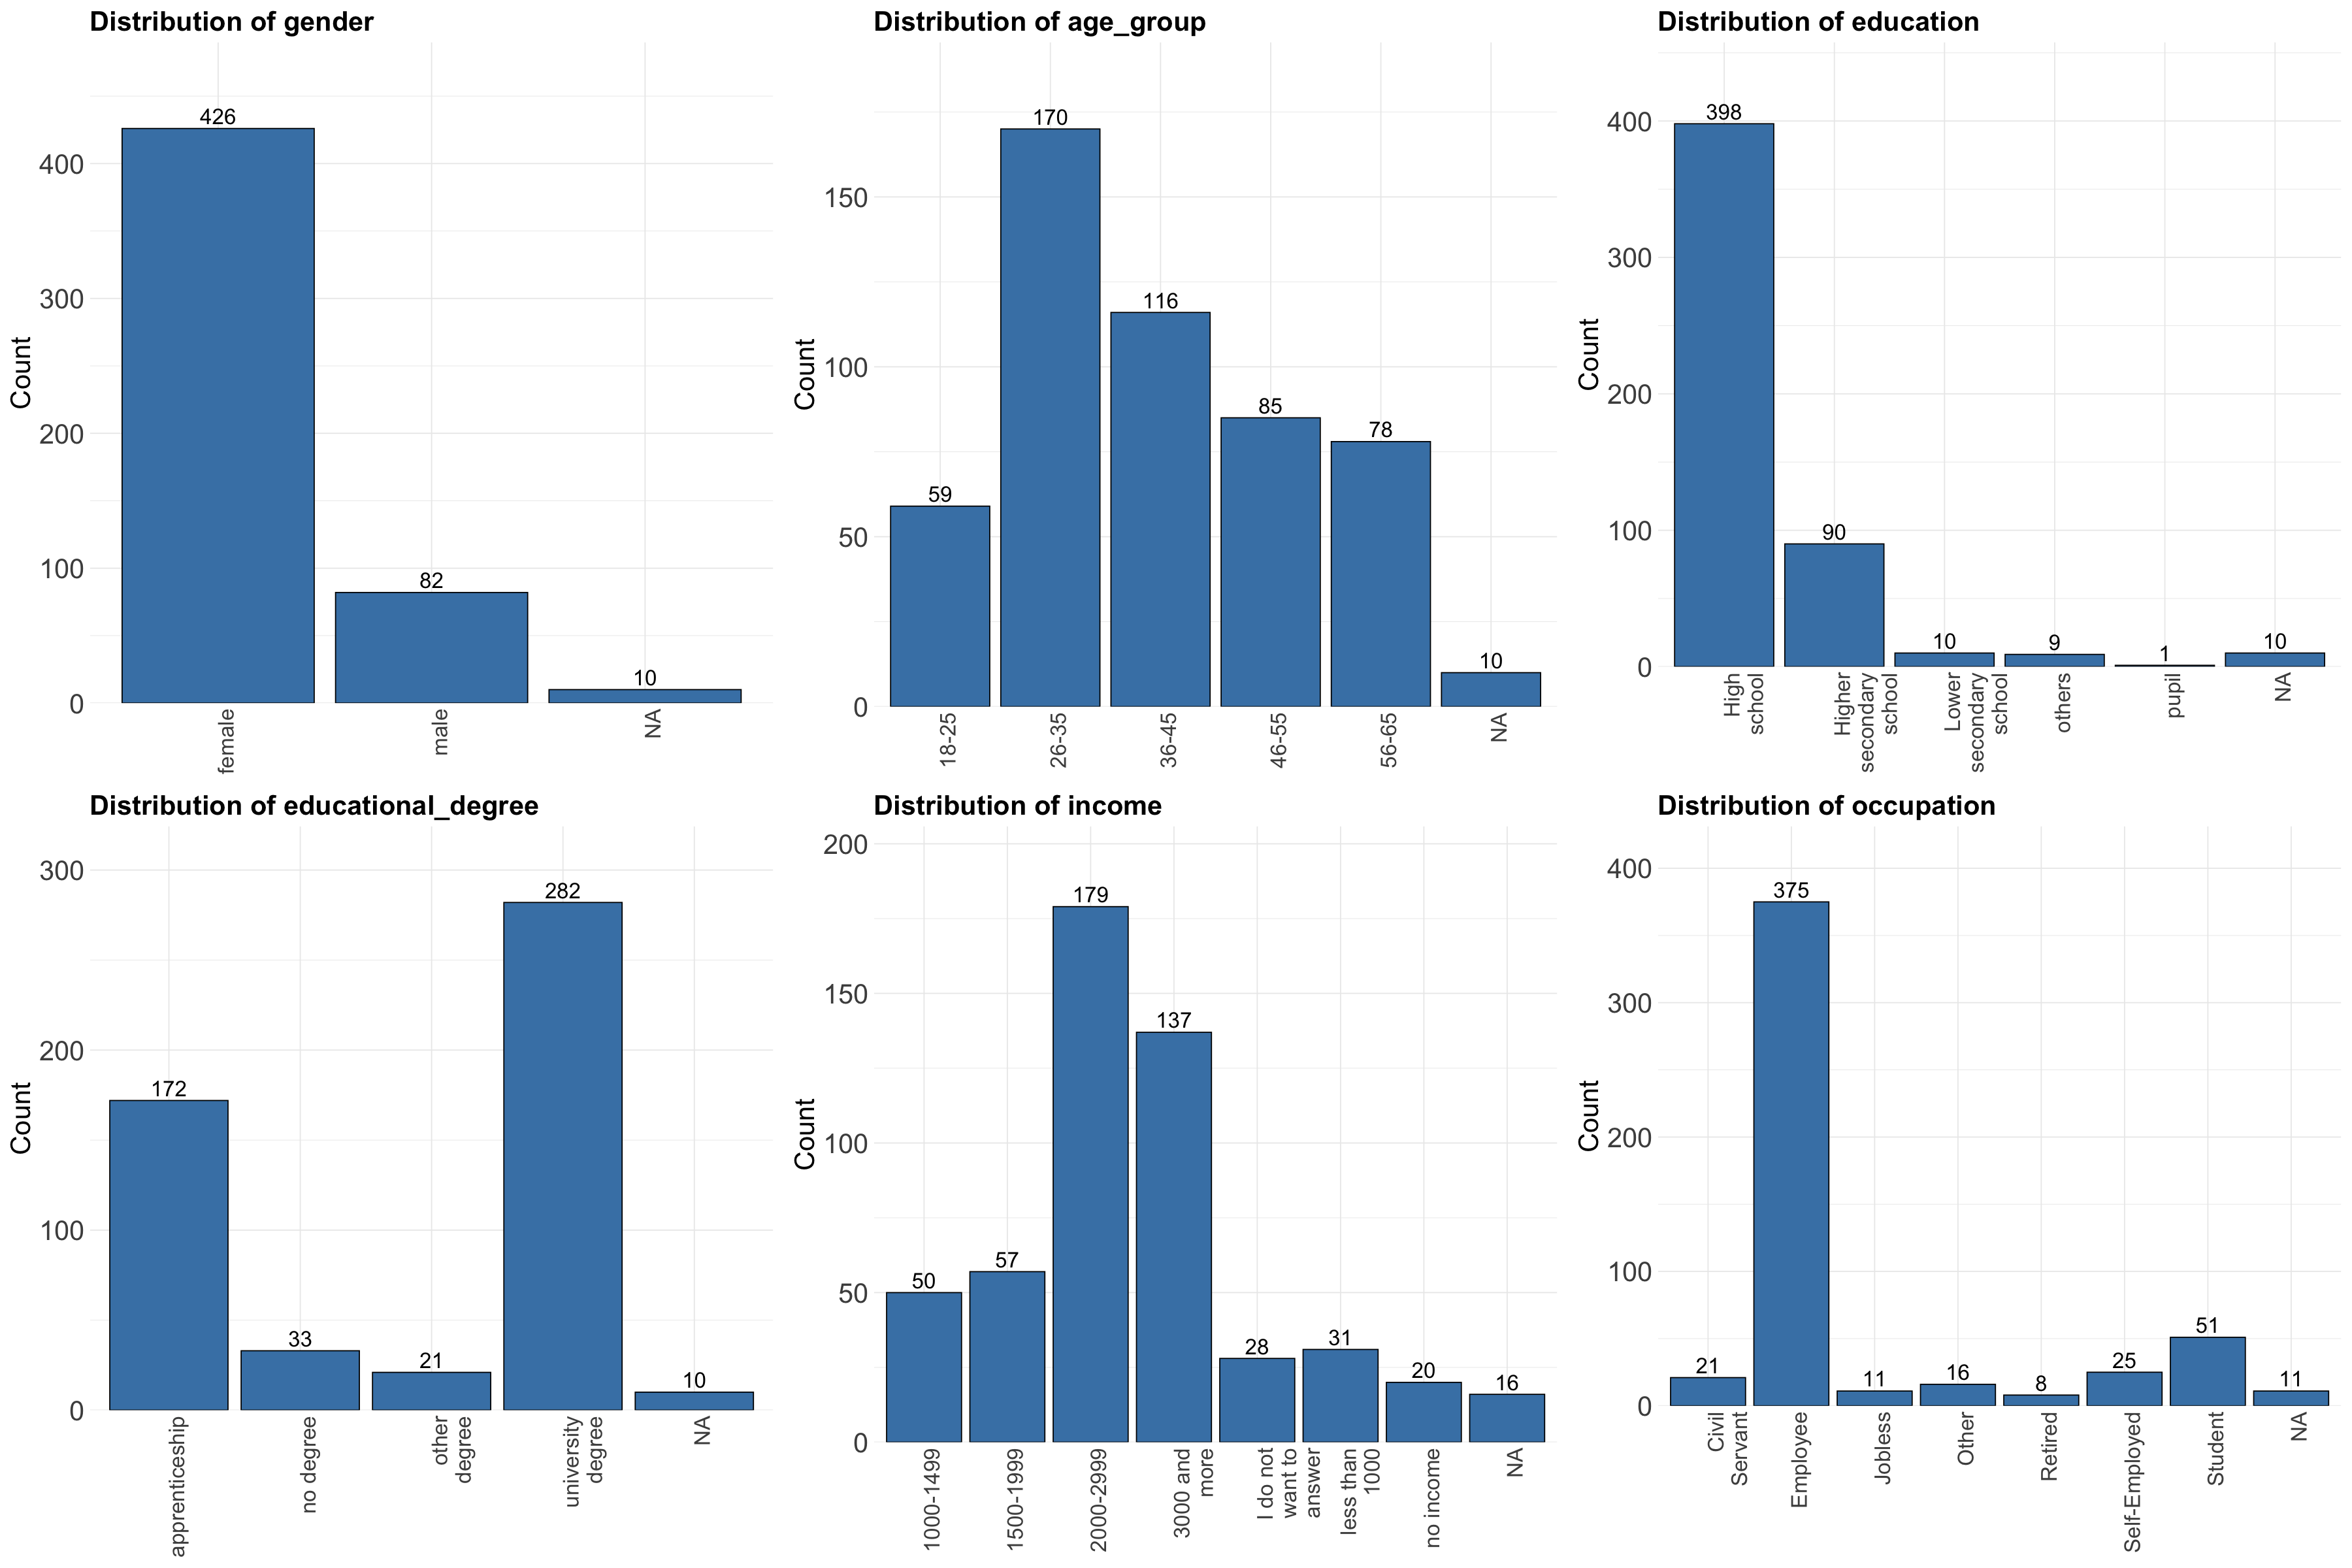

In [30]:
# Create individual plots and store them in a list with adjusted label positions
plots <- lapply(sociodemographic_vars, function(var) {
  ggplot(socio_data, aes(x = .data[[var]])) +
    geom_bar(fill = "steelblue", color = "black") +
    geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.3, size = 7) +  # Place counts just above bars
    theme_minimal() +
    labs(title = paste("Distribution of", var), x = NULL, y = "Count") +  # Suppress x-axis label
    scale_x_discrete(labels = function(x) str_wrap(x, width = 10)) +  # Wrap x-axis labels
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +  # Extend y-axis to leave space for counts
    theme(
      axis.text.x = element_text(angle = 90, hjust = 1, size = 20),  # Adjust x-axis text angle and size
      axis.text.y = element_text(size = 25),  # Adjust y-axis text size
      axis.title.y = element_text(size = 25),  # Adjust y-axis label size
      plot.title = element_text(size = 25, face = "bold"),
      plot.margin = margin(10, 10, 10, 10)  # Add spacing around each plot
    )
})

# Arrange plots in a 3-row, 3-column grid
grid.arrange(grobs = plots, nrow = 2, ncol = 3)

In [31]:
# Increase the width and height of the plot
options(repr.plot.width = 30, repr.plot.height = 7)

# Save the original plot size options
original_width <- getOption("repr.plot.width")
original_height <- getOption("repr.plot.height")

In [32]:
# ------------------------
# FILTER STRESSOR DATA
# ------------------------
stressor_vars <- c("stressor_minors_0to6", "stressor_minor_7to13", "stressor_minor_14above",
                   "stressor_minor_handicapped", "stressor_adult_handicapped", "stressor_shifting_shifts",
                   "stressor_night_shift", "stressor_weekend_work", "stressor_seated_work",
                   "stressor_seated_stood_work", "stressor_physical_work")

In [33]:
# Convert wide format to long format
stress_data_long <- mind %>%
    dplyr::select(all_of(stressor_vars)) %>%
    pivot_longer(cols = everything(), names_to = "stressor", values_to = "response") %>%
    filter(response == "chosen")  # Keep only chosen stressors


In [34]:
# Count occurrences of each stressor
stressor_counts <- stress_data_long %>%
    dplyr::count(stressor, name = "count") %>%
    mutate(stressor = str_replace(stressor, "stressor_", ""))  # Remove 'stressor_' prefix

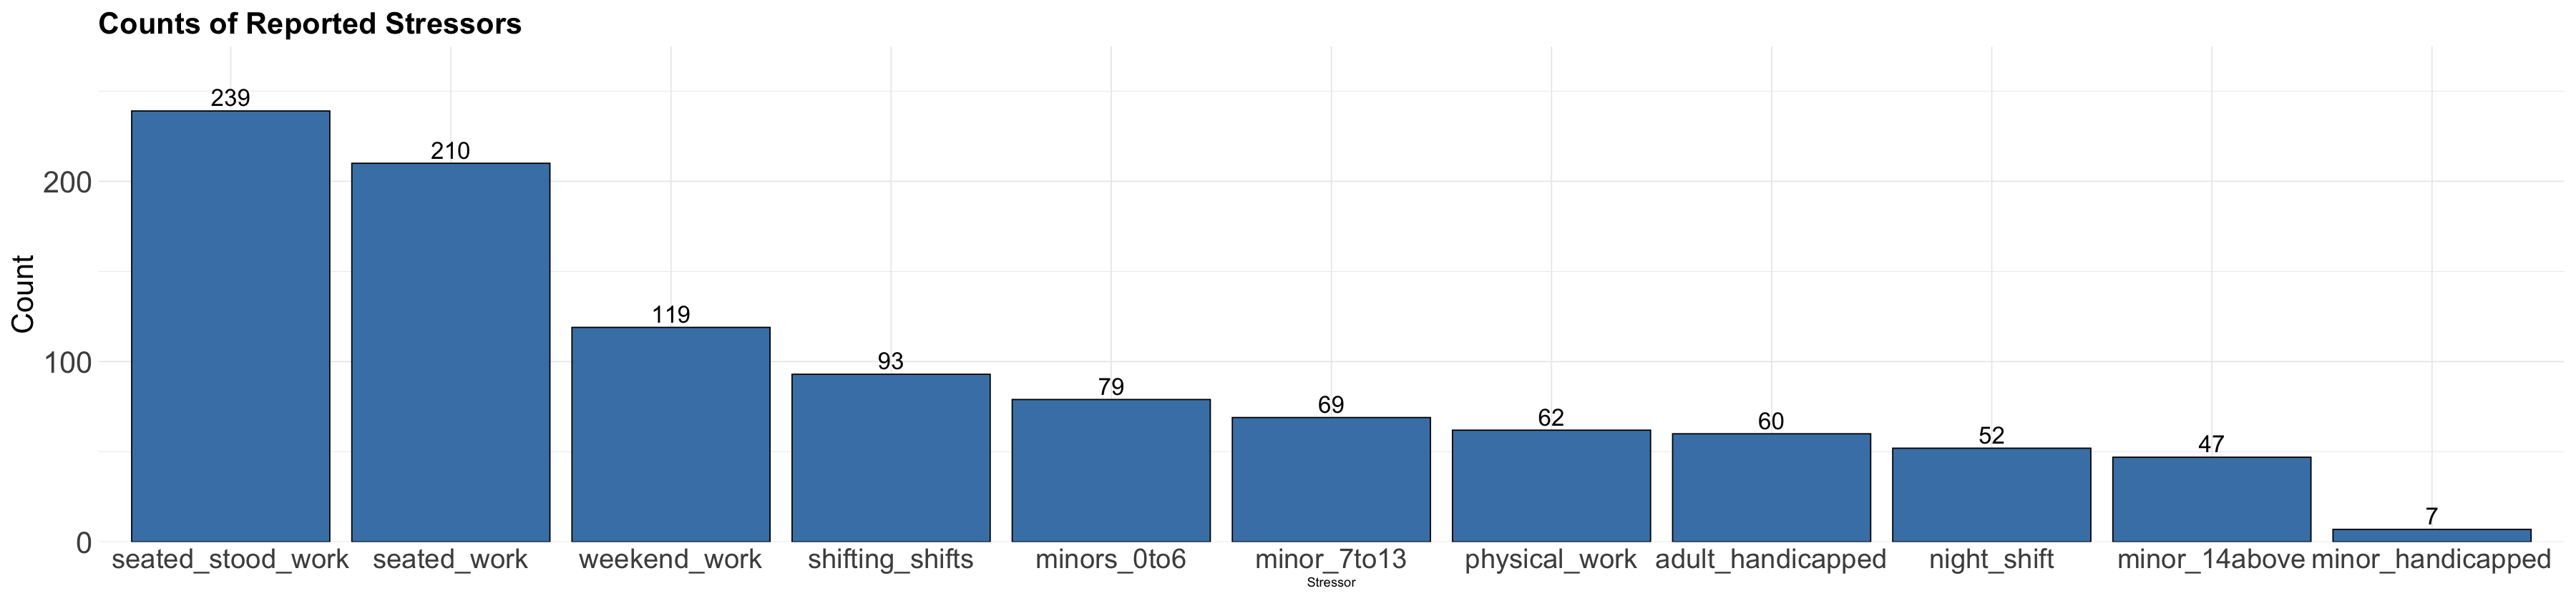

In [35]:
# ------------------------
# CREATE BAR CHART
# ------------------------
ggplot(stressor_counts, aes(x = reorder(stressor, -count), y = count)) +
    geom_bar(stat = "identity", fill = "steelblue", color = "black") +
    geom_text(aes(label = count), vjust = -0.3, size = 7) +  # Place counts above bars
    theme_minimal() +
    labs(title = "Counts of Reported Stressors", x = "Stressor", y = "Count") +
    scale_x_discrete(labels = function(x) str_wrap(x, width = 15)) +  # Wrap labels into multiple rows
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +  # Add space above bars
    theme(
        axis.text.x = element_text(angle = 0, hjust = 0.5, size = 23),  # 0-degree angle, centered
        axis.text.y = element_text(size = 25),
        axis.title.y = element_text(size = 25),
        plot.title = element_text(size = 25, face = "bold"),
        plot.margin = margin(10, 10, 10, 10)
    )

In [36]:
colnames(mind)

[1] "Serial_Nr"                           "Quest_Nr"                           
 [3] "time_started"                        "questions_ended"                    
 [5] "viewer"                              "where_did_the_viewer_ended"         
 [7] "where_did_the_participant_ended"     "proportion_missing_answers"         
 [9] "proportion_missing_answers_weighted" "answering_speed"                    
[11] "my_group"                            "gender"                             
[13] "age_group"                           "education"                          
[15] "educational_degree"                  "income"                             
[17] "stressor_minors_0to6"                "stressor_minor_7to13"               
[19] "stressor_minor_14above"              "stressor_minor_handicapped"         
[21] "stressor_adult_handicapped"          "stressor_shifting_shifts"           
[23] "stressor_night_shift"                "stressor_weekend_work"              
[25] "stressor_seated_work"                "stressor_seated_stood_work"         
[27] "stressor_physical_work"              "relaxation_pmr"                     
[29] "relaxation_aroma"                    "relaxation_yoga"                    
[31] "relaxation_meditation"               "relaxation_massagen"                
[33] "relaxation_sport"                    "relaxation_hypnosis"                
[35] "relaxation_at"                       "relaxation_breathing"               
[37] "relaxation_rest"                     "pre_mood"                           
[39] "pre_emotions"                        "post_mood"                          
[41] "post_emotions"                       "aroma_received"                     
[43] "aroma_tested"                        "occupation"                         
[45] "MDBF_GS"                             "MDBF_WM"                            
[47] "MDBF_RU"                             "MDBF"                               
[49] "pss_helplessness"                    "pss_self_efficacy"                  
[51] "pss_total"                           "who5_total"

In [37]:
# ------------------------
# FILTER RELAXATION DATA
# ------------------------
relaxation_vars <- c("relaxation_pmr", "relaxation_aroma", "relaxation_yoga",
                     "relaxation_meditation", "relaxation_massagen", "relaxation_sport",
                     "relaxation_hypnosis", "relaxation_at", "relaxation_breathing", "relaxation_rest")


In [38]:
# Convert wide format to long format
relaxation_data_long <- mind %>%
    dplyr::select(all_of(relaxation_vars)) %>%
    pivot_longer(cols = everything(), names_to = "relaxation", values_to = "response") %>%
    filter(response == "chosen")  # Keep only chosen relaxation techniques


In [39]:
# Count occurrences of each relaxation technique
relaxation_counts <- relaxation_data_long %>%
    dplyr::count(relaxation, name = "count") %>%
    mutate(relaxation = str_replace(relaxation, "relaxation_", ""))  # Remove 'relaxation_' prefix


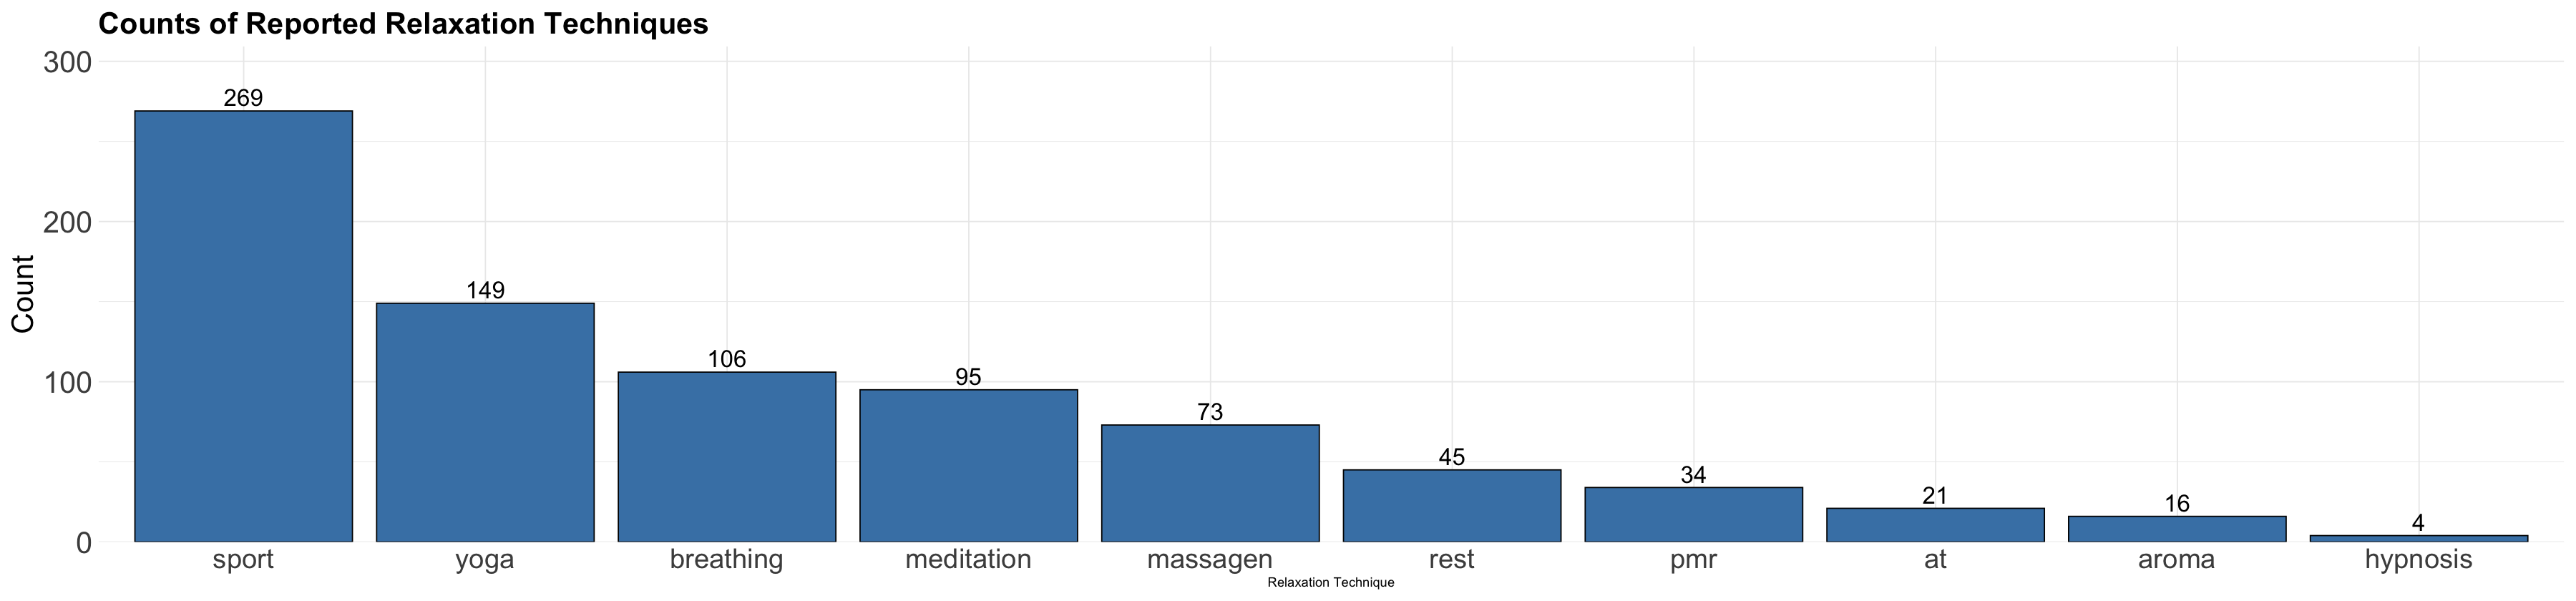

In [40]:
# ------------------------
# CREATE BAR CHART
# ------------------------
ggplot(relaxation_counts, aes(x = reorder(relaxation, -count), y = count)) +
    geom_bar(stat = "identity", fill = "steelblue", color = "black") +
    geom_text(aes(label = count), vjust = -0.3, size = 7) +  # Place counts above bars
    theme_minimal() +
    labs(title = "Counts of Reported Relaxation Techniques", x = "Relaxation Technique", y = "Count") +
    scale_x_discrete(labels = function(x) str_wrap(x, width = 15)) +  # Wrap labels into multiple rows
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +  # Add space above bars
    theme(
        axis.text.x = element_text(angle = 0, hjust = 0.5, size = 23),  # 0-degree angle, centered
        axis.text.y = element_text(size = 25),
        axis.title.y = element_text(size = 25),
        plot.title = element_text(size = 25, face = "bold"),
        plot.margin = margin(10, 10, 10, 10)
    )

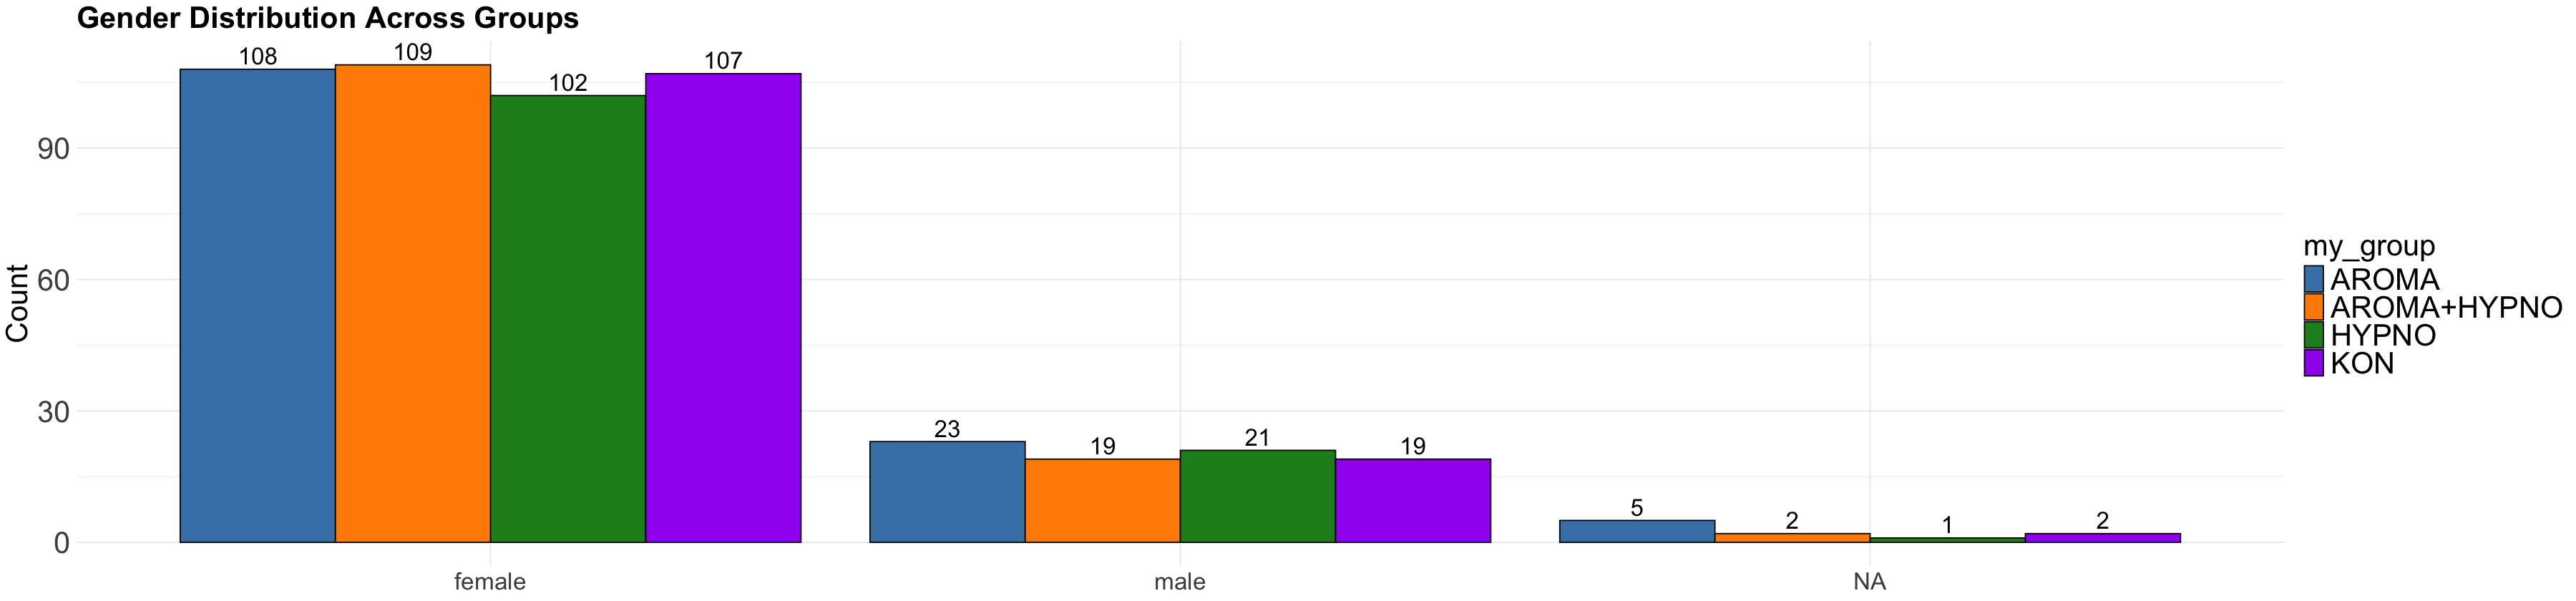

In [41]:
# Create the grouped bar plot for gender distribution across `my_group`
ggplot(socio_data, aes(x = gender, fill = my_group)) +
  geom_bar(position = "dodge", color = "black") +  # Grouped bars with color borders
  geom_text(stat = "count", aes(label = after_stat(count)), 
            position = position_dodge(width = 0.9), vjust = -0.3, size = 7) +  # Add counts above bars
  theme_minimal() +
  labs(title = "Gender Distribution Across Groups", x = NULL, y = "Count") +
  scale_fill_manual(values = c("AROMA" = "steelblue", "AROMA+HYPNO" = "darkorange", 
                               "HYPNO" = "forestgreen", "KON" = "purple")) +  # Custom colors for clarity
  theme(
    axis.text.x = element_text(size = 20, angle = 0),  # Adjust x-axis text size
    axis.text.y = element_text(size = 25),  # Adjust y-axis text size
    axis.title.x = element_text(size = 25),  # Adjust x-axis label size
    axis.title.y = element_text(size = 25),  # Adjust y-axis label size
    plot.title = element_text(size = 25, face = "bold"),
    legend.title = element_text(size = 25),  # Legend title size
    legend.text = element_text(size = 25)  # Legend text size
  )

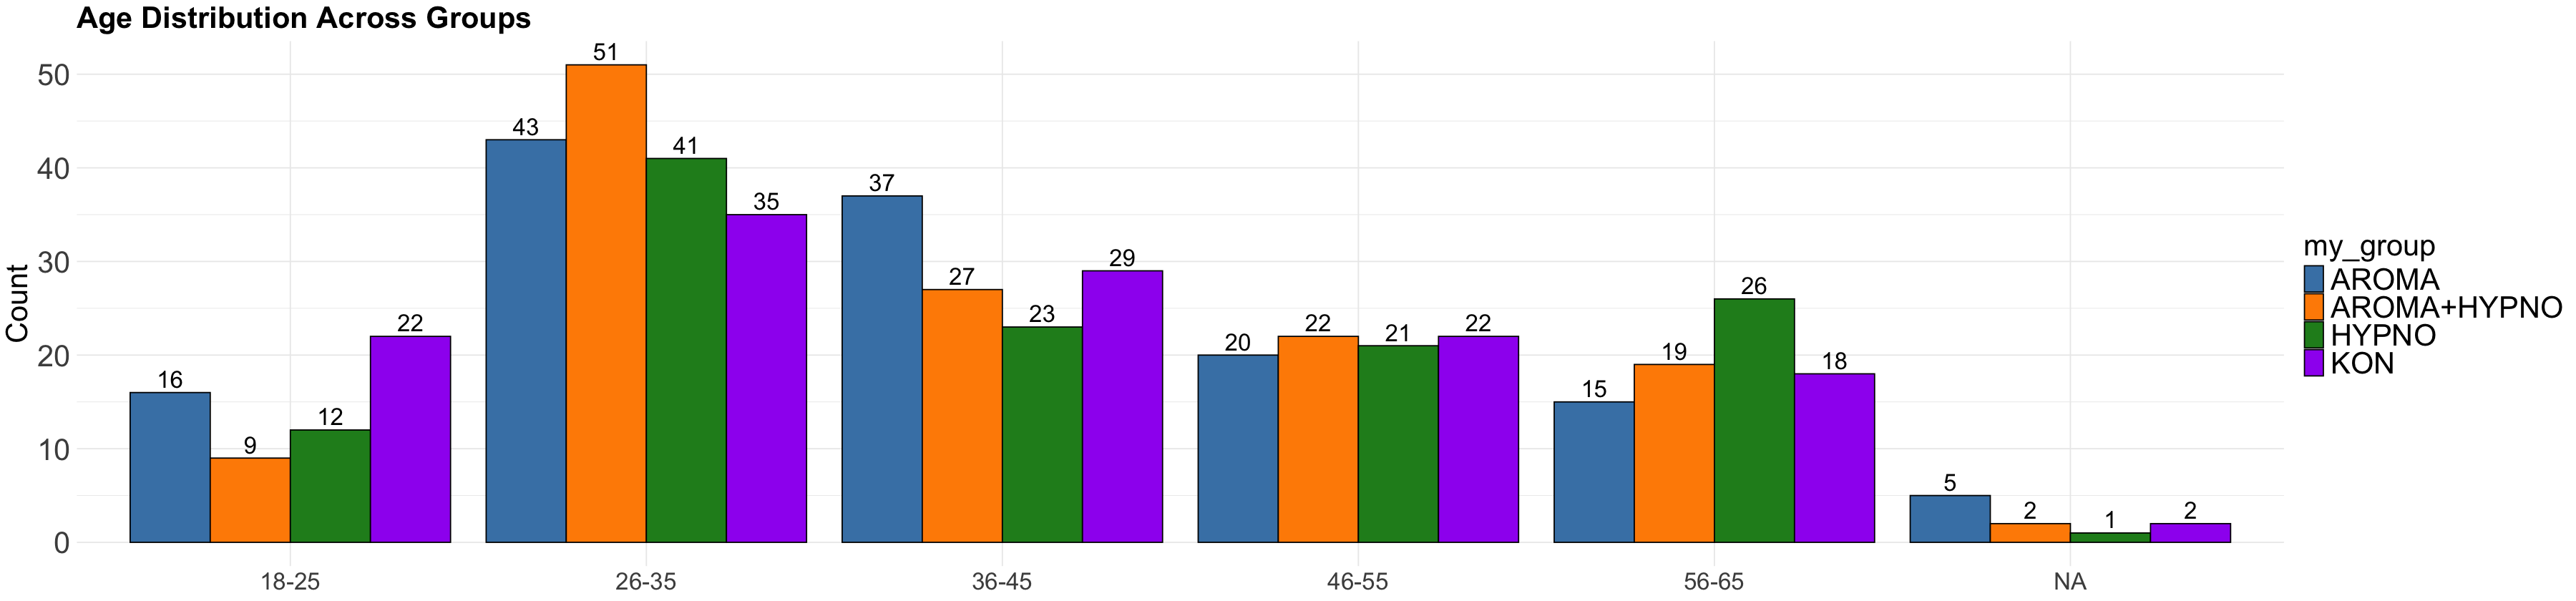

In [42]:
# Create the grouped bar plot for age distribution across `my_group`
ggplot(socio_data, aes(x = age_group, fill = my_group)) +
  geom_bar(position = "dodge", color = "black") +  # Grouped bars with color borders
  geom_text(stat = "count", aes(label = after_stat(count)), 
            position = position_dodge(width = 0.9), vjust = -0.3, size = 7) +  # Add counts above bars
  theme_minimal() +
  labs(title = "Age Distribution Across Groups", x = NULL, y = "Count") +
  scale_fill_manual(values = c("AROMA" = "steelblue", "AROMA+HYPNO" = "darkorange", 
                               "HYPNO" = "forestgreen", "KON" = "purple")) +  # Custom colors for clarity
  theme(
    axis.text.x = element_text(size = 20, angle = 0),  # Adjust x-axis text size
    axis.text.y = element_text(size = 25),  # Adjust y-axis text size
    axis.title.x = element_text(size = 25),  # Adjust x-axis label size
    axis.title.y = element_text(size = 25),  # Adjust y-axis label size
    plot.title = element_text(size = 25, face = "bold"),
    legend.title = element_text(size = 25),  # Legend title size
    legend.text = element_text(size = 25)  # Legend text size
  )

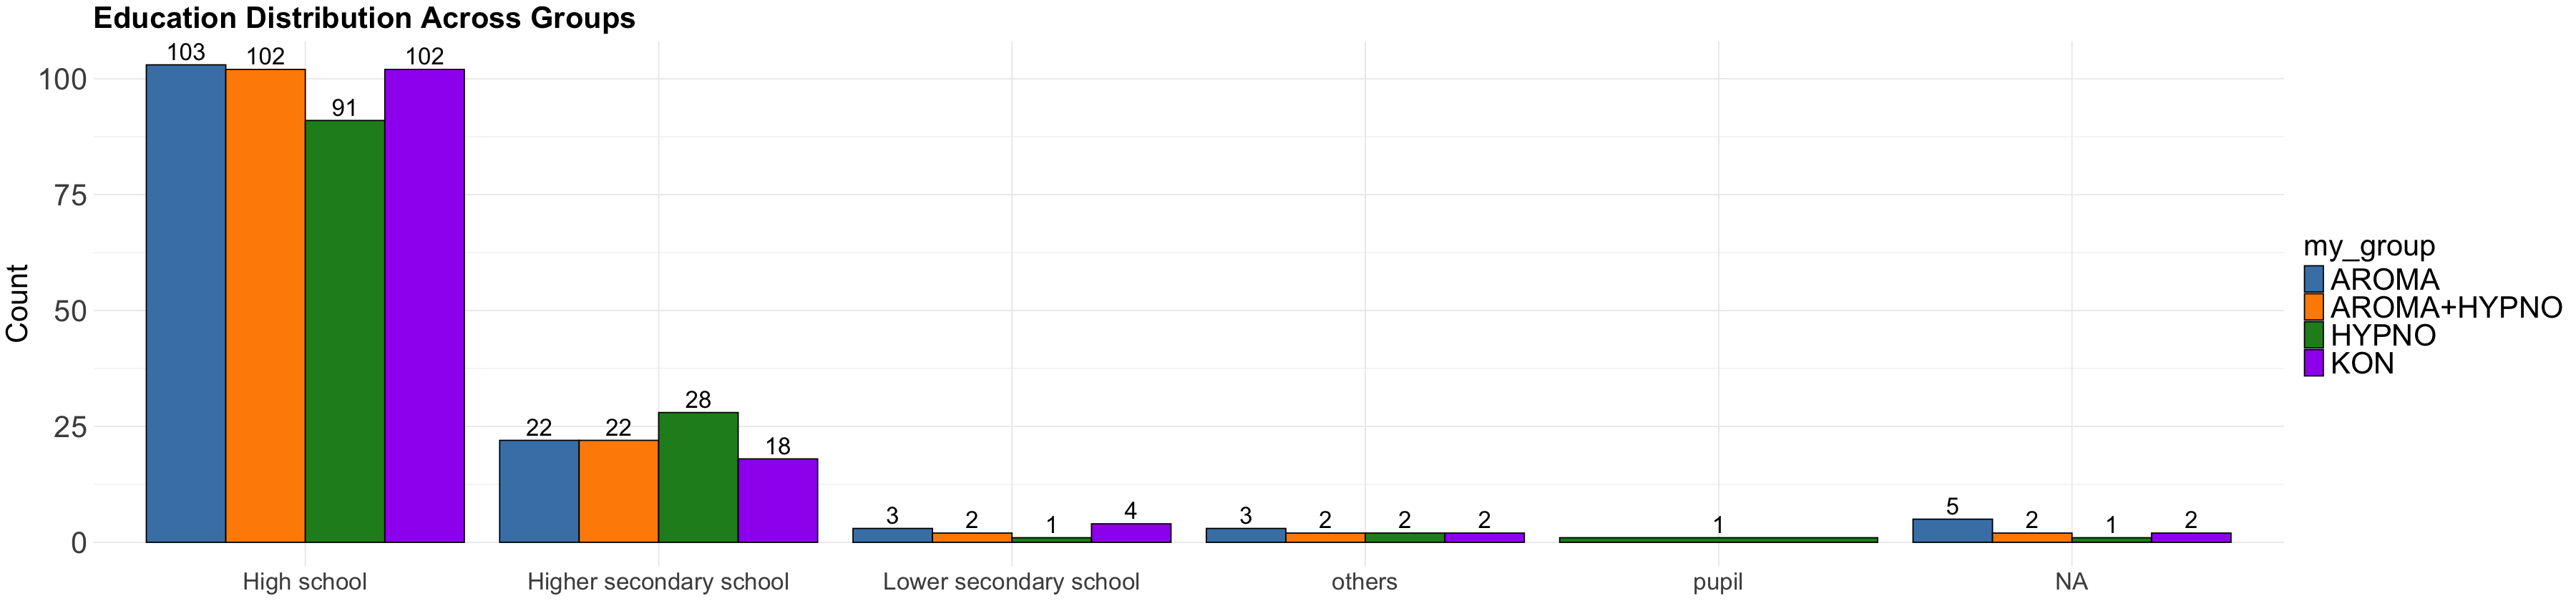

In [43]:
# Create the grouped bar plot for age distribution across `my_group`
ggplot(socio_data, aes(x = education, fill = my_group)) +
  geom_bar(position = "dodge", color = "black") +  # Grouped bars with color borders
  geom_text(stat = "count", aes(label = after_stat(count)), 
            position = position_dodge(width = 0.9), vjust = -0.3, size = 7) +  # Add counts above bars
  theme_minimal() +
  labs(title = "Education Distribution Across Groups", x = NULL, y = "Count") +
  scale_fill_manual(values = c("AROMA" = "steelblue", "AROMA+HYPNO" = "darkorange", 
                               "HYPNO" = "forestgreen", "KON" = "purple")) +  # Custom colors for clarity
  theme(
    axis.text.x = element_text(size = 20, angle = 0),  # Adjust x-axis text size
    axis.text.y = element_text(size = 25),  # Adjust y-axis text size
    axis.title.x = element_text(size = 25),  # Adjust x-axis label size
    axis.title.y = element_text(size = 25),  # Adjust y-axis label size
    plot.title = element_text(size = 25, face = "bold"),
    legend.title = element_text(size = 25),  # Legend title size
    legend.text = element_text(size = 25)  # Legend text size
  )

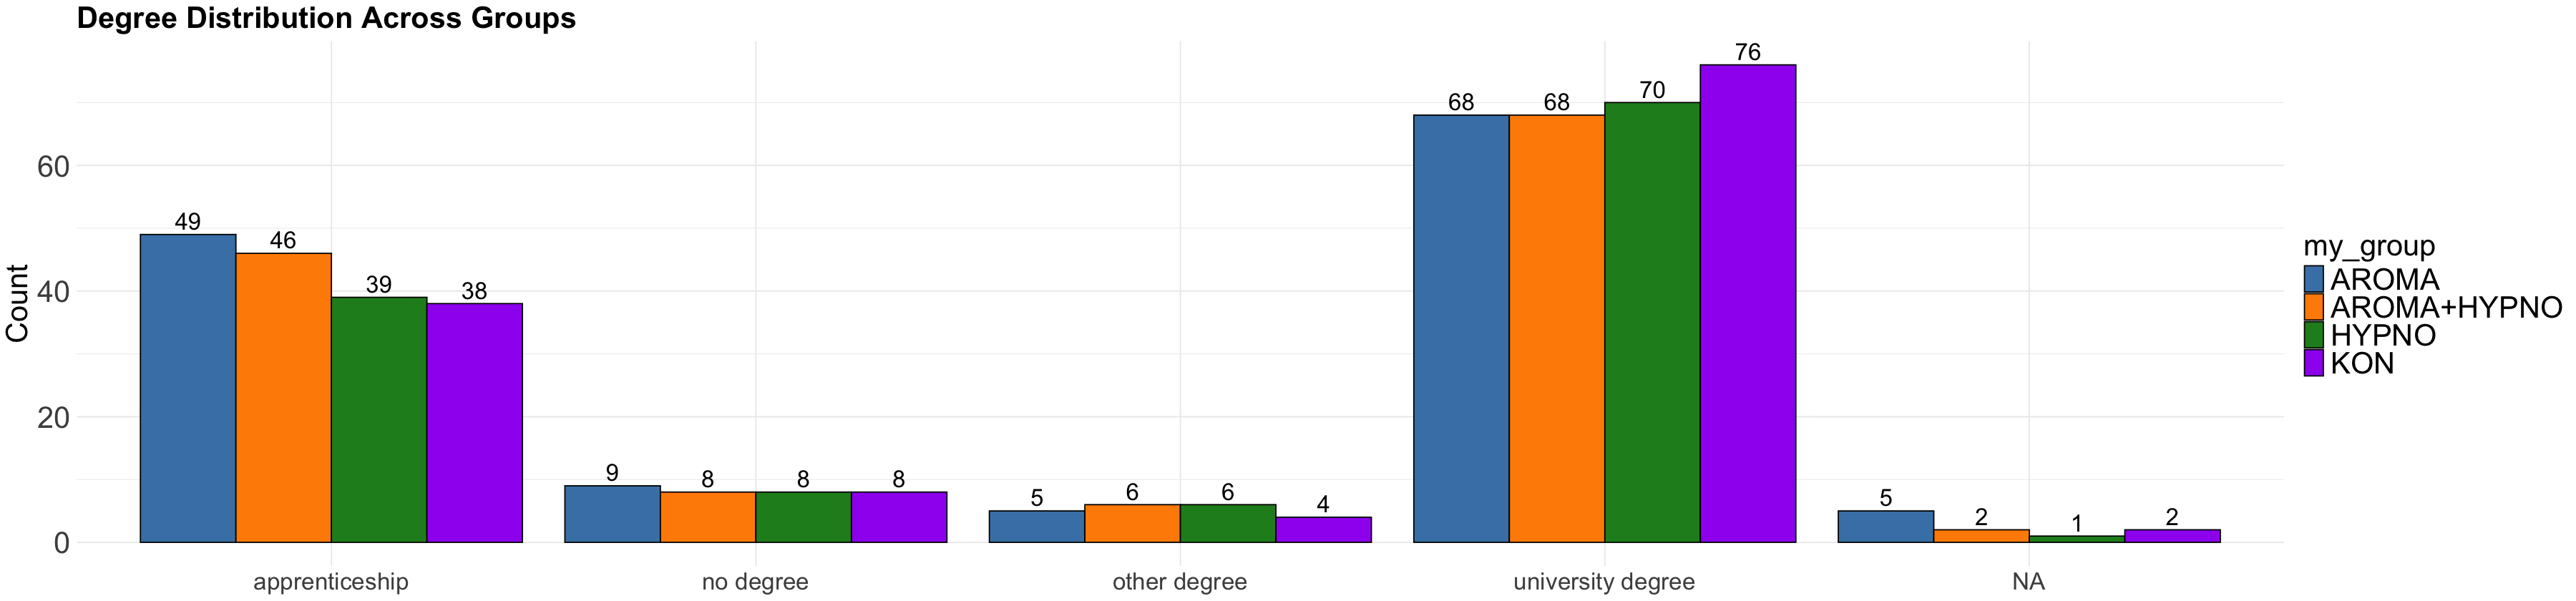

In [44]:
# Create the grouped bar plot for age distribution across `my_group`
ggplot(socio_data, aes(x = educational_degree, fill = my_group)) +
  geom_bar(position = "dodge", color = "black") +  # Grouped bars with color borders
  geom_text(stat = "count", aes(label = after_stat(count)), 
            position = position_dodge(width = 0.9), vjust = -0.3, size = 7) +  # Add counts above bars
  theme_minimal() +
  labs(title = "Degree Distribution Across Groups", x = NULL, y = "Count") +
  scale_fill_manual(values = c("AROMA" = "steelblue", "AROMA+HYPNO" = "darkorange", 
                               "HYPNO" = "forestgreen", "KON" = "purple")) +  # Custom colors for clarity
  theme(
    axis.text.x = element_text(size = 20, angle = 0),  # Adjust x-axis text size
    axis.text.y = element_text(size = 25),  # Adjust y-axis text size
    axis.title.x = element_text(size = 25),  # Adjust x-axis label size
    axis.title.y = element_text(size = 25),  # Adjust y-axis label size
    plot.title = element_text(size = 25, face = "bold"),
    legend.title = element_text(size = 25),  # Legend title size
    legend.text = element_text(size = 25)  # Legend text size
  )

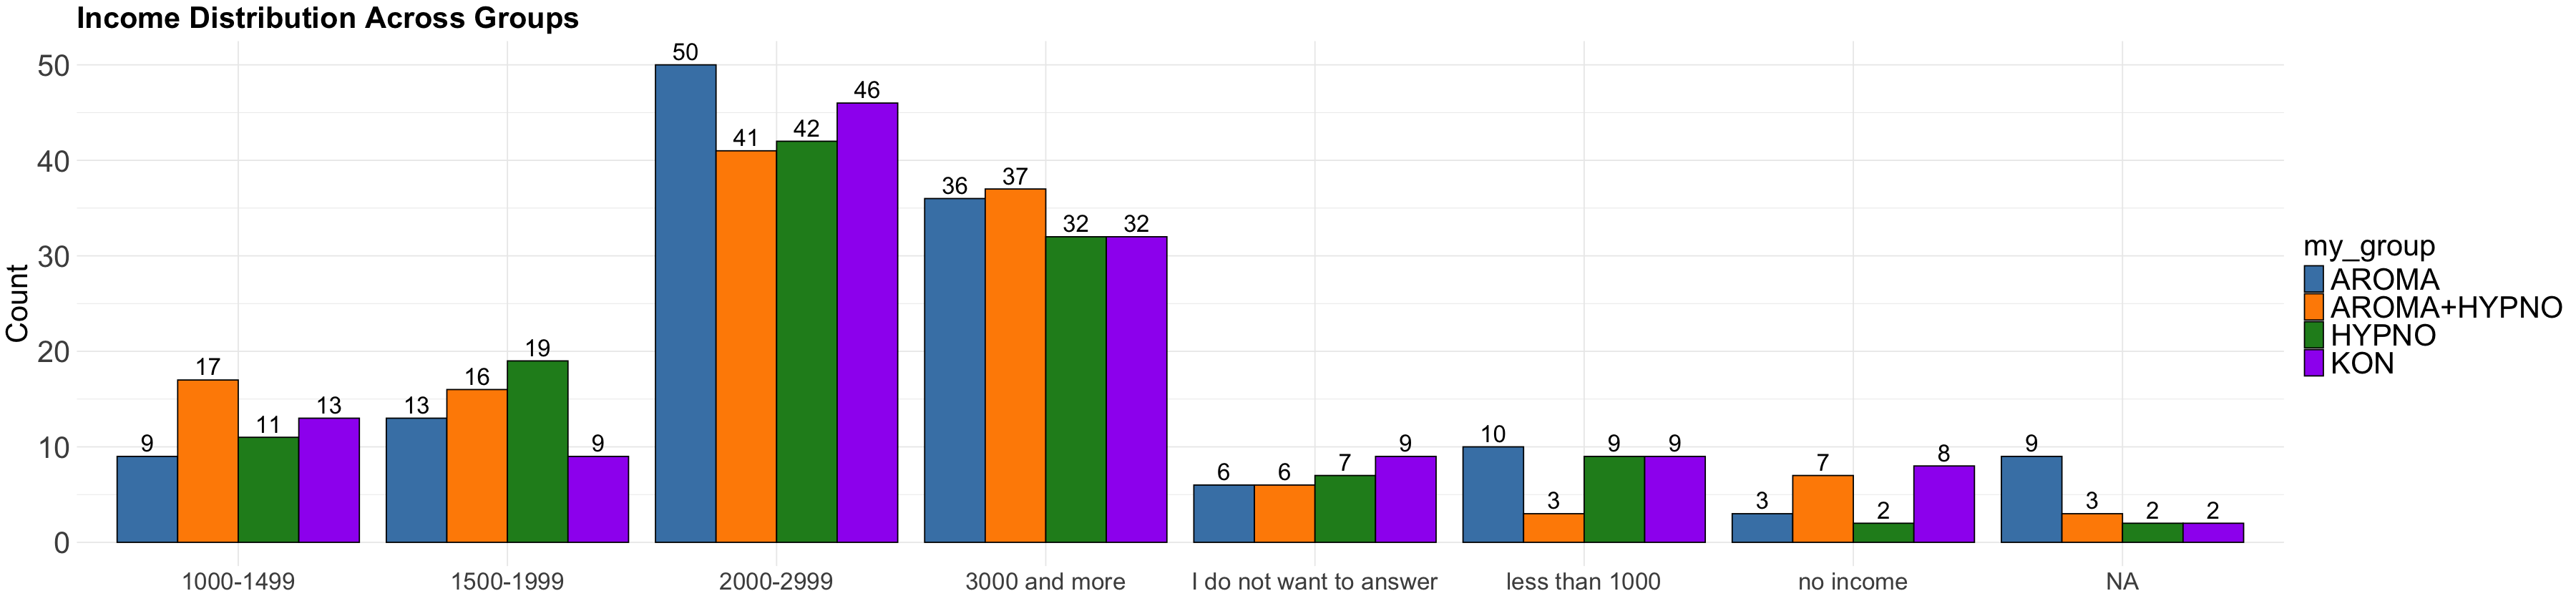

In [45]:
# Create the grouped bar plot for age distribution across `my_group`
ggplot(socio_data, aes(x = income, fill = my_group)) +
  geom_bar(position = "dodge", color = "black") +  # Grouped bars with color borders
  geom_text(stat = "count", aes(label = after_stat(count)), 
            position = position_dodge(width = 0.9), vjust = -0.3, size = 7) +  # Add counts above bars
  theme_minimal() +
  labs(title = "Income Distribution Across Groups", x = NULL, y = "Count") +
  scale_fill_manual(values = c("AROMA" = "steelblue", "AROMA+HYPNO" = "darkorange", 
                               "HYPNO" = "forestgreen", "KON" = "purple")) +  # Custom colors for clarity
  theme(
    axis.text.x = element_text(size = 20, angle = 0),  # Adjust x-axis text size
    axis.text.y = element_text(size = 25),  # Adjust y-axis text size
    axis.title.x = element_text(size = 25),  # Adjust x-axis label size
    axis.title.y = element_text(size = 25),  # Adjust y-axis label size
    plot.title = element_text(size = 25, face = "bold"),
    legend.title = element_text(size = 25),  # Legend title size
    legend.text = element_text(size = 25)  # Legend text size
  )

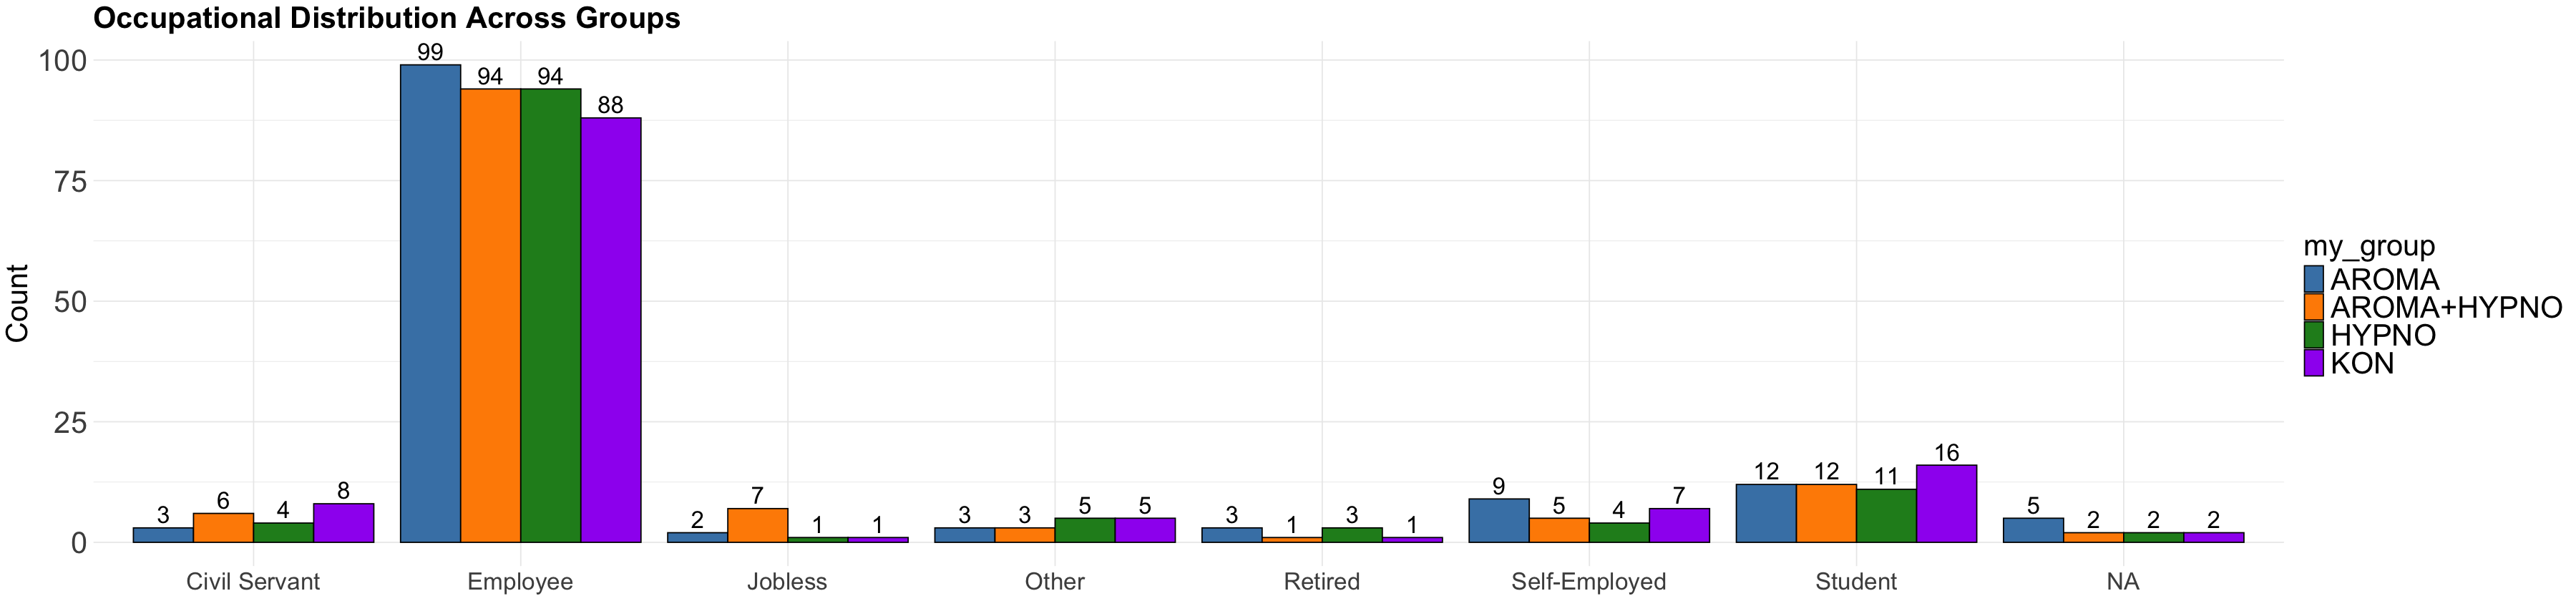

In [46]:
# Create the grouped bar plot for age distribution across `my_group`
ggplot(socio_data, aes(x = occupation, fill = my_group)) +
  geom_bar(position = "dodge", color = "black") +  # Grouped bars with color borders
  geom_text(stat = "count", aes(label = after_stat(count)), 
            position = position_dodge(width = 0.9), vjust = -0.3, size = 7) +  # Add counts above bars
  theme_minimal() +
  labs(title = "Occupational Distribution Across Groups", x = NULL, y = "Count") +
  scale_fill_manual(values = c("AROMA" = "steelblue", "AROMA+HYPNO" = "darkorange", 
                               "HYPNO" = "forestgreen", "KON" = "purple")) +  # Custom colors for clarity
  theme(
    axis.text.x = element_text(size = 20, angle = 0),  # Adjust x-axis text size
    axis.text.y = element_text(size = 25),  # Adjust y-axis text size
    axis.title.x = element_text(size = 25),  # Adjust x-axis label size
    axis.title.y = element_text(size = 25),  # Adjust y-axis label size
    plot.title = element_text(size = 25, face = "bold"),
    legend.title = element_text(size = 25),  # Legend title size
    legend.text = element_text(size = 25)  # Legend text size
  )

In [47]:
# Convert wide format to long format, keeping "my_group"
stress_data_long <- mind %>%
    dplyr::select(my_group, all_of(stressor_vars)) %>%
    pivot_longer(cols = -my_group, names_to = "stressor", values_to = "response") %>%
    filter(response == "chosen")  # Keep only chosen stressors

In [48]:
# Count occurrences of each stressor per group
stressor_counts <- stress_data_long %>%
    dplyr::count(stressor, my_group, name = "count") %>%
    mutate(stressor = str_replace(stressor, "stressor_", ""))  # Remove 'stressor_' prefix


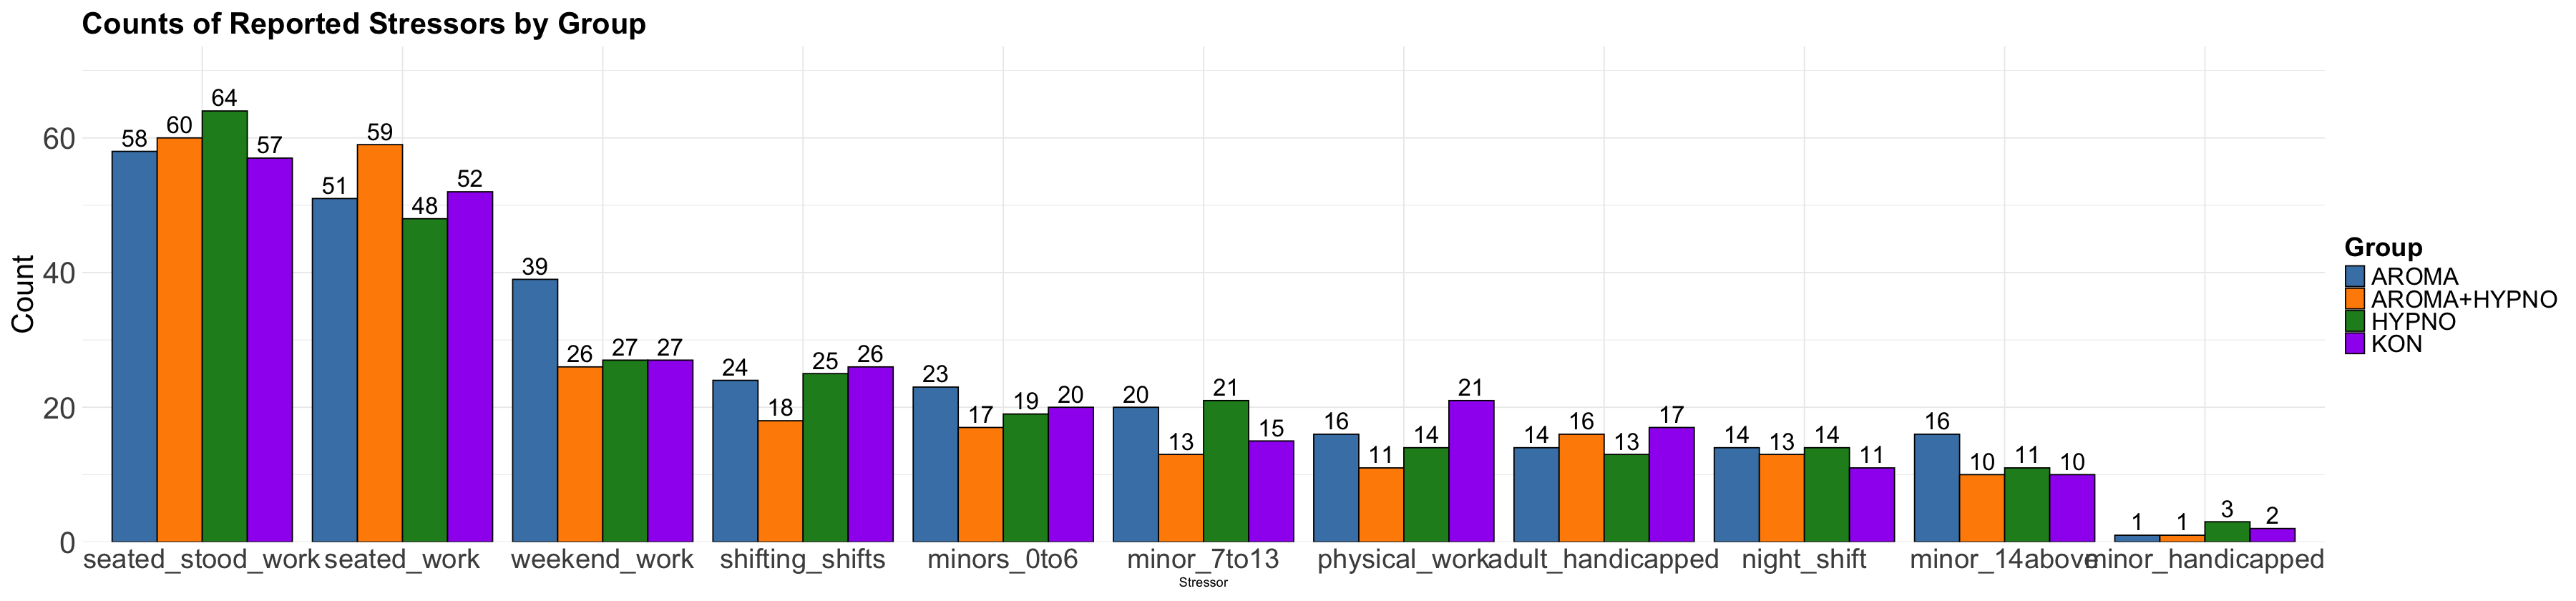

In [49]:
# ------------------------
# CREATE GROUPED BAR CHART
# ------------------------
ggplot(stressor_counts, aes(x = reorder(stressor, -count), y = count, fill = my_group)) +
    geom_bar(stat = "identity", position = "dodge", color = "black") +
    geom_text(aes(label = count), position = position_dodge(width = 0.9), vjust = -0.3, size = 7) +  
    theme_minimal() +
    labs(title = "Counts of Reported Stressors by Group", x = "Stressor", y = "Count", fill = "Group") +
    scale_x_discrete(labels = function(x) str_wrap(x, width = 15)) +  
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +  
    scale_fill_manual(values = c("AROMA" = "steelblue", "AROMA+HYPNO" = "darkorange", 
                                 "HYPNO" = "forestgreen", "KON" = "purple")) +  # Custom colors
    theme(
        axis.text.x = element_text(angle = 0, hjust = 0.5, size = 23),
        axis.text.y = element_text(size = 25),
        axis.title.y = element_text(size = 25),
        plot.title = element_text(size = 25, face = "bold"),
        plot.margin = margin(10, 10, 10, 10),
        legend.text = element_text(size = 20),
        legend.title = element_text(size = 22, face = "bold")
    )

In [50]:
# Convert wide format to long format, keeping "my_group"
relaxation_data_long <- mind %>%
    dplyr::select(my_group, all_of(relaxation_vars)) %>%
    pivot_longer(cols = -my_group, names_to = "relaxation", values_to = "response") %>%
    filter(response == "chosen")  # Keep only chosen relaxation techniques


In [51]:
# Count occurrences of each relaxation technique per group
relaxation_counts <- relaxation_data_long %>%
    dplyr::count(relaxation, my_group, name = "count") %>%
    mutate(relaxation = str_replace(relaxation, "relaxation_", ""))  # Remove 'relaxation_' prefix


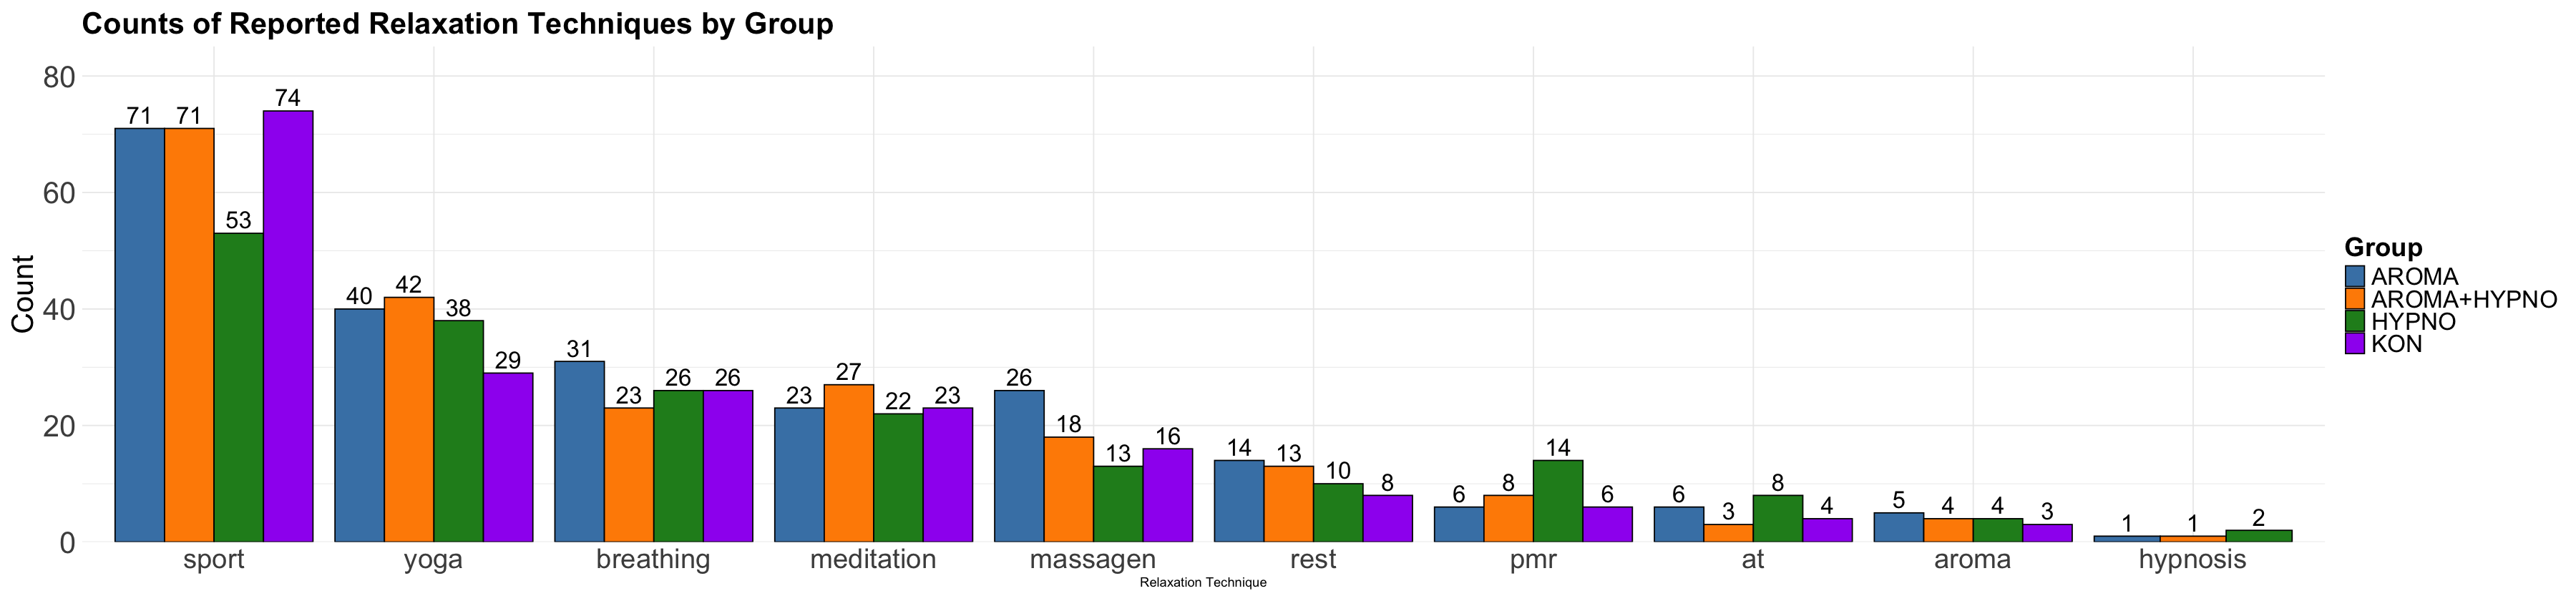

In [52]:
# ------------------------
# CREATE GROUPED BAR CHART
# ------------------------
ggplot(relaxation_counts, aes(x = reorder(relaxation, -count), y = count, fill = my_group)) +
    geom_bar(stat = "identity", position = "dodge", color = "black") +
    geom_text(aes(label = count), position = position_dodge(width = 0.9), vjust = -0.3, size = 7) +  
    theme_minimal() +
    labs(title = "Counts of Reported Relaxation Techniques by Group", x = "Relaxation Technique", y = "Count", fill = "Group") +
    scale_x_discrete(labels = function(x) str_wrap(x, width = 15)) +  
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +  
    scale_fill_manual(values = c("AROMA" = "steelblue", "AROMA+HYPNO" = "darkorange", 
                                 "HYPNO" = "forestgreen", "KON" = "purple")) +  # Custom colors
    theme(
        axis.text.x = element_text(angle = 0, hjust = 0.5, size = 23),
        axis.text.y = element_text(size = 25),
        axis.title.y = element_text(size = 25),
        plot.title = element_text(size = 25, face = "bold"),
        plot.margin = margin(10, 10, 10, 10),
        legend.text = element_text(size = 20),
        legend.title = element_text(size = 22, face = "bold")
    )

In [53]:
# Total number of participants per group
total_per_group <- socio_data %>%
  filter(my_group != "ADMIN") %>%
  group_by(my_group) %>%
  dplyr::summarise(total_n = n(), .groups = "drop")

print("Total number of participants per group:")
print(total_per_group)

[1] "Total number of participants per group:"
# A tibble: 4 x 2
  my_group    total_n
  <fct>         <int>
1 AROMA           136
2 AROMA+HYPNO     130
3 HYPNO           124
4 KON             128


In [54]:
# Compute gender distribution with correct percentages
gender_per_group <- socio_data %>%
  group_by(my_group, gender) %>%
  dplyr::summarise(n = n(), .groups = "drop") %>%
  left_join(total_per_group, by = "my_group") %>%  # Merge total count per group
  mutate(percent = (n / total_n) * 100) %>%  # Correct percentage calculation
  dplyr::select(my_group, gender, n, percent)  # Keep only relevant columns

# Print the correctly calculated table
print("Gender Distribution Per Group:")
print(gender_per_group, n = Inf)  # Print all rows

[1] "Gender Distribution Per Group:"
# A tibble: 12 x 4
   my_group    gender     n percent
   <fct>       <fct>  <int>   <dbl>
 1 AROMA       female   108  79.4  
 2 AROMA       male      23  16.9  
 3 AROMA       NA         5   3.68 
 4 AROMA+HYPNO female   109  83.8  
 5 AROMA+HYPNO male      19  14.6  
 6 AROMA+HYPNO NA         2   1.54 
 7 HYPNO       female   102  82.3  
 8 HYPNO       male      21  16.9  
 9 HYPNO       NA         1   0.806
10 KON         female   107  83.6  
11 KON         male      19  14.8  
12 KON         NA         2   1.56 


In [55]:
# Age group per group
age_per_group <- socio_data %>%
  group_by(my_group, age_group) %>%
  dplyr::summarise(n = n(), .groups = "drop") %>%
  left_join(total_per_group, by = "my_group") %>%  # Merge total count per group
  mutate(percent = (n / total_n) * 100) %>%  # Correct percentage calculation
  dplyr::select(my_group, age_group, n, percent)  # Keep only relevant columns

# Print the correctly calculated table
print("Age Distribution Per Group:")
print(age_per_group, n = Inf)  # Print all rows

[1] "Age Distribution Per Group:"
# A tibble: 24 x 4
   my_group    age_group     n percent
   <fct>       <fct>     <int>   <dbl>
 1 AROMA       18-25        16  11.8  
 2 AROMA       26-35        43  31.6  
 3 AROMA       36-45        37  27.2  
 4 AROMA       46-55        20  14.7  
 5 AROMA       56-65        15  11.0  
 6 AROMA       NA            5   3.68 
 7 AROMA+HYPNO 18-25         9   6.92 
 8 AROMA+HYPNO 26-35        51  39.2  
 9 AROMA+HYPNO 36-45        27  20.8  
10 AROMA+HYPNO 46-55        22  16.9  
11 AROMA+HYPNO 56-65        19  14.6  
12 AROMA+HYPNO NA            2   1.54 
13 HYPNO       18-25        12   9.68 
14 HYPNO       26-35        41  33.1  
15 HYPNO       36-45        23  18.5  
16 HYPNO       46-55        21  16.9  
17 HYPNO       56-65        26  21.0  
18 HYPNO       NA            1   0.806
19 KON         18-25        22  17.2  
20 KON         26-35        35  27.3  
21 KON         36-45        29  22.7  
22 KON         46-55        22  17.2  
23 KON     

In [56]:
# Age group per group
education_per_group <- socio_data %>%
  group_by(my_group, education) %>%
  dplyr::summarise(n = n(), .groups = "drop") %>%
  left_join(total_per_group, by = "my_group") %>%  # Merge total count per group
  mutate(percent = (n / total_n) * 100) %>%  # Correct percentage calculation
  dplyr::select(my_group, education, n, percent)  # Keep only relevant columns

# Print the correctly calculated table
print("Education Distribution Per Group:")
print(education_per_group, n = Inf)  # Print all rows

[1] "Education Distribution Per Group:"
# A tibble: 21 x 4
   my_group    education                   n percent
   <fct>       <fct>                   <int>   <dbl>
 1 AROMA       High school               103  75.7  
 2 AROMA       Higher secondary school    22  16.2  
 3 AROMA       Lower secondary school      3   2.21 
 4 AROMA       others                      3   2.21 
 5 AROMA       NA                          5   3.68 
 6 AROMA+HYPNO High school               102  78.5  
 7 AROMA+HYPNO Higher secondary school    22  16.9  
 8 AROMA+HYPNO Lower secondary school      2   1.54 
 9 AROMA+HYPNO others                      2   1.54 
10 AROMA+HYPNO NA                          2   1.54 
11 HYPNO       High school                91  73.4  
12 HYPNO       Higher secondary school    28  22.6  
13 HYPNO       Lower secondary school      1   0.806
14 HYPNO       others                      2   1.61 
15 HYPNO       pupil                       1   0.806
16 HYPNO       NA                       

In [57]:
# Educational_degree group per group
education_degree_per_group <- socio_data %>%
  group_by(my_group, educational_degree) %>%
  dplyr::summarise(n = n(), .groups = "drop") %>%
  left_join(total_per_group, by = "my_group") %>%  # Merge total count per group
  mutate(percent = (n / total_n) * 100) %>%  # Correct percentage calculation
  dplyr::select(my_group, educational_degree, n, percent)  # Keep only relevant columns

# Print the correctly calculated table
print("Educational Degree Distribution Per Group:")
print(education_degree_per_group, n = Inf)  # Print all rows

[1] "Educational Degree Distribution Per Group:"
# A tibble: 20 x 4
   my_group    educational_degree     n percent
   <fct>       <fct>              <int>   <dbl>
 1 AROMA       apprenticeship        49  36.0  
 2 AROMA       no degree              9   6.62 
 3 AROMA       other degree           5   3.68 
 4 AROMA       university degree     68  50    
 5 AROMA       NA                     5   3.68 
 6 AROMA+HYPNO apprenticeship        46  35.4  
 7 AROMA+HYPNO no degree              8   6.15 
 8 AROMA+HYPNO other degree           6   4.62 
 9 AROMA+HYPNO university degree     68  52.3  
10 AROMA+HYPNO NA                     2   1.54 
11 HYPNO       apprenticeship        39  31.5  
12 HYPNO       no degree              8   6.45 
13 HYPNO       other degree           6   4.84 
14 HYPNO       university degree     70  56.5  
15 HYPNO       NA                     1   0.806
16 KON         apprenticeship        38  29.7  
17 KON         no degree              8   6.25 
18 KON         other

In [58]:
# Income group per group
income_per_group <- socio_data %>%
  group_by(my_group, income) %>%
  dplyr::summarise(n = n(), .groups = "drop") %>%
  left_join(total_per_group, by = "my_group") %>%  # Merge total count per group
  mutate(percent = (n / total_n) * 100) %>%  # Correct percentage calculation
  dplyr::select(my_group, income, n, percent)  # Keep only relevant columns

# Print the correctly calculated table
print("Income Distribution Per Group:")
print(income_per_group, n = Inf)  # Print all rows

[1] "Income Distribution Per Group:"
# A tibble: 32 x 4
   my_group    income                      n percent
   <fct>       <fct>                   <int>   <dbl>
 1 AROMA       1000-1499                   9    6.62
 2 AROMA       1500-1999                  13    9.56
 3 AROMA       2000-2999                  50   36.8 
 4 AROMA       3000 and more              36   26.5 
 5 AROMA       I do not want to answer     6    4.41
 6 AROMA       less than 1000             10    7.35
 7 AROMA       no income                   3    2.21
 8 AROMA       NA                          9    6.62
 9 AROMA+HYPNO 1000-1499                  17   13.1 
10 AROMA+HYPNO 1500-1999                  16   12.3 
11 AROMA+HYPNO 2000-2999                  41   31.5 
12 AROMA+HYPNO 3000 and more              37   28.5 
13 AROMA+HYPNO I do not want to answer     6    4.62
14 AROMA+HYPNO less than 1000              3    2.31
15 AROMA+HYPNO no income                   7    5.38
16 AROMA+HYPNO NA                          

In [59]:
# Occupation group per group
occupation_per_group <- socio_data %>%
  group_by(my_group, occupation) %>%
  dplyr::summarise(n = n(), .groups = "drop") %>%
  left_join(total_per_group, by = "my_group") %>%  # Merge total count per group
  mutate(percent = (n / total_n) * 100) %>%  # Correct percentage calculation
  dplyr::select(my_group, occupation, n, percent)  # Keep only relevant columns

# Print the correctly calculated table
print("Occupation Distribution Per Group:")
print(occupation_per_group, n = Inf)  # Print all rows

[1] "Occupation Distribution Per Group:"
# A tibble: 32 x 4
   my_group    occupation        n percent
   <fct>       <fct>         <int>   <dbl>
 1 AROMA       Civil Servant     3   2.21 
 2 AROMA       Employee         99  72.8  
 3 AROMA       Jobless           2   1.47 
 4 AROMA       Other             3   2.21 
 5 AROMA       Retired           3   2.21 
 6 AROMA       Self-Employed     9   6.62 
 7 AROMA       Student          12   8.82 
 8 AROMA       NA                5   3.68 
 9 AROMA+HYPNO Civil Servant     6   4.62 
10 AROMA+HYPNO Employee         94  72.3  
11 AROMA+HYPNO Jobless           7   5.38 
12 AROMA+HYPNO Other             3   2.31 
13 AROMA+HYPNO Retired           1   0.769
14 AROMA+HYPNO Self-Employed     5   3.85 
15 AROMA+HYPNO Student          12   9.23 
16 AROMA+HYPNO NA                2   1.54 
17 HYPNO       Civil Servant     4   3.23 
18 HYPNO       Employee         94  75.8  
19 HYPNO       Jobless           1   0.806
20 HYPNO       Other             5   

In [60]:
# ------------------------
# CALCULATE STRESSOR DISTRIBUTION PER GROUP
# ------------------------

# Get total count per group for percentage calculation
total_per_group <- stress_data_long %>%
    group_by(my_group) %>%
    dplyr::summarise(total_n = n(), .groups = "drop")

In [61]:
# Count occurrences of each stressor per group
stressors_per_group <- stress_data_long %>%
    group_by(my_group, stressor) %>%
    dplyr::summarise(n = n(), .groups = "drop") %>%
    left_join(total_per_group, by = "my_group") %>%  # Merge total count per group
    mutate(percent = (n / total_n) * 100) %>%  # Correct percentage calculation
    dplyr::select(my_group, stressor, n, percent)  # Keep only relevant columns


In [62]:
# Print the correctly calculated table
print("Stressor Distribution Per Group:")
print(stressors_per_group, n = Inf)  # Print all rows

[1] "Stressor Distribution Per Group:"
# A tibble: 44 x 4
   my_group    stressor                       n percent
   <fct>       <chr>                      <int>   <dbl>
 1 AROMA       stressor_adult_handicapped    14   5.07 
 2 AROMA       stressor_minor_14above        16   5.80 
 3 AROMA       stressor_minor_7to13          20   7.25 
 4 AROMA       stressor_minor_handicapped     1   0.362
 5 AROMA       stressor_minors_0to6          23   8.33 
 6 AROMA       stressor_night_shift          14   5.07 
 7 AROMA       stressor_physical_work        16   5.80 
 8 AROMA       stressor_seated_stood_work    58  21.0  
 9 AROMA       stressor_seated_work          51  18.5  
10 AROMA       stressor_shifting_shifts      24   8.70 
11 AROMA       stressor_weekend_work         39  14.1  
12 AROMA+HYPNO stressor_adult_handicapped    16   6.56 
13 AROMA+HYPNO stressor_minor_14above        10   4.10 
14 AROMA+HYPNO stressor_minor_7to13          13   5.33 
15 AROMA+HYPNO stressor_minor_handicapped     

In [63]:
# ------------------------
# CALCULATE RELAXATION DISTRIBUTION PER GROUP
# ------------------------

# Get total count per group for percentage calculation
total_per_group <- relaxation_data_long %>%
    group_by(my_group) %>%
    dplyr::summarise(total_n = n(), .groups = "drop")

In [64]:
# Count occurrences of each relaxation method per group
relaxation_per_group <- relaxation_data_long %>%
    group_by(my_group, relaxation) %>%
    dplyr::summarise(n = n(), .groups = "drop") %>%
    left_join(total_per_group, by = "my_group") %>%  # Merge total count per group
    mutate(percent = (n / total_n) * 100) %>%  # Correct percentage calculation
    dplyr::select(my_group, relaxation, n, percent)  # Keep only relevant columns


In [65]:
# Print the correctly calculated table
print("Relaxation Distribution Per Group:")
print(relaxation_per_group, n = Inf)  # Print all rows

[1] "Relaxation Distribution Per Group:"
# A tibble: 39 x 4
   my_group    relaxation                n percent
   <fct>       <chr>                 <int>   <dbl>
 1 AROMA       relaxation_aroma          5   2.24 
 2 AROMA       relaxation_at             6   2.69 
 3 AROMA       relaxation_breathing     31  13.9  
 4 AROMA       relaxation_hypnosis       1   0.448
 5 AROMA       relaxation_massagen      26  11.7  
 6 AROMA       relaxation_meditation    23  10.3  
 7 AROMA       relaxation_pmr            6   2.69 
 8 AROMA       relaxation_rest          14   6.28 
 9 AROMA       relaxation_sport         71  31.8  
10 AROMA       relaxation_yoga          40  17.9  
11 AROMA+HYPNO relaxation_aroma          4   1.90 
12 AROMA+HYPNO relaxation_at             3   1.43 
13 AROMA+HYPNO relaxation_breathing     23  11.0  
14 AROMA+HYPNO relaxation_hypnosis       1   0.476
15 AROMA+HYPNO relaxation_massagen      18   8.57 
16 AROMA+HYPNO relaxation_meditation    27  12.9  
17 AROMA+HYPNO relaxat

In [66]:
# Filter out ADMIN and keep only relevant time points
filtered_data <- mind %>%
  filter(my_group %in% c("AROMA", "AROMA+HYPNO", "HYPNO", "KON") &
         Quest_Nr %in% c("V0", "V1", "V2", "V3W5"))

In [67]:
# Define outcome variables
outcome_vars <- c("MDBF_GS", "MDBF_WM", "MDBF_RU", "MDBF",
                  "pss_helplessness", "pss_self_efficacy",
                  "pss_total", "who5_total")

In [68]:
# Increase the width and height of the plot
options(repr.plot.width = 30, repr.plot.height = 7)

# Save the original plot size options
original_width <- getOption("repr.plot.width")
original_height <- getOption("repr.plot.height")

In [69]:
# Function to create a boxplot for a single outcome variable
plot_single_boxplot <- function(var) {
  filtered_data %>%
    filter(!is.na(.data[[var]])) %>%  # Exclude missing values
    ggplot(aes(x = Quest_Nr, y = .data[[var]], fill = my_group)) +
    geom_boxplot(outlier.shape = NA, alpha = 0.6) +  # Boxplot without outliers
    geom_jitter(aes(color = my_group), size = 1.5, position = position_jitterdodge(jitter.width = 0.2), alpha = 0.5) +  # Proper jitter
    theme_minimal() +
    labs(title = paste("Distribution of", var, "Across Time Points"),
         x = "Time Point",
         y = var,  # Use the variable name for the y-axis label
         fill = "Group") +
    scale_x_discrete(limits = c("V0", "V1", "V2", "V3W5")) +  # Ensure correct time point order
    theme(
      axis.text.x = element_text(size = 25),  # Increase x-axis text size
      axis.text.y = element_text(size = 25),  # Increase y-axis text size
      axis.title.x = element_text(size = 25),  # Increase x-axis label size
      axis.title.y = element_text(size = 25),  # Increase y-axis label size
      plot.title = element_text(size = 26, face = "bold"),
      legend.title = element_text(size = 20),
      legend.text = element_text(size = 18)
    )
}

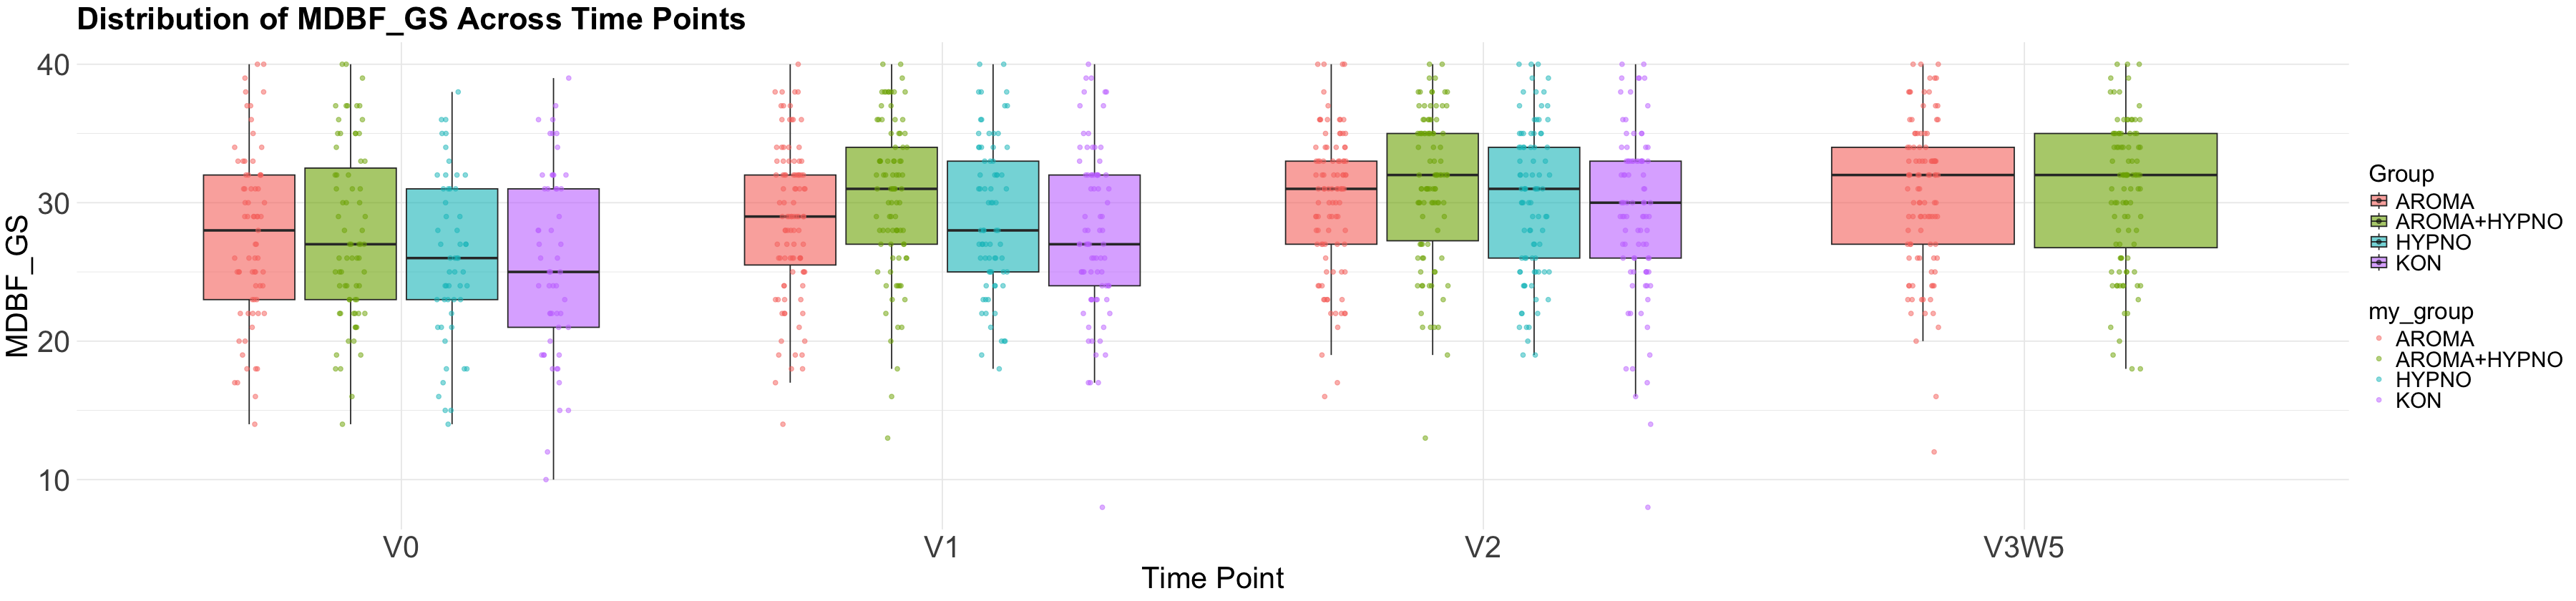

In [70]:
# Plotting one outcome variable at a time
plot_single_boxplot("MDBF_GS")

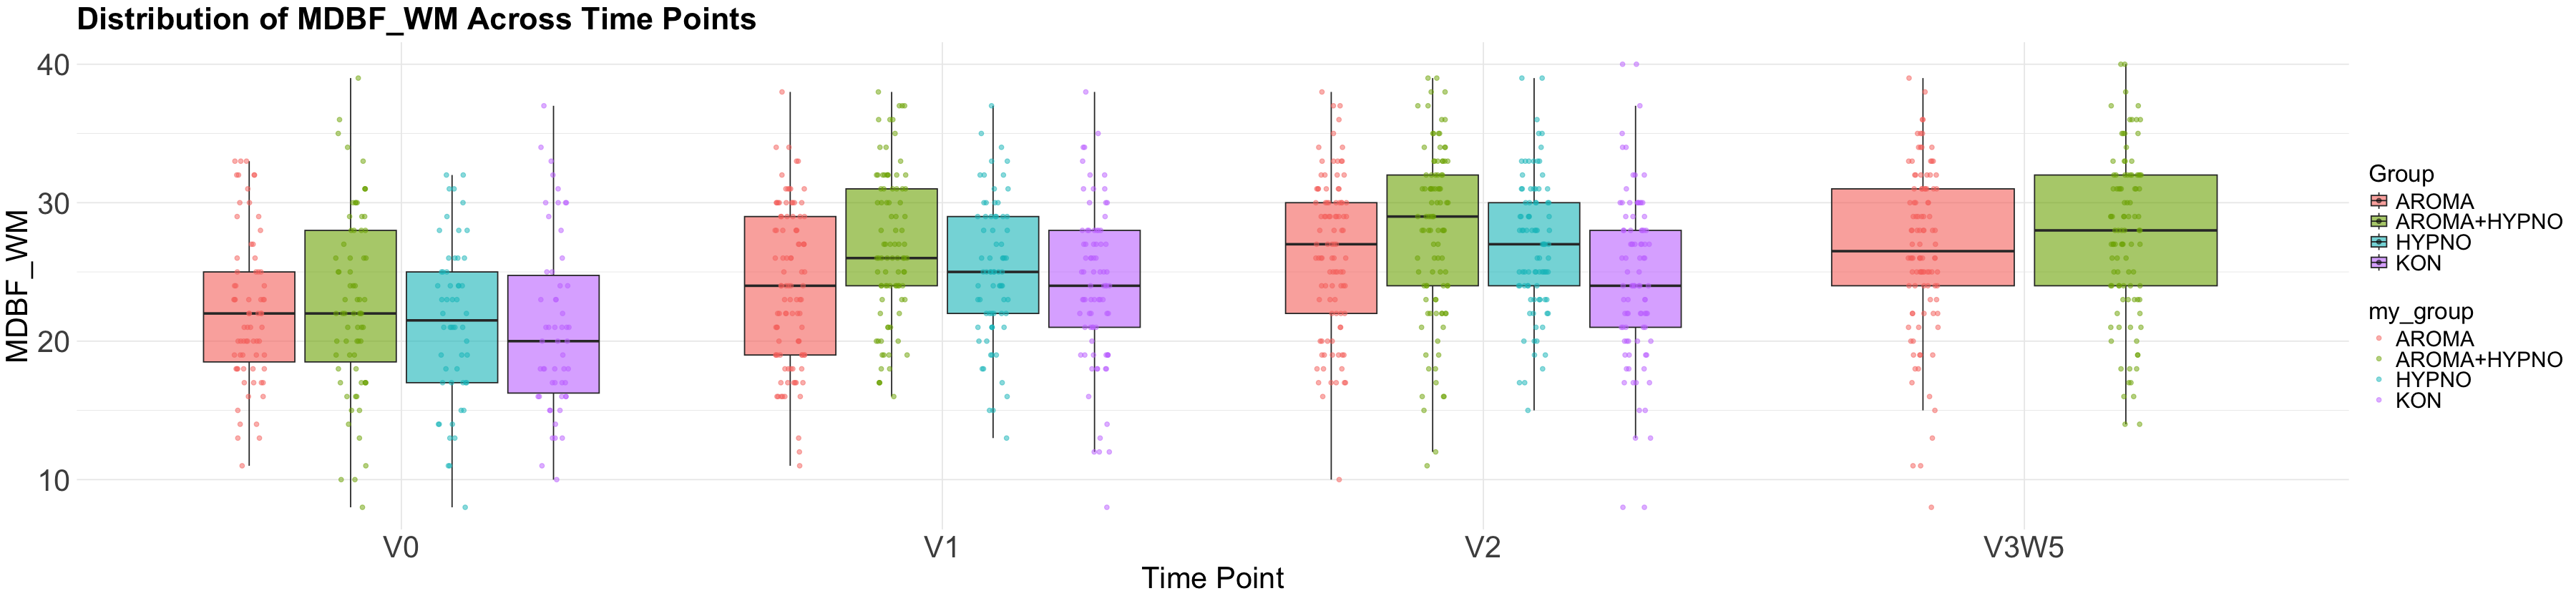

In [71]:
# Plotting one outcome variable at a time
plot_single_boxplot("MDBF_WM")

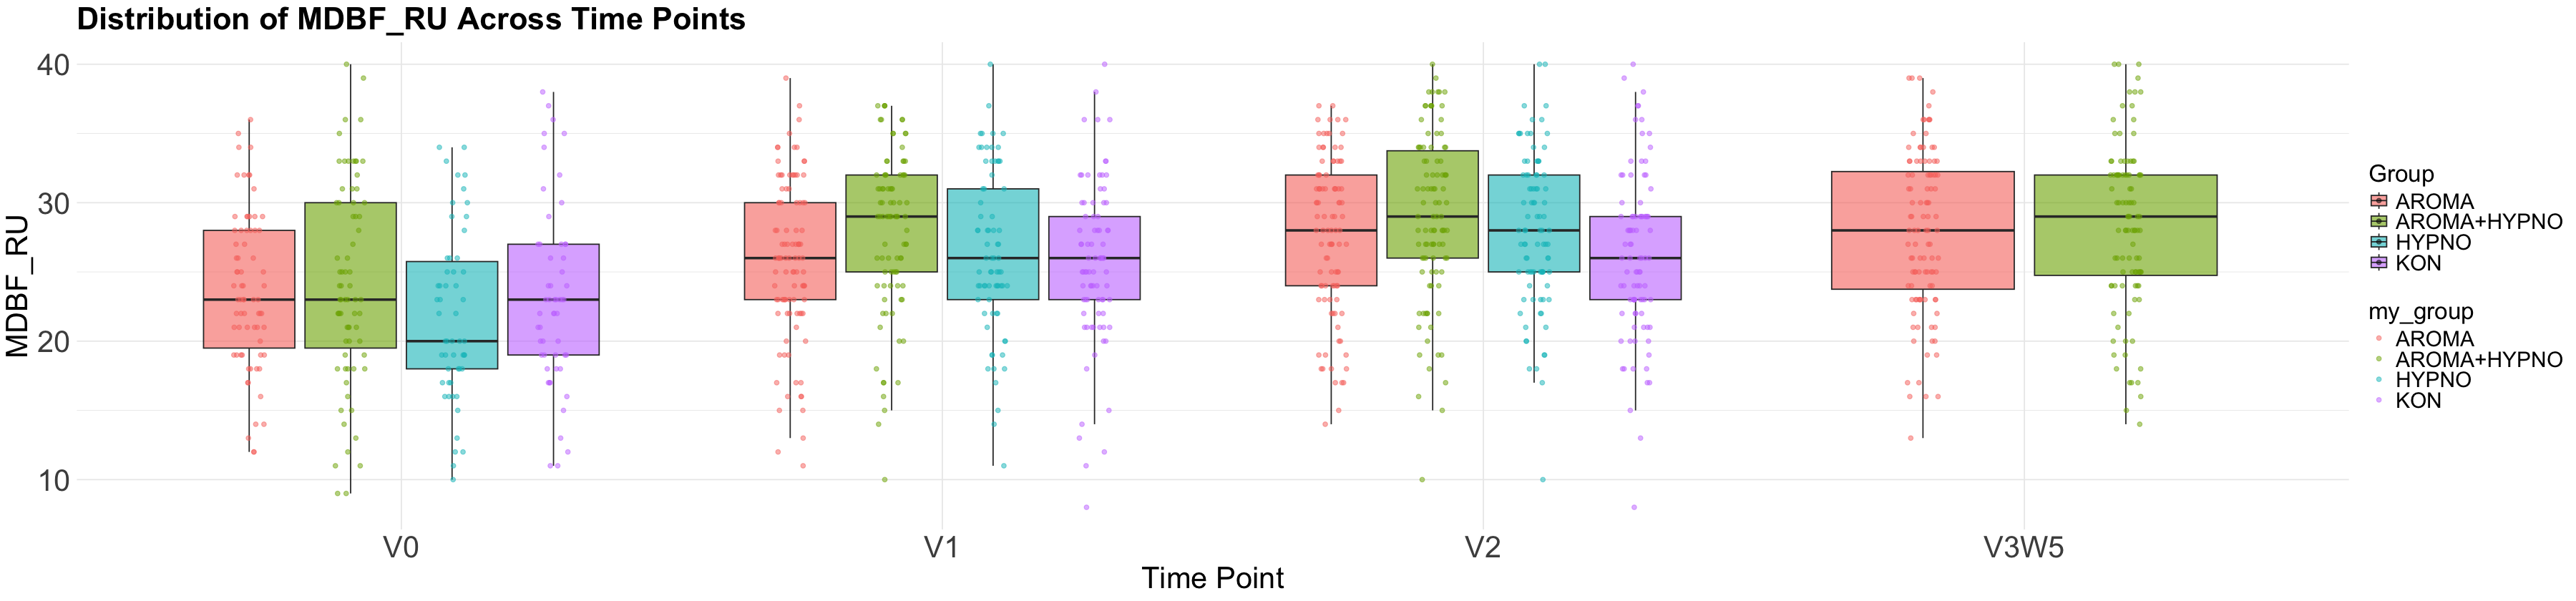

In [72]:
# Plotting one outcome variable at a time
plot_single_boxplot("MDBF_RU")

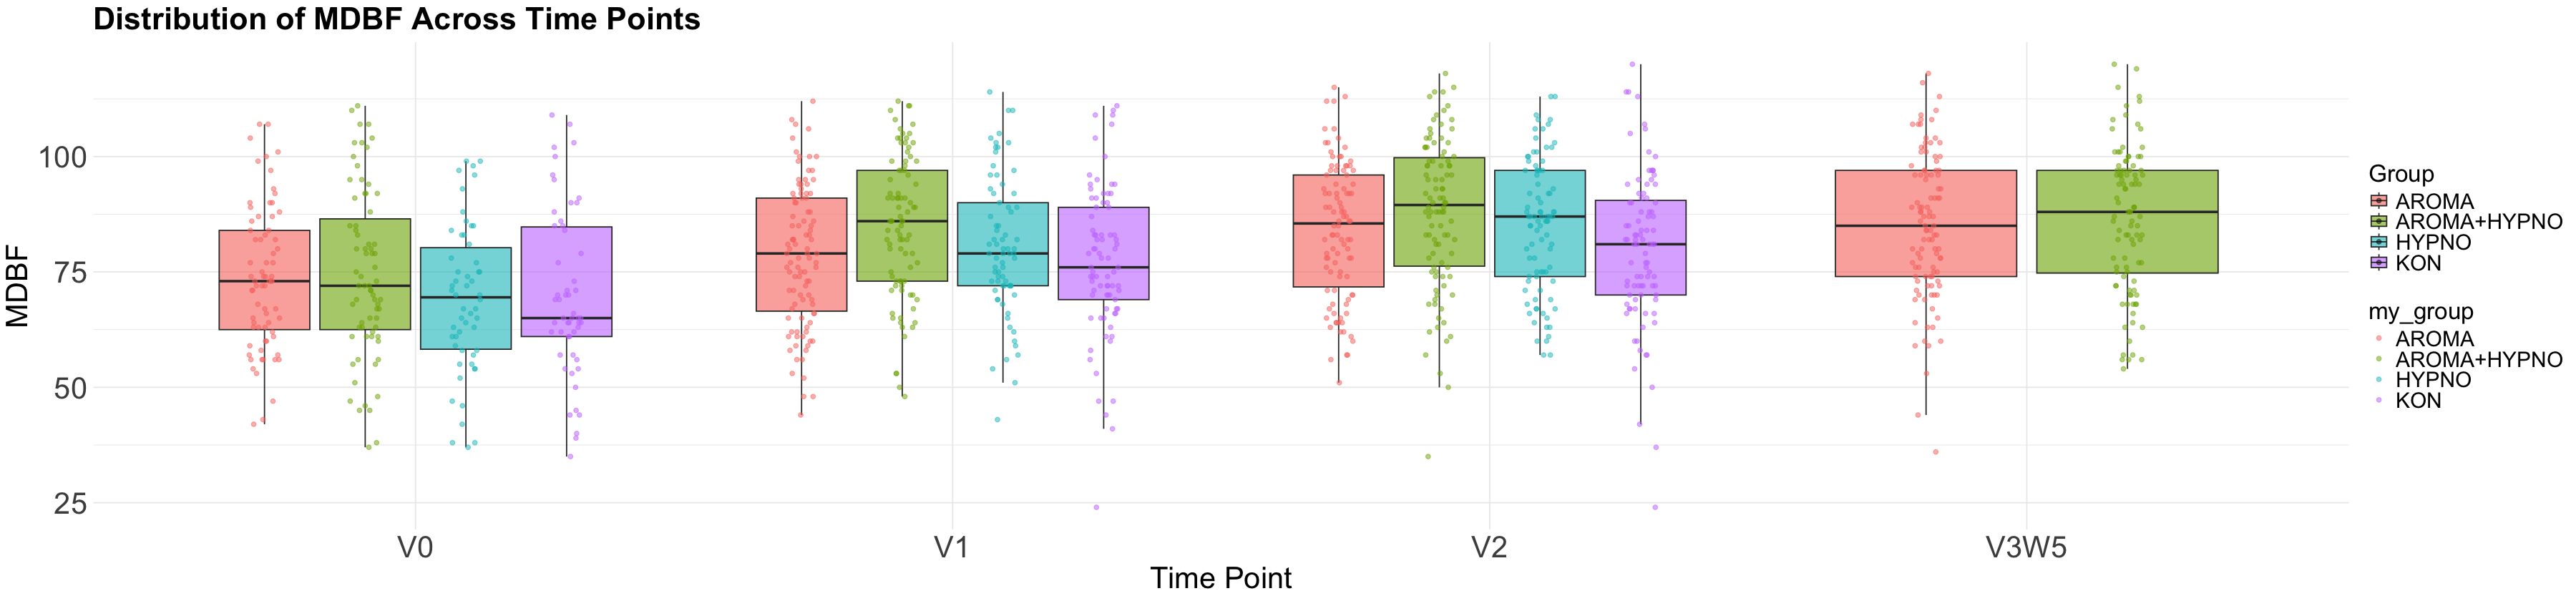

In [73]:
# Plotting one outcome variable at a time
plot_single_boxplot("MDBF")

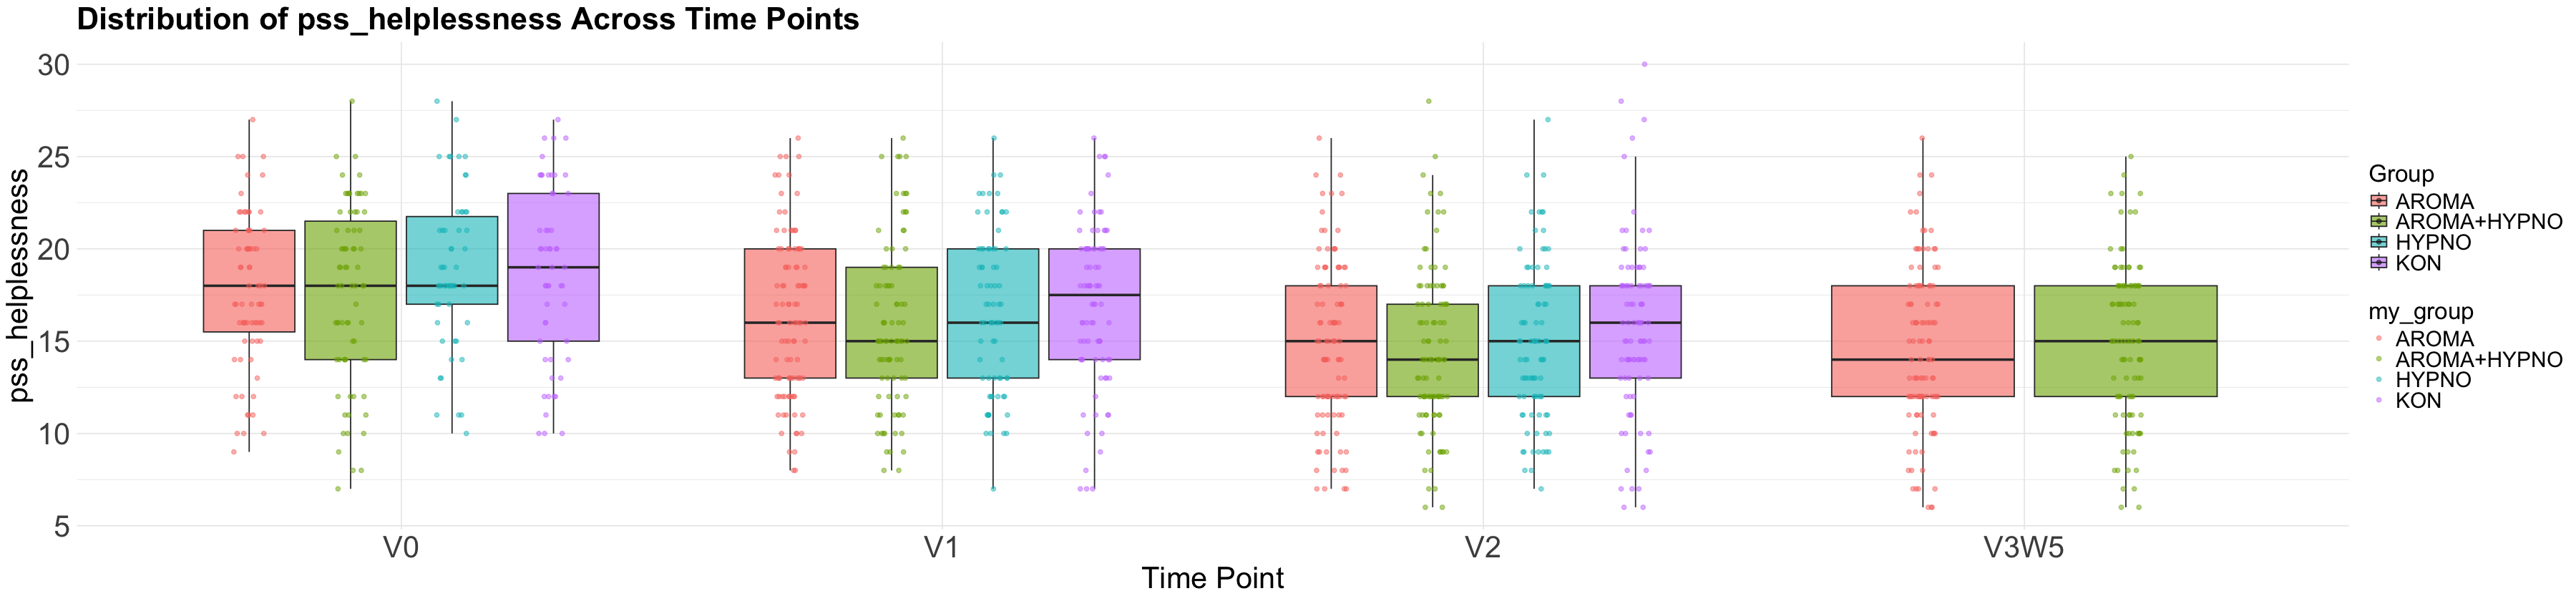

In [74]:
# Plotting one outcome variable at a time
plot_single_boxplot("pss_helplessness")

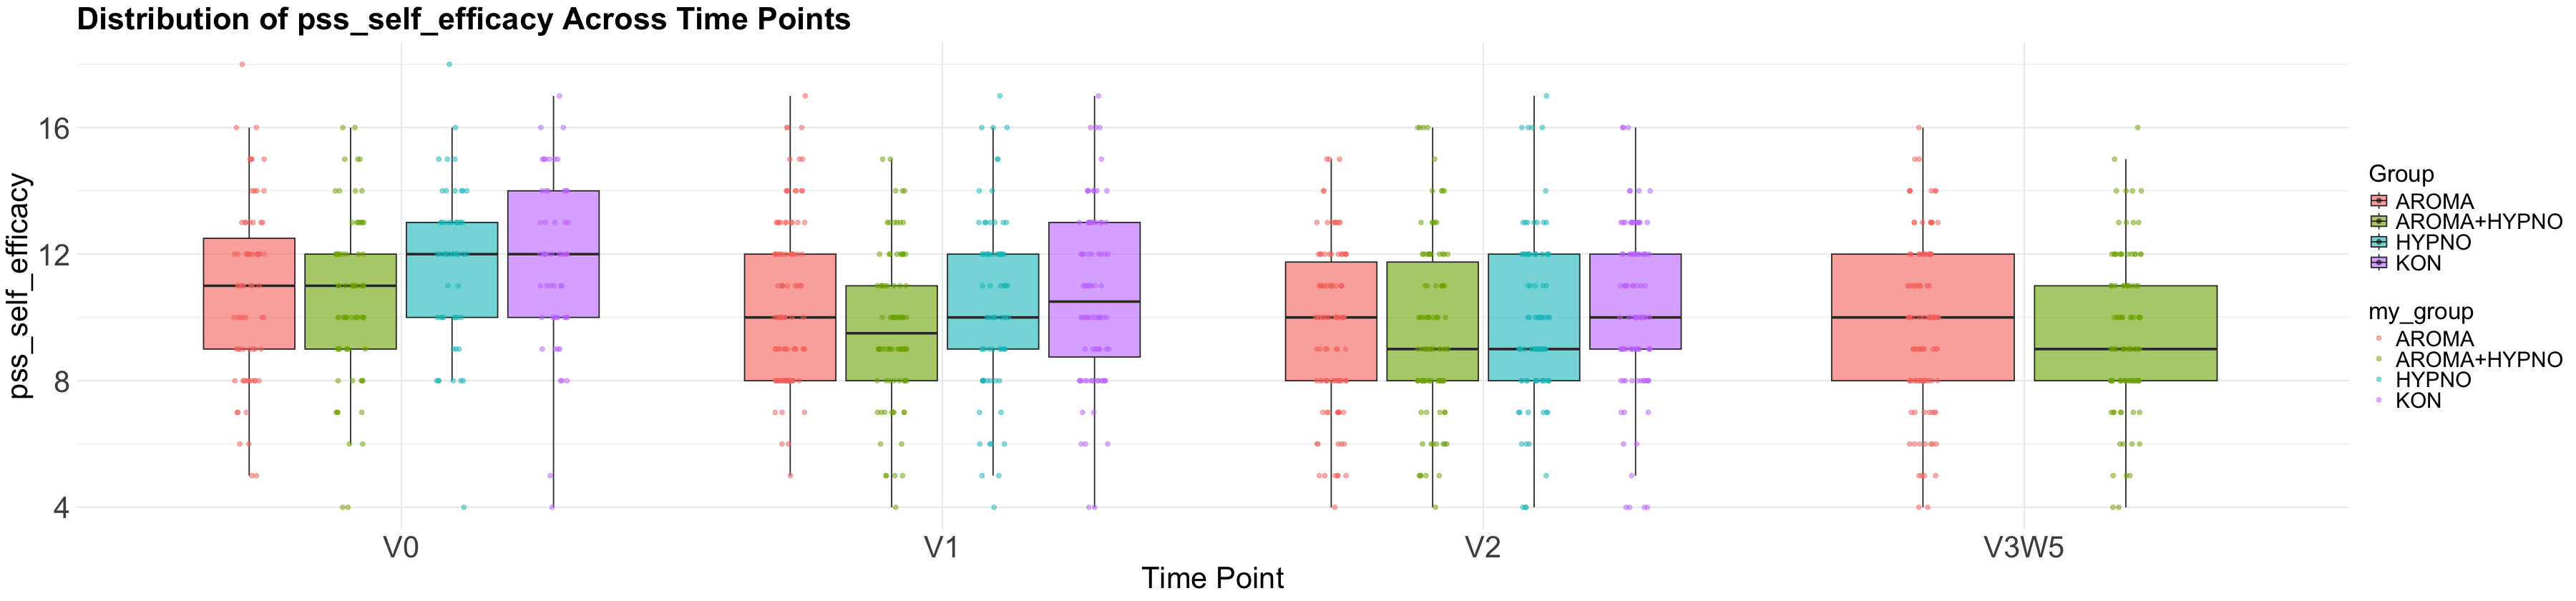

In [75]:
# Plotting one outcome variable at a time
plot_single_boxplot("pss_self_efficacy")

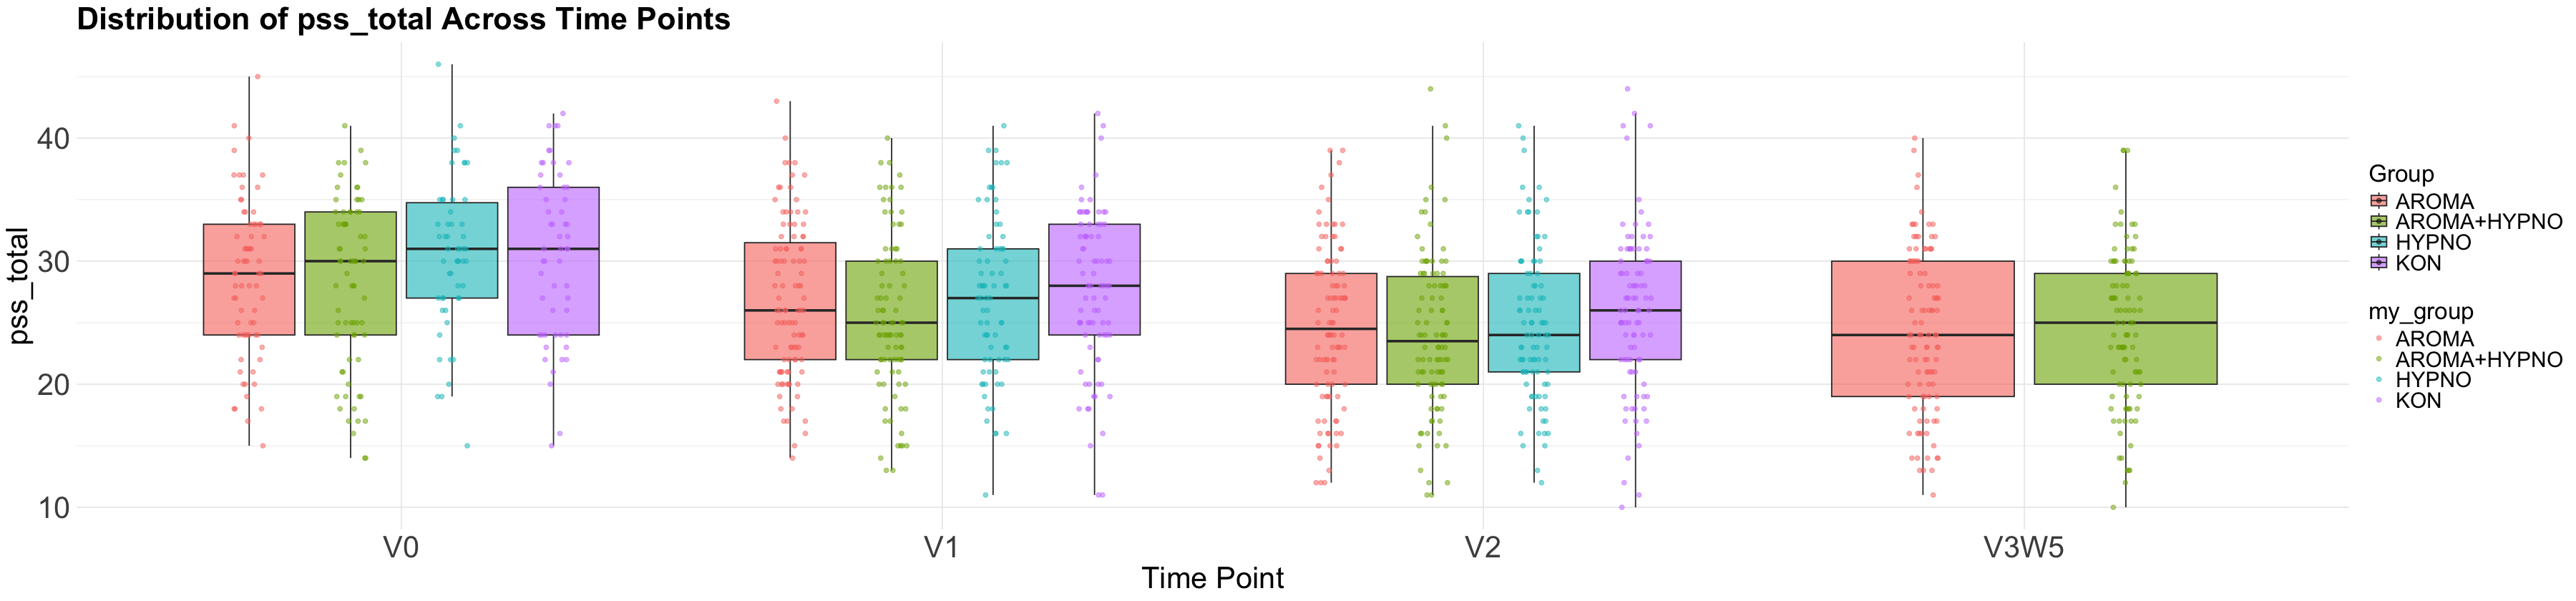

In [76]:
# Plotting one outcome variable at a time
plot_single_boxplot("pss_total")

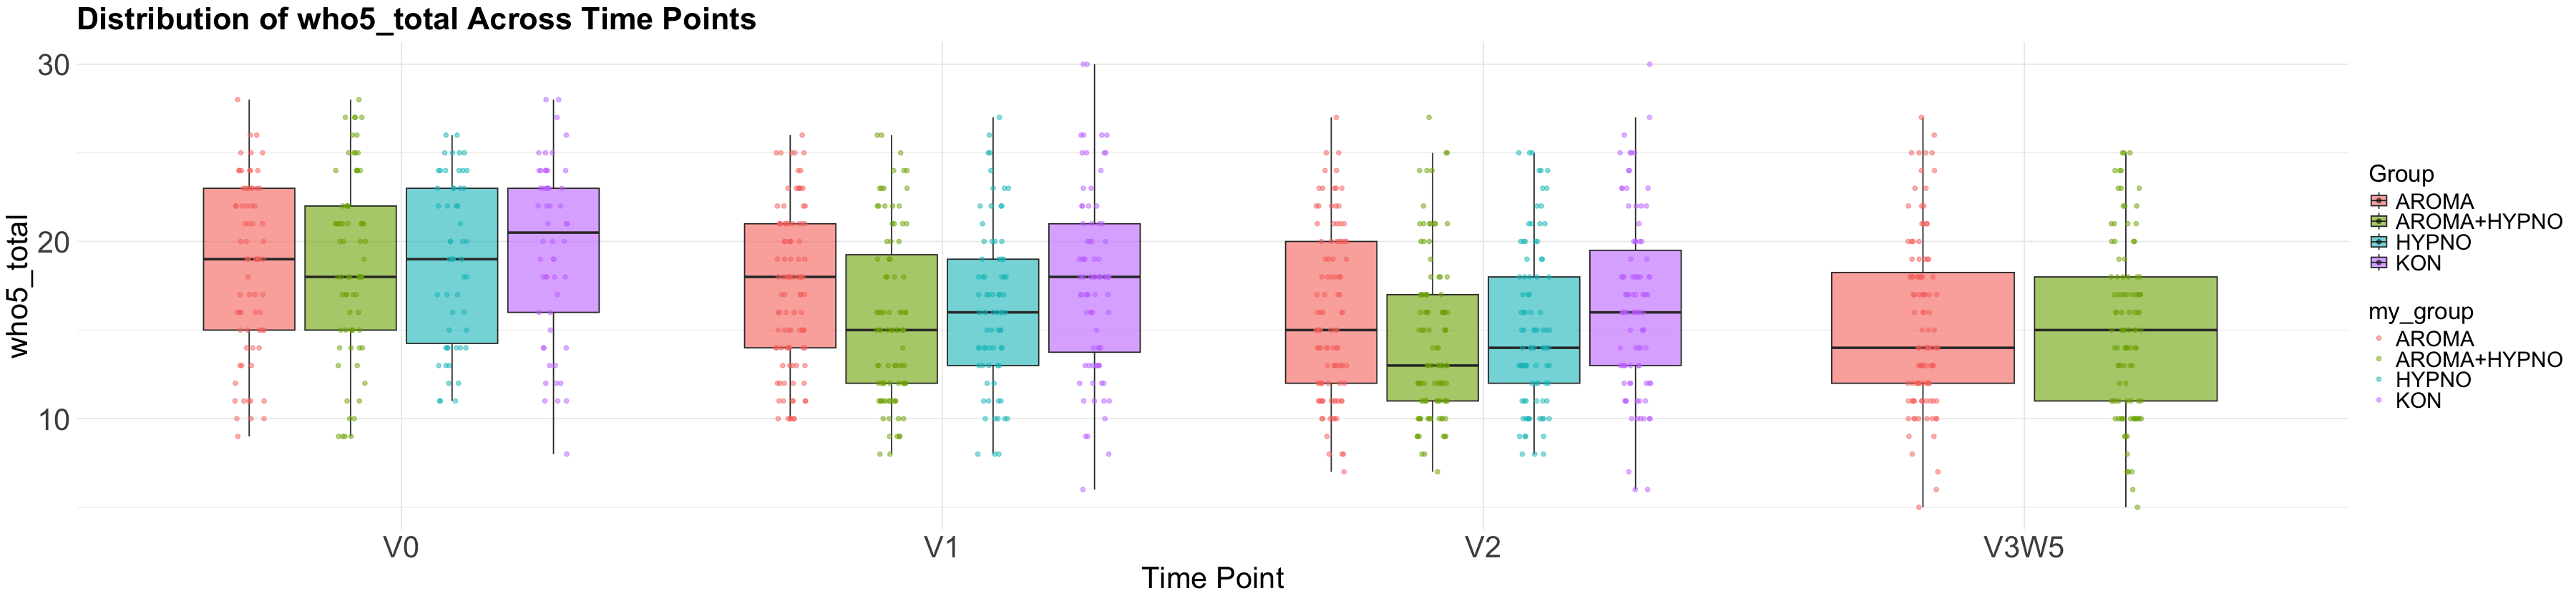

In [77]:
# Plotting one outcome variable at a time
plot_single_boxplot("who5_total")

## Attrition Analysis
[Back to Table of Content](#table-of-content)

Attrition analysis involves examining the dropout rate of participants in a study. It helps identify how many participants left the study at different time points and whether there are systematic differences between those who dropped out and those who stayed.

In [78]:
# ------------------------
# COUNT UNIQUE PARTICIPANTS AT EACH TIME POINT
# ------------------------

participant_counts <- mind %>%
    dplyr::group_by(Quest_Nr) %>%
    dplyr::summarise(n_participants = n_distinct(Serial_Nr)) %>%
    arrange(Quest_Nr) %>%
    filter(Quest_Nr %in% c("Sozio", "V0", "V1", "V2", "V3W5"))

print("Number of Participants Per Time Point:")
print(participant_counts)

[1] "Number of Participants Per Time Point:"
# A tibble: 5 x 2
  Quest_Nr n_participants
  <fct>             <int>
1 Sozio               518
2 V0                  485
3 V1                  392
4 V2                  383
5 V3W5                206


In [79]:
# ------------------------
# OVERALL ATTRITION RATE (UNTIL V2)
# ------------------------

# Step 1: Select relevant time points
relevant_counts <- participant_counts %>%
    filter(Quest_Nr %in% c("Sozio", "V0", "V1", "V2"))

# Step 2: Calculate attrition rate
attrition_rates <- relevant_counts %>%
    mutate(prev_n = lag(n_participants),  # Get the previous time point's count
           attrition_rate = ifelse(!is.na(prev_n) & prev_n > 0,
                                   (prev_n - n_participants) / prev_n * 100, 
                                   NA))  # Avoid division by zero

# Step 3: Print the results
print("Attrition Rates Until V2:")
print(attrition_rates)

[1] "Attrition Rates Until V2:"
# A tibble: 4 x 4
  Quest_Nr n_participants prev_n attrition_rate
  <fct>             <int>  <int>          <dbl>
1 Sozio               518     NA          NA   
2 V0                  485    518           6.37
3 V1                  392    485          19.2 
4 V2                  383    392           2.30


V0: 6.37% of participants dropped out from Sozio → V0. Dropout explanation: Some participants did not continue after Sozio, possibly due to loss of interest or technical issues.

V1: 19.2% of participants dropped out from V0 → V1. This is the largest dropout so far, suggesting that engagement significantly dropped at this stage.

V2: 2.30% of participants dropped out from V1 → V2. Dropout slowed down, meaning that most of those who remained at V1 continued to V2.

In [80]:
# Get participant numbers for V0 and V2
v0_n <- participant_counts %>% filter(Quest_Nr == "V0") %>% pull(n_participants)
v2_n <- participant_counts %>% filter(Quest_Nr == "V2") %>% pull(n_participants)

# Calculate overall attrition rate
overall_attrition <- (v0_n - v2_n) / v0_n * 100

# Print result
print(paste("Overall Attrition Rate from V0 to V2:", round(overall_attrition, 2), "%"))

[1] "Overall Attrition Rate from V0 to V2: 21.03 %"


## Compliance Analysis
[Back to Table of Content](#table-of-content)

Compliance analysis examines whether participants adhered to the study protocol or intervention. For example, in a clinical trial, compliance could refer to attending scheduled sessions, completing questionnaires, or following treatment instructions.

In [81]:
# ------------------------
# OVERALL COMPLIANCE CALCULATION UNTIL V2
# ------------------------

# Total number of participants at baseline (V0)
n_v0 <- participant_counts %>% filter(Quest_Nr == "V0") %>% pull(n_participants)

# Total responses across V0, V1, and V2
total_completed_assessments <- participant_counts %>%
    filter(Quest_Nr %in% c("V0", "V1", "V2")) %>%
    summarise(total_responses = sum(n_participants)) %>%
    pull(total_responses)

In [82]:
# Total expected assessments = V0 participants * 3 time points
total_expected_assessments <- n_v0 * 3

# Compute overall compliance rate
overall_compliance_rate <- (total_completed_assessments / total_expected_assessments) * 100

# Print overall compliance rate
print(paste("Overall Compliance Rate (Until V2):", round(overall_compliance_rate, 2), "%"))

[1] "Overall Compliance Rate (Until V2): 86.6 %"


The overall compliance rate indicates that 86.6% of all expected assessments (V0 to V2) were completed. This means that, on average, participants completed 86.6% of the total possible surveys they were expected to complete. This is a relatively high compliance rate, suggesting that most participants remained engaged in the study until V2.

In [83]:
# ------------------------
# PER-WAVE COMPLIANCE CALCULATION
# ------------------------

# Compute compliance per wave
per_wave_compliance <- participant_counts %>%
    filter(Quest_Nr %in% c("V0", "V1", "V2")) %>%
    mutate(expected_responses = n_v0,  # Expected responses = baseline sample size
           compliance_rate = (n_participants / expected_responses) * 100)  # Compliance per wave

# Print per-wave compliance
print("Compliance Rate Per Time Point:")
print(per_wave_compliance)

[1] "Compliance Rate Per Time Point:"
# A tibble: 3 x 4
  Quest_Nr n_participants expected_responses compliance_rate
  <fct>             <int>              <int>           <dbl>
1 V0                  485                485           100  
2 V1                  392                485            80.8
3 V2                  383                485            79.0


Drop between V0 → V1 (19.2%): This is the biggest decrease, indicating that many participants dropped out after the first follow-up.
Possible reasons: lack of motivation, time constraints, technical issues.

Drop between V1 → V2 (1.8%): Much smaller dropout, suggesting that once participants complete V1, they are more likely to stay engaged.
This could mean that the barrier to retention is highest between V0 and V1.

## Data Imputation
[Back to Table of Content](#table-of-content)

The attrition rate from V0 to V2 is 21.3% meaning that this amount of data points is missing.

Data preparation and separation

In [84]:
# Select only the required columns
selected_data <- mind %>%
    filter(Quest_Nr %in% c("V0", "V1", "V2", "V3W5")) %>%
    dplyr::select(Serial_Nr, Quest_Nr, MDBF_GS,
                  MDBF_WM, MDBF_RU, MDBF, pss_helplessness,
                  pss_self_efficacy, pss_total, who5_total)

# Print the structure of the new dataset
print("Selected Variables for Further Processing:")
str(selected_data)

[1] "Selected Variables for Further Processing:"
tibble [1,466 x 10] (S3: tbl_df/tbl/data.frame)
 $ Serial_Nr        : Factor w/ 519 levels "146RGH2GBD","1814V6TDDA",..: 367 411 309 376 419 329 503 458 293 446 ...
 $ Quest_Nr         : Factor w/ 23 levels "Int_0","Int_1",..: 20 20 20 20 20 20 20 20 20 20 ...
 $ MDBF_GS          : num [1:1466] 19 23 38 22 34 24 26 28 23 36 ...
 $ MDBF_WM          : num [1:1466] 15 20 35 15 31 20 13 23 26 31 ...
 $ MDBF_RU          : num [1:1466] 13 18 35 23 28 20 30 25 30 20 ...
 $ MDBF             : num [1:1466] 47 61 108 60 93 64 69 76 79 87 ...
 $ pss_helplessness : num [1:1466] 24 18 7 15 18 20 18 15 18 17 ...
 $ pss_self_efficacy: num [1:1466] 16 13 9 13 8 10 9 8 6 8 ...
 $ pss_total        : num [1:1466] 40 31 16 28 26 30 27 23 24 25 ...
 $ who5_total       : num [1:1466] 26 26 10 20 13 20 23 24 14 10 ...


In [85]:
# Transform data from long to wide format
wide_data <- selected_data %>%
    pivot_wider(
        names_from = Quest_Nr,  # Use Quest_Nr as column names
        values_from = c(MDBF_GS, MDBF_WM, MDBF_RU, MDBF, 
                        pss_helplessness, pss_self_efficacy, pss_total, who5_total),
        names_sep = "_"
    )

In [86]:
# Step 1: Select relevant variables from socio_data and rename with "_V0" suffix
socio_selected <- socio_data %>%
    dplyr::select(Serial_Nr, my_group, gender, age_group, educational_degree) %>%
    rename_with(~ paste0(., "_V0"), -Serial_Nr)  # Add "_V0" suffix to all except Serial_Nr


In [87]:
# Step 2: Merge with wide_data using Serial_Nr
mind2 <- wide_data %>%
    left_join(socio_selected, by = "Serial_Nr")

In [88]:
# Dataset for question (a): Remove variables ending with _V3W5
mind2_a <- mind2 %>%
  dplyr::select(-matches("_V3W5$"))

In [89]:
# Dataset for question (b): Filter only AROMA and AROMA+HYPNO groups
mind2_b <- mind2 %>%
  filter(my_group_V0 %in% c("AROMA", "AROMA+HYPNO"))

Missings?

In [90]:
# Function to calculate missing value percentages
calculate_missing <- function(df) {
  missing_percent <- colSums(is.na(df)) / nrow(df) * 100
  missing_df <- data.frame(Variable = names(missing_percent), Missing_Percent = missing_percent)
  missing_df <- missing_df %>% arrange(desc(Missing_Percent))
  return(missing_df)
}

In [91]:
# Calculate missing values for both datasets
missing_a <- calculate_missing(mind2_a)
missing_b <- calculate_missing(mind2_b)

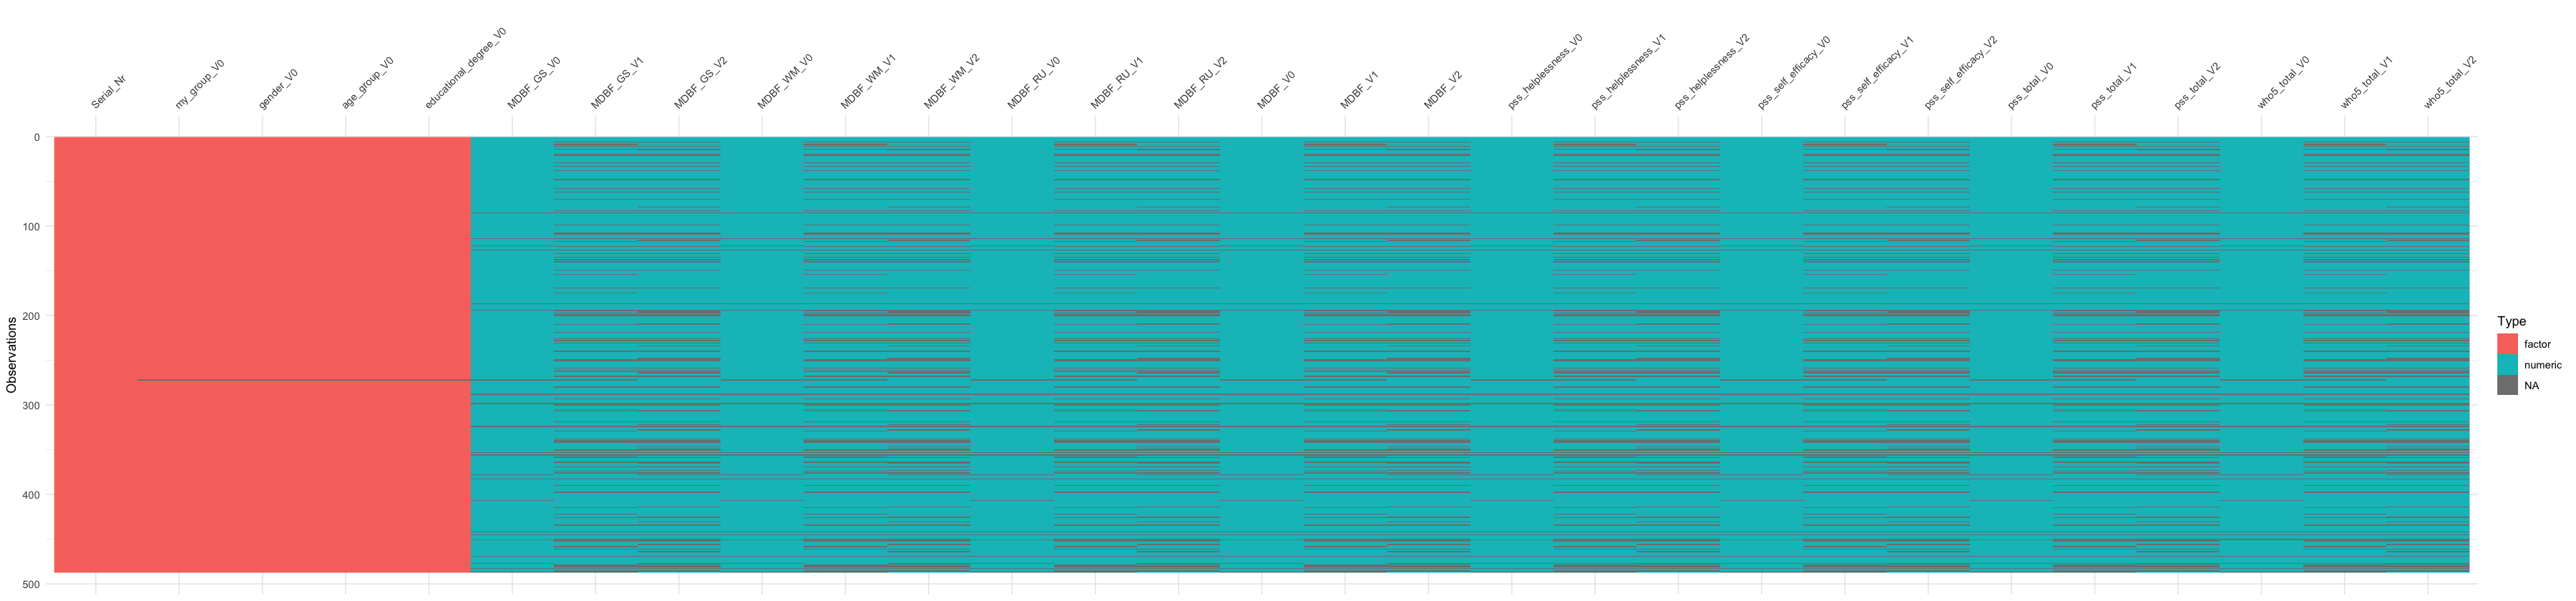

In [92]:
vis_dat(mind2_a)

In [93]:
missing_a

Variable,Missing_Percent
<chr>,<dbl>
MDBF_GS_V2,22.3819302
MDBF_WM_V2,22.3819302
MDBF_RU_V2,22.3819302
MDBF_V2,22.3819302
pss_helplessness_V2,22.3819302
pss_self_efficacy_V2,22.3819302
pss_total_V2,22.3819302
who5_total_V2,22.3819302
pss_helplessness_V1,21.1498973


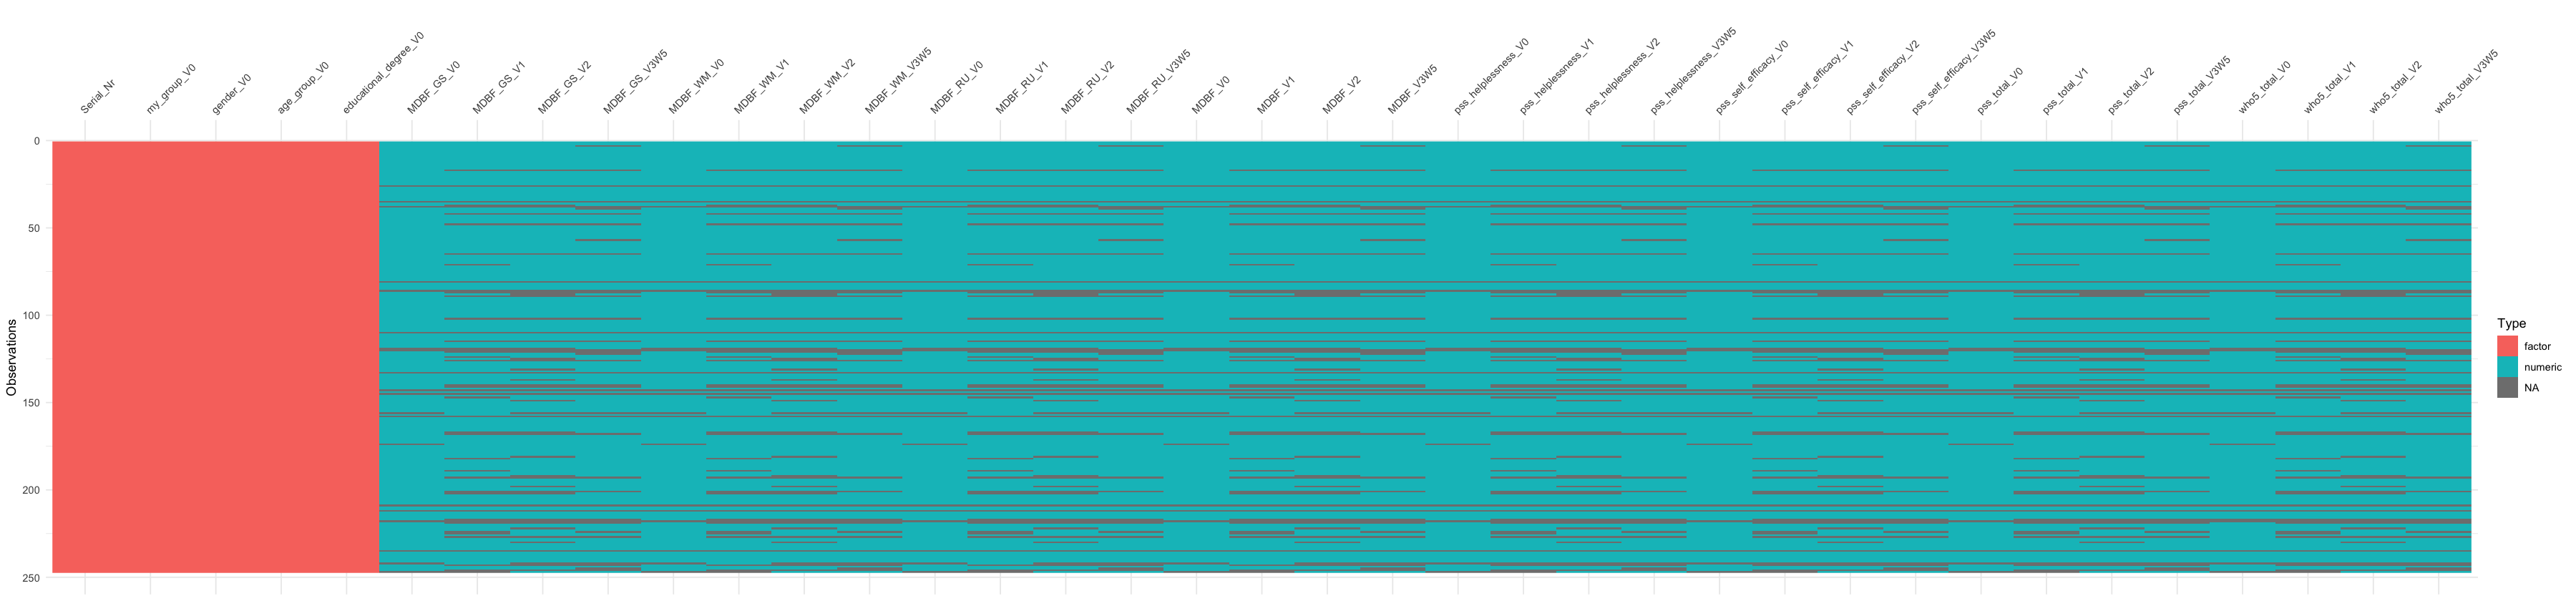

In [94]:
vis_dat(mind2_b)

In [95]:
missing_b

Variable,Missing_Percent
<chr>,<dbl>
MDBF_GS_V2,20.647773
MDBF_WM_V2,20.647773
MDBF_RU_V2,20.647773
MDBF_V2,20.647773
pss_helplessness_V2,20.647773
pss_self_efficacy_V2,20.647773
pss_total_V2,20.647773
who5_total_V2,20.647773
pss_helplessness_V1,19.433198


IMPUTATION

mind2_a data frame (Primary Hypothesis)

In [96]:
# Define methods for MICE
methods <- make.method(mind2_a)

In [97]:
# Exclude ID variables from imputation (they are not missing)
methods["Serial_Nr"] <- ""

# Assign "pmm" for numeric variables
methods["MDBF_GS_V0"] <- "midastouch"
methods["MDBF_GS_V1"] <- "midastouch"
methods["MDBF_GS_V2"] <- "midastouch"

methods["MDBF_WM_V0"] <- "midastouch"
methods["MDBF_WM_V1"] <- "midastouch"
methods["MDBF_WM_V2"] <- "midastouch"

methods["MDBF_RU_V0"] <- "midastouch"
methods["MDBF_RU_V1"] <- "midastouch"
methods["MDBF_RU_V2"] <- "midastouch"

methods["MDBF_V0"] <- "midastouch"
methods["MDBF_V1"] <- "midastouch"
methods["MDBF_V2"] <- "midastouch"

methods["pss_helplessness_V0"] <- "midastouch"
methods["pss_helplessness_V1"] <- "midastouch"
methods["pss_helplessness_V2"] <- "midastouch"

methods["pss_self_efficacy_V0"] <- "midastouch"
methods["pss_self_efficacy_V1"] <- "midastouch"
methods["pss_self_efficacy_V2"] <- "midastouch"

methods["pss_total_V0"] <- "midastouch"
methods["pss_total_V1"] <- "midastouch"
methods["pss_total_V2"] <- "midastouch"

methods["who5_total_V0"] <- "midastouch"
methods["who5_total_V1"] <- "midastouch"
methods["who5_total_V2"] <- "midastouch"

In [98]:
# Assign "rf" for categorical variables
methods["my_group_V0"] <- "cart"
methods["gender_V0"] <- "rf"
methods["age_group_V0"] <- "cart"
methods["educational_degree_V0"] <- "cart"

In [99]:
# Reduce computational load by limiting predictors
predictorMatrix <- make.predictorMatrix(mind2_a)
predictorMatrix[, c("Serial_Nr")] <- 0  # Exclude ID variables from imputation

In [ ]:
# Run Multiple Imputation with 50 datasets
imputed_data_mind2a <- mice(mind2_a, 
                     m = 50,  # Number of imputed datasets
                     maxit = 20, # Number of iterations
                     method = methods,
                     predictorMatrix = predictorMatrix,  # Use reduced predictor set
                     seed = 123,  # Reproducibility
                     printFlag = FALSE)  # Suppress output messages

In [ ]:
# Check convergence of imputation
plot(imputed_data_mind2a)

In [ ]:
# Check summary of imputation
summary(imputed_data_mind2a)


In [ ]:
# Save the first imputed dataset
saveRDS(imputed_data_mind2a, file = file.path(path, "data", "imputed_data_mind2a.rds"))

In [ ]:
# Check missing data after imputation
sum(is.na(complete(imputed_data_mind2a, 1)))  # Should be 0 if all missing data was imputed

mind2_b data frame (Secondary Hypothesis)

In [100]:
# Define methods for MICE
methods2 <- make.method(mind2_b)

In [101]:
# Exclude ID variables from imputation
methods2["Serial_Nr"] <- ""

In [102]:
# Assign "midastouch" for numeric variables (handles extreme missing values better)
numeric_vars <- c("MDBF_GS_V0", "MDBF_GS_V1", "MDBF_GS_V2", "MDBF_GS_V3W5",
                  "MDBF_WM_V0", "MDBF_WM_V1", "MDBF_WM_V2", "MDBF_WM_V3W5",
                  "MDBF_RU_V0", "MDBF_RU_V1", "MDBF_RU_V2", "MDBF_RU_V3W5",
                  "MDBF_V0", "MDBF_V1", "MDBF_V2", "MDBF_V3W5",
                  "pss_helplessness_V0", "pss_helplessness_V1", "pss_helplessness_V2", "pss_helplessness_V3W5",
                  "pss_self_efficacy_V0", "pss_self_efficacy_V1", "pss_self_efficacy_V2", "pss_self_efficacy_V3W5",
                  "pss_total_V0", "pss_total_V1", "pss_total_V2", "pss_total_V3W5",
                  "who5_total_V0", "who5_total_V1", "who5_total_V2", "who5_total_V3W5")

methods2[numeric_vars] <- "midastouch"

In [103]:
# Assign "cart" for categorical variables (faster than "rf")
methods["my_group_V0"] <- "cart"
methods["gender_V0"] <- "rf"
methods["age_group_V0"] <- "cart"
methods["educational_degree_V0"] <- "cart"

In [104]:
# Reduce computational load by limiting predictors
predictorMatrix <- make.predictorMatrix(mind2_b)
predictorMatrix[, c("Serial_Nr")] <- 0  # Exclude ID variable


In [ ]:
# Run Multiple Imputation with 50 datasets
imputed_data_mind2b <- mice(mind2_b, 
                            m = 50,  # Number of imputed datasets
                            maxit = 20, # Number of iterations
                            method = methods2,
                            predictorMatrix = predictorMatrix,  # Use reduced predictor set
                            seed = 123,  # Reproducibility
                            printFlag = FALSE)  # Suppress output messages


In [ ]:
# Check convergence of imputation
plot(imputed_data_mind2b)

In [ ]:
# Check summary of imputation
summary(imputed_data_mind2b)

In [ ]:
# Save the first imputed dataset
saveRDS(imputed_data_mind2b, file = file.path(path, "data", "imputed_data_mind2b.rds"))

In [ ]:
# Check missing data after imputation
sum(is.na(complete(imputed_data_mind2b, 1)))  # Should be 0 if all missing data was imputed

## Statistical Model
[Back to Table of Content](#table-of-content)

Primärhypothese: Entspannung gemessen mittels MDBF_RU. Veränderung (=Differenz der Summenscores von V2 und V0) mittels t-Test zwischen den Gruppen AROMA+HYPNO und HYPNO vs. KON.

Sekundärhypothese: MDBF_RU Entspannung. Veränderung (=Differenz der Summenscores von V3 und V2) mittels t-Test zwischen den Gruppen AROMA+HYPNO vs. AROMA.

Alle anderen Variablen: ANOVA mit Messwiederholung

In [157]:
# Load the imputed data from RDS
imputed_data_mind2a <- readRDS(file.path(path, "data", "imputed_data_mind2a.rds"))

In [158]:
is.mids(imputed_data_mind2a)


[1] TRUE

## Primary hypotheses AROMA+HYPNO vs KON

In [107]:
# Step 2: Convert the mids object to a long dataframe (keeping all imputations)
full_imp_data <- complete(imputed_data_mind2a, 'long', include = TRUE) %>%
  mutate(MDBF_RU_change = MDBF_RU_V2 - MDBF_RU_V0)  # Compute change score


In [108]:
# Step 3: Convert the modified dataframe back to a `mids` object
imputed_data_mind2a <- as.mids(full_imp_data)

In [109]:
# Step 1: Perform a t-test on each imputed dataset
num_imputations <- imputed_data_mind2a$m  # Number of imputations
t_test_results <- lapply(1:num_imputations, function(i) {
  
  # Extract the i-th imputed dataset
  df <- complete(imputed_data_mind2a, i)
  
  # Filter the dataset for the relevant groups
  df_subset <- df %>% filter(my_group_V0 %in% c("AROMA+HYPNO", "KON"))
  
  # Perform Welch's t-test
  t_test <- t.test(MDBF_RU_change ~ my_group_V0, data = df_subset)
  
  # Store relevant t-test results
  data.frame(
    imputation = i,
    t_statistic = t_test$statistic,
    p_value = t_test$p.value,
    mean_diff = mean(df_subset$MDBF_RU_change[df_subset$my_group_V0 == "AROMA+HYPNO"]) - 
                mean(df_subset$MDBF_RU_change[df_subset$my_group_V0 == "KON"]),
    conf_low = t_test$conf.int[1],  
    conf_high = t_test$conf.int[2]
  )
})


In [110]:
# Step 2: Convert list of results into a dataframe
t_test_results_df <- bind_rows(t_test_results)

In [111]:
# Step 3: Pool results using Rubin's Rules
M <- nrow(t_test_results_df)  # Number of imputations

In [112]:
# Pooled mean difference
mean_diff_pooled <- mean(t_test_results_df$mean_diff)

In [113]:
# Within-imputation variance (average standard error squared)
var_within <- mean((t_test_results_df$conf_high - t_test_results_df$conf_low)^2) / (4 * qt(0.975, df = mean(M))^2)


In [114]:
# Between-imputation variance
var_between <- var(t_test_results_df$mean_diff)

In [115]:
# Total variance (Rubin’s rule)
var_total <- var_within + (1 + (1/M)) * var_between

In [116]:
# Compute pooled t-statistic
t_stat_pooled <- mean_diff_pooled / sqrt(var_total)

In [117]:
# Compute degrees of freedom using Barnard-Rubin method
df_pooled <- (M - 1) * (1 + (var_within / ((1 + (1/M)) * var_between)))^2


In [118]:
# Compute pooled p-value
p_value_pooled <- 2 * pt(-abs(t_stat_pooled), df = df_pooled)


In [119]:
# Compute 95% confidence interval
conf_low <- mean_diff_pooled - qt(0.975, df_pooled) * sqrt(var_total)
conf_high <- mean_diff_pooled + qt(0.975, df_pooled) * sqrt(var_total)


In [120]:
# Step 4: Store final pooled results
pooled_results_df <- data.frame(
  mean_diff_pooled = mean_diff_pooled,
  t_stat_pooled = t_stat_pooled,
  df_pooled = df_pooled,
  p_value_pooled = p_value_pooled,
  conf_low = conf_low,
  conf_high = conf_high
)

In [121]:
# Print the final pooled results
print(pooled_results_df)

  mean_diff_pooled t_stat_pooled df_pooled p_value_pooled   conf_low conf_high
1         1.430599      1.508357  1552.211      0.1316666 -0.4297763  3.290975


#### **Interpretation of the Results**

The analysis compared the change in **MDBF Ruhe (MDBF_RU_change)** between two groups:  
1. **AROMA+HYPNO**  
2. **KON**  

#### **Mean Difference**
- The **pooled mean difference** between the groups is **1.43**.
- This indicates that the **AROMA+HYPNO group experienced a greater increase in calmness (MDBF Ruhe scores) over time compared to the KON group**, but this difference **did not reach statistical significance**.

#### **t-Statistic and p-Value**
- The **pooled t-statistic** is **1.51**, with **df = 1552.21**.  
- The corresponding **p-value is 0.132**, which **exceeds the standard threshold (0.05)** for statistical significance.

#### **Confidence Interval**
- The **95% confidence interval** for the difference in means is **[-0.43, 3.29]**.
- Since this confidence interval **includes zero**, we cannot confidently conclude that there is a meaningful difference between the AROMA+HYPNO and KON groups.

---

#### **Effect Size (Cohen’s d)**
- The **pooled Cohen’s d was not computed, but given the lack of significance, it would likely indicate a small effect size.**
- Even if the effect were real, the **practical impact appears to be small or uncertain**.

---

#### **Conclusion: No Statistically Significant Effect**
**Since the p-value (0.132) is greater than 0.05, the difference between the groups is not statistically significant.**  
**The confidence interval includes zero, meaning we cannot be confident that the AROMA+HYPNO intervention led to a greater increase in calmness compared to KON.**  
**The effect size is likely small, suggesting that the practical impact of the AROMA+HYPNO intervention, if any, is limited.**  

#### **Implications**
- **Both the AROMA+HYPNO and KON groups became calmer over time (increase in MDBF Ruhe scores).**
- **However, the increase in calmness in the AROMA+HYPNO group was not statistically different from that in the KON group.**
- This suggests that **the AROMA+HYPNO intervention may not have provided additional benefits over KON** in improving calmness.
- Future research should explore **whether specific subgroups (e.g., based on gender, age, or baseline stress levels) might respond differently to the AROMA+HYPNO intervention**.

---

#### **Final Answer**
**The AROMA+HYPNO intervention did not show a statistically significant improvement in calmness compared to KON (p = 0.132).**  
**The confidence interval includes zero, suggesting that the effect is uncertain.**  

In [185]:
# Step 1: Define the number of imputations
num_imputations <- imputed_data_mind2a$m  

In [186]:
library(mitml)

In [187]:
# Step 2: Run the mixed-effects ANCOVA on each imputed dataset
mixed_models <- lapply(1:num_imputations, function(i) {
  
  # Extract the i-th imputed dataset
  df <- complete(imputed_data_mind2a, i)
  
  # Filter for relevant groups ("AROMA+HYPNO" and "KON")
  df <- df %>% filter(my_group_V0 %in% c("AROMA+HYPNO", "KON"))

  # Convert `my_group_V0` to a factor
  df$my_group_V0 <- as.factor(df$my_group_V0)

  # Convert to long format, keeping MDBF_RU_V0 as a covariate
  df_long <- df %>%
    pivot_longer(cols = c(MDBF_RU_V1, MDBF_RU_V2), 
                 names_to = "Time", values_to = "MDBF_RU_Score") %>%
    mutate(Time = factor(Time, levels = c("MDBF_RU_V1", "MDBF_RU_V2")))  # Convert Time to factor

  # Ensure Serial_Nr is a factor
  df_long$Serial_Nr <- as.factor(df_long$Serial_Nr)

  # Fit the mixed-effects ANCOVA model
  model <- lmer(MDBF_RU_Score ~ my_group_V0 + MDBF_RU_V0 + Time + (1 | Serial_Nr), 
                data = df_long)
  
  return(model)
})

In [189]:
# Step 3: Pool the results using Rubin’s Rules (updated)
pooled_results <- testEstimates(mixed_models, extra.pars = TRUE)

# Step 4: Print pooled results
summary(pooled_results)


Call:

testEstimates(model = mixed_models, extra.pars = TRUE)

Final parameter estimates and inferences obtained from 50 imputed data sets.

                Estimate Std.Error   t.value        df   P(>|t|)       RIV       FMI 
(Intercept)       16.849     1.291    13.053   967.106     0.000     0.290     0.227 
my_group_V0KON    -1.878     0.613    -3.062  2272.415     0.002     0.172     0.148 
MDBF_RU_V0         0.445     0.050     8.866   808.700     0.000     0.327     0.248 
TimeMDBF_RU_V2     1.002     0.411     2.436   736.810     0.015     0.347     0.260 

                               Estimate 
Intercept~~Intercept|Serial_Nr   12.003 
Residual~~Residual               15.603 
ICC|Serial_Nr                     0.437 

Unadjusted hypothesis test as appropriate in larger samples.



#### **Fixed Effects**
| Predictor           | Estimate | Std. Error | t-value | df       | P(>|t|) | RIV   | FMI   |
|---------------------|----------|------------|---------|----------|--------|-------|-------|
| **Intercept**       | 16.849   | 1.291      | 13.053  | 967.106  | 0.000  | 0.290 | 0.227 |
| **my_group_V0KON**  | -1.878   | 0.613      | -3.062  | 2272.415 | 0.002  | 0.172 | 0.148 |
| **MDBF_RU_V0**      | 0.445    | 0.050      | 8.866   | 808.700  | 0.000  | 0.327 | 0.248 |
| **TimeMDBF_RU_V2**  | 1.002    | 0.411      | 2.436   | 736.810  | 0.015  | 0.347 | 0.260 |

---

#### **Variance Components & ICC**
| Parameter                          | Estimate | Interpretation |
|-------------------------------------|----------|---------------------------------------------------|
| **Intercept~~Intercept Serial_Nr**  | 12.003   | Variance between individuals in baseline scores. |
| **Residual~~Residual**              | 15.603   | **Unexplained variance** (residual noise in the model). |
| **ICC (Intraclass Correlation)**    | 0.437    | **43.7% of variance is due to individual differences (`Serial_Nr`)**. |

---

In [191]:
# Load required packages
library(miceadds)

* miceadds 3.16-18 (2023-01-06 10:54:00)


Attaching package: 'miceadds'


The following object is masked from 'package:naniar':

    prop_miss




In [192]:
# Extract values from pooled results
estimate <- -1.878  # Group effect
residual_variance <- 15.603  # Residual variance
pooled_sd <- sqrt(residual_variance)  # Pooled standard deviation

# Compute Cohen's d
cohens_d <- estimate / pooled_sd

# Compute partial eta squared
effect_variance <- estimate^2  # Effect variance
eta_squared <- effect_variance / (effect_variance + residual_variance)

# Print results
cat("Cohen's d:", cohens_d, "\n")
cat("Partial η²:", eta_squared, "\n")

Cohen's d: -0.4754354 
Partial <U+03B7><U+00B2>: 0.1843652 


The KON group scores 0.475 SD lower on MDBF_RU_V2 than the AROMA+HYPNO group, after controlling for baseline (MDBF_RU_V0). The group effect is moderate (0.475).

18.4% of the variance in MDBF_RU_V2 is explained by group differences (my_group_V0), after accounting for baseline scores.

## Primary hypotheses HYPNO vs KON

In [274]:
# Step 1: Extract imputed datasets as a list
num_imputations <- imputed_data_mind2a$m  # Number of imputations
t_test_results <- lapply(1:num_imputations, function(i) {
  
  # Extract the i-th imputed dataset
  df <- complete(imputed_data_mind2a, i)
  
  # Filter the dataset for HYPNO and KON groups
  df_subset <- df %>% filter(my_group_V0 %in% c("HYPNO", "KON"))
  
  # Perform Welch's t-test
  t_test <- t.test(MDBF_RU_change ~ my_group_V0, data = df_subset)
  
  # Store relevant t-test results
  data.frame(
    imputation = i,
    t_statistic = t_test$statistic,
    p_value = t_test$p.value,
    mean_diff = mean(df_subset$MDBF_RU_change[df_subset$my_group_V0 == "HYPNO"]) - 
                mean(df_subset$MDBF_RU_change[df_subset$my_group_V0 == "KON"]),
    conf_low = t_test$conf.int[1],  
    conf_high = t_test$conf.int[2]
  )
})

In [275]:
# Step 2: Convert list of results into a dataframe
t_test_results_df <- bind_rows(t_test_results)


In [276]:
# Step 3: Pool results using Rubin's Rules
M <- nrow(t_test_results_df)  # Number of imputations

In [277]:
# Pooled mean difference
mean_diff_pooled <- mean(t_test_results_df$mean_diff)


In [278]:
# Within-imputation variance (average standard error squared)
var_within <- mean((t_test_results_df$conf_high - t_test_results_df$conf_low)^2) / (4 * qt(0.975, df = mean(M))^2)

In [279]:
# Between-imputation variance
var_between <- var(t_test_results_df$mean_diff)

In [280]:
# Total variance (Rubin’s rule)
var_total <- var_within + (1 + (1/M)) * var_between

In [281]:
# Compute pooled t-statistic
t_stat_pooled <- mean_diff_pooled / sqrt(var_total)

In [282]:
# Compute degrees of freedom using Barnard-Rubin method
df_pooled <- (M - 1) * (1 + (var_within / ((1 + (1/M)) * var_between)))^2

In [283]:
# Compute pooled p-value
p_value_pooled <- 2 * pt(-abs(t_stat_pooled), df = df_pooled)

In [284]:
# Compute 95% confidence interval
conf_low <- mean_diff_pooled - qt(0.975, df_pooled) * sqrt(var_total)
conf_high <- mean_diff_pooled + qt(0.975, df_pooled) * sqrt(var_total)

In [285]:
# Step 4: Store final pooled results
pooled_results_df <- data.frame(
  mean_diff_pooled = mean_diff_pooled,
  t_stat_pooled = t_stat_pooled,
  df_pooled = df_pooled,
  p_value_pooled = p_value_pooled,
  conf_low = conf_low,
  conf_high = conf_high
)


In [286]:
# Print the final pooled results
print(pooled_results_df)


  mean_diff_pooled t_stat_pooled df_pooled p_value_pooled conf_low conf_high
1         2.032605      2.198862  1869.588     0.02800985 0.219661  3.845549


In [287]:
# Step 1: Extract number of imputations
num_imputations <- imputed_data_mind2a$m  

In [288]:
# Step 2: Compute Cohen’s d for each imputed dataset
effect_size_results <- lapply(1:num_imputations, function(i) {
  
  # Extract the i-th imputed dataset
  df <- complete(imputed_data_mind2a, i)
  
  # Filter for HYPNO and KON groups
  df_subset <- df %>% filter(my_group_V0 %in% c("HYPNO", "KON"))
  
  # Compute means and standard deviations
  mean_hypno <- mean(df_subset$MDBF_RU_change[df_subset$my_group_V0 == "HYPNO"], na.rm = TRUE)
  mean_kon <- mean(df_subset$MDBF_RU_change[df_subset$my_group_V0 == "KON"], na.rm = TRUE)
  sd_hypno <- sd(df_subset$MDBF_RU_change[df_subset$my_group_V0 == "HYPNO"], na.rm = TRUE)
  sd_kon <- sd(df_subset$MDBF_RU_change[df_subset$my_group_V0 == "KON"], na.rm = TRUE)
  n_hypno <- sum(df_subset$my_group_V0 == "HYPNO", na.rm = TRUE)
  n_kon <- sum(df_subset$my_group_V0 == "KON", na.rm = TRUE)
  
  # Compute pooled standard deviation
  sd_pooled <- sqrt(((n_hypno - 1) * sd_hypno^2 + (n_kon - 1) * sd_kon^2) / 
                     (n_hypno + n_kon - 2))
  
  # Compute Cohen’s d
  cohen_d <- (mean_hypno - mean_kon) / sd_pooled
  
  # Store results
  data.frame(
    imputation = i,
    cohen_d = cohen_d
  )
})

In [289]:
# Step 3: Combine results into a dataframe
effect_size_df <- bind_rows(effect_size_results)

In [290]:
# Step 4: Pool Cohen’s d across imputations
pooled_cohen_d <- mean(effect_size_df$cohen_d)

In [292]:
# Step 5: Output the pooled Cohen’s d
print(paste("Pooled Cohen's d:", round(pooled_cohen_d, 3)))

[1] "Pooled Cohen's d: 0.307"


#### **Interpretation of the Results**

The analysis compared the change in **MDBF Ruhe (MDBF_RU_change)** between two groups:  
1. **HYPNO**  
2. **KON**  

#### **Mean Difference**
- The **pooled mean difference** between the groups is **2.03**.
- This indicates that the **HYPNO group experienced a significantly greater increase in calmness (MDBF Ruhe scores) over time compared to the KON group**.

#### **t-Statistic and p-Value**
- The **pooled t-statistic** is **2.20**, with **df = 1869.59**.  
- The corresponding **p-value is 0.028**, which **is below the standard threshold (0.05)** for statistical significance.

#### **Confidence Interval**
- The **95% confidence interval** for the difference in means is **[0.22, 3.85]**.
- Since this confidence interval **does not include zero**, it confirms that the difference between HYPNO and KON is **statistically significant**.

---

#### **Effect Size (Cohen’s d)**
- The **pooled Cohen’s d is 0.307**, indicating a **small-to-moderate effect size**.
- According to conventional thresholds:
  - **0.2 → Small effect**
  - **0.5 → Medium effect**
  - **0.8 → Large effect**
- This suggests that, while the difference is **statistically significant**, the **practical effect size is relatively small**.

---

#### **Conclusion: Significant but Small-to-Moderate Effect**
**Since the p-value (0.028) is less than 0.05, the difference between the groups is statistically significant.**  
**The confidence interval does not include zero, meaning we can be confident that the HYPNO intervention led to a greater increase in calmness compared to KON.**  
**The effect size (Cohen's d = 0.307) suggests that the difference, while real, is small-to-moderate in magnitude.**  

#### **Implications**
- **Both the HYPNO and KON groups became calmer over time (increase in MDBF Ruhe scores).**
- **However, the HYPNO group showed a significantly larger increase in calmness compared to the KON group.**
- The **practical relevance of this effect is limited**, as the effect size is **not large**.
- Future research should investigate **why HYPNO led to a greater increase in calmness**, potentially examining psychological mechanisms such as relaxation effects, cognitive engagement, or physiological responses.

---

#### **Final Answer**
**The HYPNO intervention was significantly more effective than KON in increasing calmness, but the effect size is small to moderate (Cohen's d = 0.307).**  
**While statistically significant, the practical impact of the intervention might be limited.** 

## Secondary hypotheses AROMA+HYPNO vs AROMA

In [194]:
# Load the imputed data from RDS
imputed_data_mind2b <- readRDS(file.path(path, "data", "imputed_data_mind2b.rds"))

In [195]:
is.mids(imputed_data_mind2b)

[1] TRUE

In [309]:
# Step 1: Convert the mids object to long format to modify the data
full_imp_data_b <- complete(imputed_data_mind2b, 'long', include = TRUE) %>%
  mutate(MDBF_RU_Change_2to3W5 = MDBF_RU_V3W5 - MDBF_RU_V2)


In [310]:
# Step 2: Convert back to a mids object
imputed_data_mind2b <- as.mids(full_imp_data_b)

In [312]:
# Step 1: Extract number of imputations
num_imputations <- imputed_data_mind2b$m  # Number of imputations

# Step 2: Perform t-tests on each imputed dataset
t_test_results_b <- lapply(1:num_imputations, function(i) {
  
  # Extract the i-th imputed dataset
  df <- complete(imputed_data_mind2b, i)
  
  # Filter for AROMA+HYPNO and AROMA groups
  df_subset <- df %>% filter(my_group_V0 %in% c("AROMA+HYPNO", "AROMA"))
  
  # Perform Welch's t-test
  t_test <- t.test(MDBF_RU_Change_2to3W5 ~ my_group_V0, data = df_subset)
  
  # Compute correct mean difference
  mean_aroma_hypno <- mean(df_subset$MDBF_RU_Change_2to3W5[df_subset$my_group_V0 == "AROMA+HYPNO"], na.rm = TRUE)
  mean_aroma <- mean(df_subset$MDBF_RU_Change_2to3W5[df_subset$my_group_V0 == "AROMA"], na.rm = TRUE)
  mean_diff_corrected <- mean_aroma_hypno - mean_aroma
  
  # Store relevant t-test results
  data.frame(
    imputation = i,
    t_statistic = t_test$statistic,
    p_value = t_test$p.value,
    mean_diff = mean_diff_corrected,  # Corrected mean difference
    conf_low = t_test$conf.int[1],  
    conf_high = t_test$conf.int[2]
  )
})

In [313]:
# Step 3: Convert results to a dataframe
t_test_results_df_b <- bind_rows(t_test_results_b)

In [314]:
# Step 4: Pool results using Rubin's Rules
M <- nrow(t_test_results_df_b)  # Number of imputations

In [315]:
# Pooled mean difference
mean_diff_pooled <- mean(t_test_results_df_b$mean_diff)

In [316]:
# Within-imputation variance
var_within <- mean(t_test_results_df_b$t_statistic^2 * var(t_test_results_df_b$mean_diff))


In [317]:
# Between-imputation variance
var_between <- var(t_test_results_df_b$mean_diff)

In [318]:
# Total variance (Rubin’s rule)
var_total <- var_within + (1 + (1/M)) * var_between

In [319]:
# Compute pooled t-statistic
t_stat_pooled <- mean_diff_pooled / sqrt(var_total)

In [320]:
# Compute degrees of freedom using Barnard-Rubin method
df_pooled <- (M - 1) * (1 + (var_within / ((1 + (1/M)) * var_between)))^2


In [321]:
# Compute pooled p-value
p_value_pooled <- 2 * pt(-abs(t_stat_pooled), df = df_pooled)

In [322]:
# Compute 95% confidence interval
conf_low <- mean_diff_pooled - qt(0.975, df_pooled) * sqrt(var_total)
conf_high <- mean_diff_pooled + qt(0.975, df_pooled) * sqrt(var_total)


In [323]:
# Step 5: Store final pooled results
pooled_results_df_b <- data.frame(
  mean_diff_pooled = mean_diff_pooled,
  t_stat_pooled = t_stat_pooled,
  df_pooled = df_pooled,
  p_value_pooled = p_value_pooled,
  conf_low = conf_low,
  conf_high = conf_high
)

In [324]:
# Print the final pooled results
print(pooled_results_df_b)

  mean_diff_pooled t_stat_pooled df_pooled p_value_pooled  conf_low conf_high
1        -0.738111     -1.171415  402.3773      0.2421252 -1.976814 0.5005921


#### **Interpretation of the Results**

The analysis compared the change in **MDBF Ruhe (MDBF_RU_Change_2to3W5)** between two groups:  
1. **AROMA+HYPNO**  
2. **AROMA**  

#### **Mean Difference**
- The **pooled mean difference** between the groups is **-0.738**.
- This indicates that the **AROMA+HYPNO group experienced a greater decrease in calmness (MDBF Ruhe scores) between week 4 (V2) and week 5 (V3W5) compared to the AROMA group**.

#### **t-Statistic and p-Value**
- The **pooled t-statistic** is **-1.17**, with **df = 402.38**.  
- The corresponding **p-value is 0.242**, which **exceeds the standard threshold (0.05)** for statistical significance.

#### **Confidence Interval**
- The **95% confidence interval** for the difference in means is **[-1.98, 0.50]**.
- Since this confidence interval **includes zero**, we cannot confidently conclude that the difference between AROMA+HYPNO and AROMA is meaningful.

---

#### **Conclusion: No Statistically Significant Effect**
**Since the p-value (0.242) is greater than 0.05, the difference between the groups is not statistically significant.**  
**The confidence interval includes zero, meaning we cannot be confident that the AROMA+HYPNO intervention caused a greater decline in calmness compared to AROMA.**  

#### **Implications**
- **Both the AROMA and AROMA+HYPNO groups showed a small change in calmness from week 4 (V2) to week 5 (V3W5).**
- **The AROMA+HYPNO group showed a slightly greater decrease in calmness**, but this difference **was not statistically significant**.
- This suggests that **adding HYPNO to AROMA did not lead to a meaningful difference in MDBF Ruhe scores** over this time period.
- Future research should examine **whether external factors (e.g., individual differences, baseline stress levels, or intervention engagement) influenced these results.**

---

#### **Final Answer**
**The AROMA+HYPNO group experienced a slightly greater decline in calmness between V2 and V3W5 compared to the AROMA group, but this difference was not statistically significant (p = 0.242).**  
**The confidence interval includes zero, indicating that we cannot rule out the possibility that the two groups had similar changes in calmness.**  

In [196]:
# # Step 1: Define the number of imputations
num_imputations <- imputed_data_mind2b$m

In [198]:
# Step 2: Run the mixed-effects ANCOVA on each imputed dataset
mixed_models <- lapply(1:num_imputations, function(i) {
  
  # Extract the i-th imputed dataset
  df <- complete(imputed_data_mind2b, i)
  
  # Filter for relevant groups ("AROMA+HYPNO" and "AROMA")
  df <- df %>% filter(my_group_V0 %in% c("AROMA+HYPNO", "AROMA"))

  # Ensure `my_group_V0` is a factor
  df$my_group_V0 <- as.factor(df$my_group_V0)

  # Convert from wide to long format while keeping MDBF_RU_V2 as a covariate
  df_long <- df %>%
    pivot_longer(cols = c(MDBF_RU_V1, MDBF_RU_V3W5), 
                 names_to = "Time", values_to = "MDBF_RU_Score") %>%
    mutate(Time = factor(Time, levels = c("MDBF_RU_V1", "MDBF_RU_V3W5")))  # Convert Time to factor

  # Ensure Serial_Nr is a factor
  df_long$Serial_Nr <- as.factor(df_long$Serial_Nr)

  # Fit the mixed-effects ANCOVA model
  model <- lmer(MDBF_RU_Score ~ my_group_V0 + MDBF_RU_V2 + Time + (1 | Serial_Nr), 
                data = df_long)
  
  return(model)
})

In [199]:
# Step 3: Pool the results using Rubin’s Rules
pooled_results <- testEstimates(mixed_models, extra.pars = TRUE)

# Step 4: Print pooled results
summary(pooled_results)


Call:

testEstimates(model = mixed_models, extra.pars = TRUE)

Final parameter estimates and inferences obtained from 50 imputed data sets.

                        Estimate Std.Error   t.value        df   P(>|t|)       RIV       FMI 
(Intercept)                9.462     1.921     4.924   122.669     0.000     1.718     0.638 
my_group_V0AROMA+HYPNO     0.258     0.533     0.485   982.805     0.628     0.287     0.225 
MDBF_RU_V2                 0.608     0.068     8.953   113.933     0.000     1.905     0.662 
TimeMDBF_RU_V3W5           1.271     0.424     3.000  1064.702     0.003     0.273     0.216 

                               Estimate 
Intercept~~Intercept|Serial_Nr    4.770 
Residual~~Residual               17.400 
ICC|Serial_Nr                     0.212 

Unadjusted hypothesis test as appropriate in larger samples.



#### **Fixed Effects (Main Results)**

| Predictor                | Estimate | p-value | Interpretation |
|--------------------------|----------|---------|------------------------------------------------|
| **Intercept**            | 9.462    | <.001   | The estimated **MDBF_RU_V3W5** score when all predictors are at their reference values. |
| **my_group_V0AROMA+HYPNO** | 0.258    | 0.628   | The **AROMA+HYPNO group** scores **0.258 points higher** than the **AROMA group**, but **this difference is NOT significant (p = 0.628)**. |
| **MDBF_RU_V2 (Baseline)** | 0.608    | <.001   | A **1-unit increase** in `MDBF_RU_V2` predicts a **0.608-unit increase** in `MDBF_RU_V3W5`. **This effect is strong and highly significant (p < 0.001)**. |
| **Time (MDBF_RU_V3W5)**   | 1.271    | 0.003   | **Scores increased over time** (V1 → V3W5) by **1.271 points** on average. **This is statistically significant (p = 0.003)**. |

---

#### **Variance Components & ICC**

| Parameter                         | Estimate | Interpretation |
|------------------------------------|----------|---------------------------------------------------|
| **Intercept~~Intercept Serial_Nr** | 4.770    | Variance between individuals in baseline scores. |
| **Residual~~Residual**            | 17.400   | **Unexplained variance** (residual noise in the model). |
| **ICC (Intraclass Correlation)**  | 0.212    | **21.2% of the variance is explained by individual differences (`Serial_Nr`)**. |

**Interpretation of ICC (0.212):**  
- **21.2% of the total variance** in `MDBF_RU_V3W5` is **due to stable individual differences**.  
- **78.8% is due to other factors (e.g., measurement error, time effects, etc.)**.  
- This **justifies using a mixed-effects model** (since a significant proportion of variance comes from individual differences).  


In [208]:
# Step 5: Compute Effect Sizes (Cohen’s d & Partial η²)
# Extract values
estimate <- pooled_results$estimates["my_group_V0AROMA+HYPNO", "Estimate"]  # Group effect
residual_variance <- pooled_results$extra.pars["Residual~~Residual", "Estimate"]  # Correct residual variance
pooled_sd <- sqrt(residual_variance)  # Pooled standard deviation

In [209]:
# Compute Cohen's d
cohens_d <- estimate / pooled_sd

# Compute partial eta squared (η²)
effect_variance <- estimate^2  # Effect variance
eta_squared <- effect_variance / (effect_variance + residual_variance)

# Print results
cat("Cohen's d:", cohens_d, "\n")
cat("Partial η²:", eta_squared, "\n")

Cohen's d: 0.0619669 
Partial <U+03B7><U+00B2>: 0.003825209 


The AROMA+HYPNO group scores 0.062 SD higher on MDBF_RU_V3W5 than the AROMA group, after controlling for baseline (MDBF_RU_V2). This effect is very small and almost negligible.

Only 0.38% of the variance in MDBF_RU_V3W5 is explained by group differences (my_group_V0), after accounting for baseline scores. The group membership (AROMA+HYPNO vs. AROMA) has almost no impact on MDBF_RU_V3W5.

## Secondary hypotheses: other variables

In our analysis, we will use **Mixed ANOVAs (Repeated Measures Factor: Visits)** to investigate the effects of different interventions over time.  
We have two datasets:
- **`imputed_data_mind2a`**: Contains all groups (**KON, HYPNO, AROMA, AROMA+HYPNO**) but **only until V2**.
- **`imputed_data_mind2b`**: Contains **only AROMA and AROMA+HYPNO**, but **includes data until V3W5**.

---

#### **Model Overview**
| **Model Name**                     | **Dataset Used**          | **Time Points (Repeated Measures Factor)** | **Groups Compared (Between-Subjects Factor)** | **Key Question** |
|-------------------------------------|---------------------------|---------------------------------------------|----------------------------------------------|------------------|
| **1. Full Model: Primary Intervention Effects** | `imputed_data_mind2a` | **V0, V1, V2** | KON, HYPNO, AROMA, AROMA+HYPNO | Do different interventions show different calmness trajectories over time? |
| **2. Control vs. HYPNO-Based Groups** | `imputed_data_mind2a` | **V0, V1, V2** | **KON vs. HYPNO-based (HYPNO, AROMA+HYPNO)** | Does the control group (KON) show a different trajectory compared to HYPNO-based interventions? |
| **3. Pure Aroma Effect (V2 vs. V0)** | `imputed_data_mind2a` | **V0, V2** | **AROMA vs. HYPNO-based (HYPNO, AROMA+HYPNO)** | Does AROMA alone differ from HYPNO-based interventions at V2 vs. V0? |
| **4. Conditioning Effects** | `imputed_data_mind2b` | **V2, V3W5** | **AROMA vs. AROMA+HYPNO** | Does removing HYPNO lead to a conditioning effect in AROMA+HYPNO between week 4 (V2) and week 5 (V3W5)? |

In [398]:
# Check column names in imputed_data_mind2a
colnames(complete(imputed_data_mind2a, 1))


[1] "Serial_Nr"             "MDBF_GS_V0"            "MDBF_GS_V1"           
 [4] "MDBF_GS_V2"            "MDBF_WM_V0"            "MDBF_WM_V1"           
 [7] "MDBF_WM_V2"            "MDBF_RU_V0"            "MDBF_RU_V1"           
[10] "MDBF_RU_V2"            "MDBF_V0"               "MDBF_V1"              
[13] "MDBF_V2"               "pss_helplessness_V0"   "pss_helplessness_V1"  
[16] "pss_helplessness_V2"   "pss_self_efficacy_V0"  "pss_self_efficacy_V1" 
[19] "pss_self_efficacy_V2"  "pss_total_V0"          "pss_total_V1"         
[22] "pss_total_V2"          "who5_total_V0"         "who5_total_V1"        
[25] "who5_total_V2"         "my_group_V0"           "gender_V0"            
[28] "age_group_V0"          "educational_degree_V0" "MDBF_RU_change"

In [377]:
library(broom.mixed) 

Warning message:
"package 'broom.mixed' was built under R version 4.3.3"


### 1. Full Model: Primary Intervention Effects

In [394]:
# Define outcome variables
outcome_vars <- c("MDBF_GS", "MDBF_WM", "MDBF_RU", "MDBF", 
                  "pss_helplessness", "pss_self_efficacy", "pss_total", 
                  "who5_total")

In [395]:
# Store models in a list
all_models <- list()

In [396]:
# Loop through each outcome variable
for (var in outcome_vars) {
  
  # Loop through each imputed dataset and fit the mixed model
  model_list <- lapply(1:num_imputations, function(i) {
    
    # Extract the i-th imputed dataset
    df <- complete(imputed_data_mind2a, i)  
    
    # Ensure 'KON' is the reference group for my_group_V0
    df$my_group_V0 <- relevel(factor(df$my_group_V0), ref = "KON")
    
    # Convert dataset to long format
    df_long <- df %>%
      dplyr::select(Serial_Nr, my_group_V0, gender_V0, age_group_V0, educational_degree_V0,
                    paste0(var, "_V0"), paste0(var, "_V1"), paste0(var, "_V2")) %>%
      tidyr::pivot_longer(cols = starts_with(var), 
                          names_to = "Visit", 
                          values_to = "Score") %>%
      dplyr::mutate(Visit = factor(Visit, levels = paste0(var, c("_V0", "_V1", "_V2")), 
                                   labels = c("V0", "V1", "V2")))

    # Fit the mixed model including covariates
    model <- lmer(Score ~ Visit * my_group_V0 + gender_V0 + age_group_V0 + educational_degree_V0 + 
                    (1 | Serial_Nr), 
                  data = df_long, REML = FALSE)
    
    return(model)  # Store the fitted model
  })
  
  # Convert to a 'mira' object and pool the results
  models_mira <- as.mira(model_list)
  pooled_results <- pool(models_mira)

  # Store results in a list
  all_models[[var]] <- pooled_results
}

In [397]:
# Print pooled results for all outcome variables
lapply(all_models, summary)

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),27.11482210,0.9280187,29.21796949,1123.8690,4.487123e-140
VisitV1,1.78968679,0.5170529,3.46132269,784.5680,5.665976e-04
VisitV2,2.97072771,0.5428597,5.47236774,508.3196,6.983171e-08
my_group_V0AROMA,0.75534731,0.7557984,0.99940318,1178.1406,3.178046e-01
my_group_V0AROMA+HYPNO,1.24110598,0.7518758,1.65067960,1194.1433,9.906697e-02
my_group_V0HYPNO,0.43106764,0.7434463,0.57982351,1401.8410,5.621268e-01
gender_V0male,0.20196914,0.6391864,0.31597846,912.6343,7.520911e-01
age_group_V026-35,-0.83030956,0.8824032,-0.94096391,1158.6909,3.469195e-01
age_group_V036-45,-1.45882974,0.9123962,-1.59889931,1132.6776,1.101219e-01


### **Summary of Key Findings**

| **Outcome Variable** | **Effect** | **p-Value** | **Interpretation** |
|----------------------|-----------|------------|--------------------|
| **MDBF_GS** | VisitV1 (V1 vs V0) | **p < 0.001** | Significant improvement in MDBF_GS over time. |
| | VisitV2 (V2 vs V0) | **p < 0.001** | Further improvement at V2 compared to baseline. |
| | AROMA+HYPNO vs KON at V0 | *p = 0.099* | Trend toward significance, suggesting a potential effect of AROMA+HYPNO. |
| **MDBF_WM** | VisitV1 (V1 vs V0) | **p < 0.001** | Significant improvement in MDBF_WM over time. |
| | VisitV2 (V2 vs V0) | **p < 0.001** | Further improvement at V2 compared to baseline. |
| | AROMA+HYPNO vs KON (at V0) | **p = 0.015** | AROMA+HYPNO shows significantly higher wakefulness than KON at baseline. |
| | Age Effect (26-35 vs 18-25) | **p = 0.047** | Younger participants (18-25) have higher wakefulness than those aged 26-35. |
| | Interaction VisitV2 × HYPNO | **p = 0.045** | HYPNO group shows a significant increase in wakefulness at V2 compared to KON. |
| | Age Effect (36-45 vs 18-25) | *p = 0.053* | Trend toward significance, suggesting lower wakefulness in 36-45 age group. |
| | Interaction VisitV2 × AROMA | *p = 0.092* | Trend toward significance, suggesting a potential increase in wakefulness at V2 in the AROMA group. |
| **MDBF_RU** | VisitV1 (V1 vs V0) | **p < 0.001** | Significant improvement in calmness (MDBF_RU) over time. |
| | VisitV2 (V2 vs V0) | **p < 0.001** | Further improvement at V2 compared to baseline. |
| | Interaction VisitV2 × HYPNO | **p = 0.018** | HYPNO group shows a significant increase in calmness at V2 compared to KON. |
| | Interaction VisitV2 × AROMA+HYPNO | *p = 0.096* | Trend toward significance, suggesting that AROMA+HYPNO may show increased calmness at V2. |
| **MDBF (Total Mood Score)** | VisitV1 (V1 vs V0) | **p < 0.001** | Significant improvement in overall mood over time. |
| | VisitV2 (V2 vs V0) | **p < 0.001** | Further improvement at V2 compared to baseline. |
| | AROMA+HYPNO vs KON (at V0) | **p = 0.040** | The AROMA+HYPNO group has a significantly higher MDBF total score at baseline compared to KON. |
| | Interaction VisitV2 × HYPNO | **p = 0.040** | The HYPNO group shows a significant increase in MDBF total score at V2 compared to KON. |
| | Interaction VisitV2 × AROMA+HYPNO | *p = 0.151* | Trend toward significance, suggesting that AROMA+HYPNO may improve MDBF scores over time. |
| **PSS Helplessness** | VisitV1 (V1 vs V0) | **p < 0.001** | Significant decrease in PSS helplessness scores over time. |
| | VisitV2 (V2 vs V0) | **p < 0.001** | Further significant decrease, suggesting that perceived helplessness decreases over time across all groups. |
| | AROMA+HYPNO vs KON (at V0) | **p = 0.031** | AROMA+HYPNO has significantly lower helplessness scores at V0 compared to KON. |
| | Gender (Male vs Female) | **p = 0.050** | Males report significantly lower helplessness compared to females. |
| **PSS Self-Efficacy** | VisitV1 (V1 vs V0) | **p < 0.001** | Significant decrease in self-efficacy scores at V1. |
| | VisitV2 (V2 vs V0) | **p < 0.001** | Further significant decrease, indicating a decline in perceived self-efficacy over time. |
| | AROMA vs KON (at V0) | **p = 0.041** | The AROMA group has significantly lower self-efficacy at baseline compared to KON. |
| | AROMA+HYPNO vs KON (at V0) | **p = 0.003** | The AROMA+HYPNO group also has significantly lower self-efficacy at baseline compared to KON. |
| **PSS Total (Perceived Stress Total Score)** | VisitV1 (V1 vs V0) | **p < 0.001** | Significant decrease in total perceived stress at V1. |
| | VisitV2 (V2 vs V0) | **p < 0.001** | Further significant decrease in total perceived stress at V2. |
| | AROMA+HYPNO vs KON (at V0) | **p = 0.006** | Participants in AROMA+HYPNO had significantly lower total perceived stress at baseline compared to KON. |
| | AROMA vs KON (at V0) | *p = 0.054* | Trend toward lower total stress in the AROMA group, but not significant. |
| | Gender (Male vs Female) | *p = 0.069* | Trend toward lower total stress in males, but not significant. |
| **WHO-5 (Well-Being Index Total Score)** | VisitV1 (V1 vs V0) | **p < 0.001** | Significant decrease in WHO-5 well-being scores at V1. |
| | VisitV2 (V2 vs V0) | **p < 0.001** | Further significant decrease in WHO-5 well-being scores at V2. |
| | Gender (Male vs Female) | **p = 0.042** | Males report significantly lower well-being scores than females. |
| | AROMA+HYPNO vs KON (at V0) | *p = 0.090* | Tendency toward lower well-being scores in AROMA+HYPNO compared to KON, but not significant. |
| | Age Group 26-35 (vs 18-25) | *p = 0.082* | Tendency toward higher well-being in younger adults, but not significant. |
| | Age Group 36-45 (vs 18-25) | *p = 0.093* | Similar trend as 26-35 age group. |


### 2. Control vs. HYPNO-Based Groups

In [399]:
# Define outcome variables
outcome_vars <- c("MDBF_GS", "MDBF_WM", "MDBF_RU", "MDBF", 
                  "pss_helplessness", "pss_self_efficacy", "pss_total", 
                  "who5_total")

In [400]:
# Store models in a list
all_models <- list()

In [401]:
# Loop through each outcome variable
for (var in outcome_vars) {
  
  # Loop through each imputed dataset and fit the mixed model
  model_list <- lapply(1:num_imputations, function(i) {
    
    # Extract the i-th imputed dataset
    df <- complete(imputed_data_mind2a, i)  
    
    # Filter dataset to only include KON, HYPNO, and AROMA+HYPNO
    df <- df %>% filter(my_group_V0 %in% c("KON", "HYPNO", "AROMA+HYPNO"))
    
    # Ensure 'KON' is the reference group
    df$my_group_V0 <- relevel(factor(df$my_group_V0), ref = "KON")
    
    # Convert dataset to long format
    df_long <- df %>%
      dplyr::select(Serial_Nr, my_group_V0, gender_V0, age_group_V0, educational_degree_V0,
                    paste0(var, "_V0"), paste0(var, "_V1"), paste0(var, "_V2")) %>%
      tidyr::pivot_longer(cols = starts_with(var), 
                          names_to = "Visit", 
                          values_to = "Score") %>%
      dplyr::mutate(Visit = factor(Visit, levels = paste0(var, c("_V0", "_V1", "_V2")), 
                                   labels = c("V0", "V1", "V2")))

    # Fit the mixed model including covariates
    model <- lmer(Score ~ Visit * my_group_V0 + gender_V0 + age_group_V0 + educational_degree_V0 + 
                    (1 | Serial_Nr), 
                  data = df_long, REML = FALSE)
    
    return(model)  # Store the fitted model
  })
  
  # Convert to a 'mira' object and pool the results
  models_mira <- as.mira(model_list)
  pooled_results <- pool(models_mira)

  # Store results in a list
  all_models[[var]] <- pooled_results
}

In [402]:
# Print pooled results for all outcome variables
lapply(all_models, summary)

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),27.1350393,1.0199389,26.6045736,839.8744,1.348493e-113
VisitV1,1.7896868,0.5278271,3.3906688,663.4444,7.385702e-04
VisitV2,2.9707277,0.5531314,5.3707447,458.2625,1.249341e-07
my_group_V0AROMA+HYPNO,1.2122237,0.7548034,1.6060125,918.0995,1.086150e-01
my_group_V0HYPNO,0.4209575,0.7456211,0.5645729,1049.6091,5.724849e-01
gender_V0male,0.8487288,0.7332048,1.1575604,803.7229,2.473874e-01
age_group_V026-35,-0.7740230,1.0131551,-0.7639728,858.5774,4.450933e-01
age_group_V036-45,-1.4206065,1.0570114,-1.3439840,810.2097,1.793298e-01
age_group_V046-55,-0.9477090,1.0966347,-0.8641975,878.4468,3.877153e-01


### **Summary of Significant Results**

| **Outcome Variable** | **Effect** | **Estimate** | **p-Value** | **Interpretation** |
|----------------------|-----------|-------------|------------|--------------------|
| **MDBF_GS** | VisitV1 (V1 vs V0) | 1.79 | **p = 0.0007** | Significant improvement in MDBF_GS over time. |
| | VisitV2 (V2 vs V0) | 2.97 | **p < 0.001** | Further improvement at V2 compared to baseline. |
| **MDBF_WM** | VisitV1 (V1 vs V0) | 2.69 | **p < 0.001** | Significant improvement in MDBF_WM over time. |
| | VisitV2 (V2 vs V0) | 3.39 | **p < 0.001** | Further improvement at V2 compared to baseline. |
| | AROMA+HYPNO vs KON (at V0) | 1.81 | **p = 0.017** | AROMA+HYPNO shows significantly higher wakefulness at baseline compared to KON. |
| | VisitV2 × HYPNO | 1.77 | **p = 0.050** | Significant increase in wakefulness for HYPNO at V2 compared to KON. |
| **MDBF_RU** | VisitV1 (V1 vs V0) | 2.20 | **p = 0.0002** | Significant improvement in calmness (MDBF_RU) over time. |
| | VisitV2 (V2 vs V0) | 3.11 | **p < 0.001** | Further improvement at V2 compared to baseline. |
| | VisitV2 × HYPNO | 2.03 | **p = 0.021** | The HYPNO group shows a significant increase in calmness at V2 compared to KON. |
| **MDBF (Total Mood Score)** | VisitV1 (V1 vs V0) | 6.68 | **p < 0.001** | Significant improvement in overall mood over time. |
| | VisitV2 (V2 vs V0) | 9.49 | **p < 0.001** | Further improvement at V2 compared to baseline. |
| | AROMA+HYPNO vs KON (at V0) | 4.01 | **p = 0.045** | AROMA+HYPNO group has a significantly higher MDBF total score at baseline compared to KON. |
| | VisitV2 × HYPNO | 4.25 | **p = 0.047** | The HYPNO group shows a significant increase in MDBF total score at V2 compared to KON. |
| **PSS Helplessness** | VisitV1 (V1 vs V0) | -1.82 | **p < 0.001** | Significant decrease in helplessness at V1. |
| | VisitV2 (V2 vs V0) | -3.15 | **p < 0.001** | Further decrease in helplessness at V2. |
| | AROMA+HYPNO vs KON (at V0) | -1.22 | **p = 0.032** | AROMA+HYPNO group has significantly lower helplessness scores at baseline compared to KON. |
| | Gender: Male vs Female | -1.18 | **p = 0.038** | Males report significantly lower helplessness compared to females. |
| **PSS Self-Efficacy** | VisitV1 (V1 vs V0) | -0.97 | **p < 0.001** | Significant decrease in self-efficacy at V1. |
| | VisitV2 (V2 vs V0) | -1.49 | **p < 0.001** | Further decrease in self-efficacy at V2. |
| | AROMA+HYPNO vs KON (at V0) | -0.99 | **p = 0.004** | The AROMA+HYPNO group has significantly lower self-efficacy at baseline compared to KON. |
| **PSS Total (Perceived Stress Total Score)** | VisitV1 (V1 vs V0) | -2.82 | **p < 0.001** | Significant decrease in total perceived stress at V1. |
| | VisitV2 (V2 vs V0) | -4.64 | **p < 0.001** | Further decrease in total perceived stress at V2. |
| | AROMA+HYPNO vs KON (at V0) | -2.20 | **p = 0.007** | Participants in AROMA+HYPNO had significantly lower total perceived stress at baseline compared to KON. |
| | Gender (Male vs Female) | -1.69 | **p = 0.039** | Males report significantly lower total stress than females. |
| **WHO-5 (Well-Being Index Total Score)** | VisitV1 (V1 vs V0) | -1.61 | **p = 0.0003** | Significant decrease in WHO-5 well-being scores at V1. |
| | VisitV2 (V2 vs V0) | -2.75 | **p < 0.001** | Further significant decrease in WHO-5 well-being scores at V2. |
| | Gender (Male vs Female) | -1.31 | **p = 0.030** | Males report significantly lower well-being scores than females. |


### 3. AROMA vs. HYPNO-Based Groups

In [403]:
# Define outcome variables
outcome_vars <- c("MDBF_GS", "MDBF_WM", "MDBF_RU", "MDBF", 
                  "pss_helplessness", "pss_self_efficacy", "pss_total", 
                  "who5_total")

In [404]:
# Store models in a list
all_models <- list()

In [405]:
# Loop through each outcome variable
for (var in outcome_vars) {
  
  # Loop through each imputed dataset and fit the mixed model
  model_list <- lapply(1:num_imputations, function(i) {
    
    # Extract the i-th imputed dataset
    df <- complete(imputed_data_mind2a, i)  
    
    # Filter dataset to only include AROMA, HYPNO, and AROMA+HYPNO (exclude KON)
    df <- df %>% filter(my_group_V0 %in% c("AROMA", "HYPNO", "AROMA+HYPNO"))
    
    # Ensure 'AROMA' is the reference group
    df$my_group_V0 <- relevel(factor(df$my_group_V0), ref = "AROMA")
    
    # Convert dataset to long format, but only keep V0 and V2
    df_long <- df %>%
      dplyr::select(Serial_Nr, my_group_V0, gender_V0, age_group_V0, educational_degree_V0,
                    paste0(var, "_V0"), paste0(var, "_V2")) %>%
      tidyr::pivot_longer(cols = starts_with(var), 
                          names_to = "Visit", 
                          values_to = "Score") %>%
      dplyr::mutate(Visit = factor(Visit, levels = paste0(var, c("_V0", "_V2")), 
                                   labels = c("V0", "V2")))

    # Fit the mixed model including covariates
    model <- lmer(Score ~ Visit * my_group_V0 + gender_V0 + age_group_V0 + educational_degree_V0 + 
                    (1 | Serial_Nr), 
                  data = df_long, REML = FALSE)
    
    return(model)  # Store the fitted model
  })
  
  # Convert to a 'mira' object and pool the results
  models_mira <- as.mira(model_list)
  pooled_results <- pool(models_mira)

  # Store results in a list
  all_models[[var]] <- pooled_results
}

In [406]:
# Print pooled results for all outcome variables
lapply(all_models, summary)

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),28.5705585,1.2061568,23.6872679,477.4775,1.335102e-82
VisitV2,2.9453529,0.5709178,5.1589790,450.7788,3.727621e-07
my_group_V0AROMA+HYPNO,0.5040347,0.7664216,0.6576467,523.4404,5.110543e-01
my_group_V0HYPNO,-0.3335986,0.7544097,-0.4421982,646.4913,6.584937e-01
gender_V0male,0.6030778,0.7356735,0.8197628,561.0866,4.126994e-01
age_group_V026-35,-1.5812893,1.1330891,-1.3955560,557.7116,1.634036e-01
age_group_V036-45,-2.4189473,1.1875249,-2.0369655,536.3900,4.214394e-02
age_group_V046-55,-1.2973832,1.2378131,-1.0481253,577.3609,2.950194e-01
age_group_V056-65,-1.9919424,1.2492516,-1.5945085,552.2520,1.113943e-01


### **Summary of Key Findings (Model 3: Pure Aroma Effect, V2 vs. V0)**

| **Outcome Variable** | **Effect** | **Estimate** | **p-Value** | **Interpretation** |
|----------------------|-----------|-------------|------------|--------------------|
| **MDBF_GS** | VisitV2 (V2 vs V0) | **2.95** | **p < 0.001** | Significant improvement in general mood (MDBF_GS) from V0 to V2. |
| | Age Group 36-45 (vs 18-25) | **-2.42** | **p = 0.042** | Significantly lower MDBF_GS in the 36-45 age group compared to 18-25. |
| **MDBF_WM** | VisitV2 (V2 vs V0) | **4.82** | **p < 0.001** | Significant increase in wakefulness (MDBF_WM) from V0 to V2. |
| | AROMA+HYPNO vs HYPNO-based (at V0) | **1.55** | **p = 0.048** | AROMA+HYPNO shows significantly higher wakefulness than HYPNO-based interventions at baseline (V0). |
| | Age Group 26-35 (vs 18-25) | **-2.46** | **p = 0.032** | Participants aged 26-35 have significantly lower wakefulness compared to those aged 18-25. |
| | Age Group 36-45 (vs 18-25) | **-2.56** | **p = 0.030** | Participants aged 36-45 also have significantly lower wakefulness than those aged 18-25. |
| **MDBF_RU (Calmness)** | VisitV2 (V2 vs V0) | **4.08** | **p < 0.001** | Significant increase in calmness (MDBF_RU) from V0 to V2. |
| | Gender (Male vs Female) | **1.50** | **p = 0.044** | Males report significantly higher calmness scores compared to females. |
| **MDBF (Total Mood Score)** | VisitV2 (V2 vs V0) | **11.85** | **p < 0.001** | Significant improvement in overall mood from V0 to V2. |
| **PSS Helplessness** | VisitV2 (V2 vs V0) | **-3.06** | **p < 0.001** | Significant decrease in perceived helplessness at V2 compared to V0. |
| | Gender (Male vs Female) | **-1.50** | **p = 0.008** | Males report significantly lower helplessness compared to females. |
| **PSS Self-Efficacy** | VisitV2 (V2 vs V0) | **-1.26** | **p < 0.001** | Significant decrease in self-efficacy from V0 to V2, indicating a decline over time. |
| **PSS Total (Perceived Stress Total Score)** | VisitV2 (V2 vs V0) | **-4.32** | **p < 0.001** | Significant decrease in total perceived stress from V0 to V2. |
| | Gender (Male vs Female) | **-1.75** | **p = 0.031** | Males report significantly lower perceived stress compared to females. |
| **WHO-5 (Well-Being Index Total Score)** | VisitV2 (V2 vs V0) | **-3.17** | **p < 0.001** | Significant decrease in well-being from V0 to V2. |
| | Gender (Male vs Female) | **-1.18** | **p = 0.048** | Males report significantly lower well-being scores than females. |


### 4. Conditioning Effect

In [407]:
# Define outcome variables
outcome_vars <- c("MDBF_GS", "MDBF_WM", "MDBF_RU", "MDBF", 
                  "pss_helplessness", "pss_self_efficacy", "pss_total", 
                  "who5_total")

In [408]:
# Store models in a list
all_models <- list()

In [409]:
# Loop through each outcome variable
for (var in outcome_vars) {
  
  # Loop through each imputed dataset and fit the mixed model
  model_list <- lapply(1:num_imputations, function(i) {
    
    # Extract the i-th imputed dataset from imputed_data_mind2b
    df <- complete(imputed_data_mind2b, i)  
    
    # Ensure 'AROMA' is the reference group (AROMA+HYPNO vs AROMA)
    df$my_group_V0 <- relevel(factor(df$my_group_V0), ref = "AROMA")
    
    # Convert dataset to long format, keeping only V2 and V3W5
    df_long <- df %>%
      dplyr::select(Serial_Nr, my_group_V0, gender_V0, age_group_V0, educational_degree_V0,
                    paste0(var, "_V2"), paste0(var, "_V3W5")) %>%
      tidyr::pivot_longer(cols = starts_with(var), 
                          names_to = "Visit", 
                          values_to = "Score") %>%
      dplyr::mutate(Visit = factor(Visit, levels = paste0(var, c("_V2", "_V3W5")), 
                                   labels = c("V2", "V3W5")))

    # Fit the mixed model including covariates
    model <- lmer(Score ~ Visit * my_group_V0 + gender_V0 + age_group_V0 + educational_degree_V0 + 
                    (1 | Serial_Nr), 
                  data = df_long, REML = FALSE)
    
    return(model)  # Store the fitted model
  })
  
  # Convert to a 'mira' object and pool the results
  models_mira <- as.mira(model_list)
  pooled_results <- pool(models_mira)

  # Store results in a list
  all_models[[var]] <- pooled_results
}

In [410]:
# Print pooled results for all outcome variables
lapply(all_models, summary)

term,estimate,std.error,statistic,df,p.value
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),31.4549740,1.3974838,22.5082922,381.6342,5.281119e-72
VisitV3W5,0.3785124,0.4221134,0.8967078,260.9946,3.707012e-01
my_group_V0AROMA+HYPNO,0.8423253,0.7069457,1.1914993,345.5217,2.342754e-01
gender_V0male,0.8052846,0.8886053,0.9062344,352.2217,3.654313e-01
age_group_V026-35,-1.3822474,1.4042782,-0.9843116,397.9715,3.255603e-01
age_group_V036-45,-1.3051222,1.4659785,-0.8902738,398.7057,3.738558e-01
age_group_V046-55,-0.4435658,1.5200571,-0.2918087,419.9113,7.705770e-01
age_group_V056-65,-0.6239176,1.5914991,-0.3920314,396.2391,6.952458e-01
educational_degree_V0no degree,-3.1763753,1.6761106,-1.8950869,359.1912,5.888363e-02


### **Summary of Significant Effects – Conditioning Effects Model (V2 to V3W5)**

| **Outcome Variable** | **Effect** | **Estimate** | **p-Value** | **Interpretation** |
|----------------------|------------|------------|------------|--------------------|
| **MDBF_GS** | No significant effects | - | - | - |
| **MDBF_WM** | No significant effects | - | - | - |
| **MDBF_RU (Calmness)** | Educational Degree (University vs No Degree) | -1.77 | **p = 0.031** | Individuals with a university degree report significantly **lower calmness** (MDBF_RU) compared to those with no degree. |
| **MDBF (Total Mood Score)** | No significant effects | - | - | - |
| **PSS Helplessness** | No significant effects | - | - | - |
| **PSS Self-Efficacy** | No significant effects | - | - | - |
| **PSS Total** | No significant effects | - | - | - |
| **WHO-5 (Well-Being Index Total Score)** | Gender (Male vs Female) | -1.99 | **p = 0.013** | Males report significantly **lower well-being** scores compared to females. |

## Assumptions
[Back to Table of Content](#table-of-content)

Residual Diagnostics (Pearson Residual using DHARMa)

In [ ]:
# Extract residuals for the first imputed model
sim_res <- simulateResiduals(fittedModel = model_results[[1]])

# Define the path where the .png will be saved
output_residual_path <- "/Users/stevenschepanski/Documents/04_ANALYSIS/Kneipp/graphs/residual_plot.png"

# Save the plot to the specified path with adjusted dimensions
png(output_residual_path, width = 800, height = 400)
par(bg = "white", mar = c(5, 4, 4, 2) + 0.1)  # Set background to white and adjust margins
plot(sim_res)
dev.off()

# Suppress graphical output from testResiduals and capture only the test results
invisible(capture.output({
  test_results <- testResiduals(sim_res, plot = FALSE)  # Set plot to FALSE to suppress graphs
}))

# Display the test results
print(test_results)

The diagnostic tests and residual plots provide a comprehensive assessment of the assumptions underlying the negative binomial regression model. First, the Kolmogorov-Smirnov test checks whether the residuals are uniformly distributed, which is a key assumption of the model. The test returned a p-value of 0.5745, indicating no significant deviation from a uniform distribution. This suggests that the model fits the data well in terms of uniformity, and there are no substantial issues with how the model captures the overall distribution of the data.

Next, the dispersion test evaluates whether the model is appropriately accounting for the variability in the data—essentially checking for overdispersion or underdispersion. The p-value of 0.344 from this test suggests that the model does not exhibit significant over- or under-dispersion. This indicates that the negative binomial model has successfully handled the variability in the sick day counts, further validating its appropriateness for the analysis.

The outlier test checks for any extreme values that may unduly influence the model’s fit. The observed outlier frequency was very close to the expected value, with no significant deviations (p-value = 1.0). This implies that there are no problematic outliers affecting the model, confirming that the model adequately captures the data without being skewed by extreme cases.

The visual inspection of the residual plots reinforces these findings. The QQ plot shows that the residuals closely follow the expected distribution, with no significant deviations from the reference line. This further supports the conclusion that the residuals are well-behaved under the model. Similarly, the plot of residuals versus predicted values shows a consistent distribution across the range of predicted values, with no visible patterns or anomalies, suggesting that the model assumptions of homoscedasticity and linearity are satisfied.

In summary, the diagnostic tests and residual plots together confirm that the negative binomial regression model fits the data well. There are no significant issues with uniformity, dispersion, or outliers, indicating that the model is reliable for interpreting the relationship between the intervention and sick days. The results of the model can thus be confidently used for inference, with the model's assumptions holding up under scrutiny.

In [ ]:
# Save the dispersion plot to a .png file
output_dispersion_path <- "/Users/stevenschepanski/Documents/04_ANALYSIS/Kneipp/graphs/dispersion_plot.png"

# Save the dispersion plot as a PNG and capture the test results
png(output_dispersion_path, width = 800, height = 400)
par(bg = "white", mar = c(5, 4, 4, 2) + 0.1)  # Set background to white and adjust margins

# Plot the dispersion test and save it, but also capture the results
dispersion_test_results <- testDispersion(sim_res)  # This generates the plot and captures the results
dev.off()  # Close the device to save the plot

# Display the overdispersion test results (without repeating the graph)
print(dispersion_test_results)

The DHARMa nonparametric dispersion test assesses whether there is significant overdispersion or underdispersion in the residuals of the model. In this case, the dispersion value is 0.576, with a p-value of 0.344. The p-value indicates that there is no significant evidence of overdispersion or underdispersion in the model's residuals, meaning that the variance of the residuals is in line with what is expected under the negative binomial model. In other words, the model adequately accounts for the variability in the data, and no further adjustments are needed to address dispersion issues. This suggests that the negative binomial regression is appropriate for this dataset and performs well in capturing the data's inherent variability.

In [ ]:
# Save the zero inflation plot to a .png file
output_zero_inflation_path <- "/Users/stevenschepanski/Documents/04_ANALYSIS/Kneipp/graphs/zero_inflation_plot.png"

# Save the zero inflation plot as a PNG and capture the test results
png(output_zero_inflation_path, width = 800, height = 400)
par(bg = "white", mar = c(5, 4, 4, 2) + 0.1)  # Set background to white and adjust margins

# Plot the zero inflation test and save it, while also capturing the results
zero_inflation_test_results <- testZeroInflation(sim_res)  # This generates the plot and captures the results
dev.off()  # Close the device to save the plot

# Display the zero inflation test results (without repeating the graph)
print(zero_inflation_test_results)

The DHARMa zero-inflation test compares the observed number of zeros in the data to the expected number of zeros under the fitted negative binomial model. The observed-to-expected ratio (ratioObsSim) is 1.0237, which indicates that the number of observed zeros is very close to what the model predicts. The p-value of 0.768 suggests that there is no significant deviation between the observed and expected number of zeros, meaning there is no evidence of zero inflation in the data.

This result implies that the negative binomial model appropriately captures the zero counts in the dataset, and there is no need to consider a zero-inflated model. In other words, the fitted model effectively handles the distribution of zeros, and the data do not show an excess of zero counts that would require further adjustments.

In [ ]:
# Extract and plot random effects
ranef_results <- ranef(model_results[[1]], condVar = TRUE)

# Define paths for saving the plots
output_cluster_path <- "/Users/stevenschepanski/Documents/04_ANALYSIS/Kneipp/graphs/random_effects_cluster.png"
output_kindergarten_path <- "/Users/stevenschepanski/Documents/04_ANALYSIS/Kneipp/graphs/random_effects_kindergarten.png"

# Save the random effects plot for Cluster_1
png(output_cluster_path, width = 800, height = 400)
par(bg = "white", mar = c(5, 4, 4, 2))  # Set background to white and adjust margins
plot(ranef_results$cond$Cluster_1, main = "Random Effects for Cluster_1")
dev.off()  # Close the device to save the plot

# Save the random effects plot for kindergarten_ID
png(output_kindergarten_path, width = 800, height = 400)
par(bg = "white", mar = c(5, 4, 4, 2))  # Set background to white and adjust margins
plot(ranef_results$cond$kindergarten_ID, main = "Random Effects for kindergarten_ID")
dev.off()  # Close the device to save the plot

**Interpretation of the Random Effects for Cluster_1**

In the first plot, we are looking at the random effects for Cluster_1. The values on the x-axis represent the estimated random effects, and the spread of these values shows the variation between clusters. The random effects range from approximately -0.05 to 0.10, suggesting there is some variability between clusters. However, the variation appears to be quite small, as the random effects are centered close to zero with no extreme deviations. This implies that the Cluster_1 grouping (which may represent different clusters or subgroups within the study) does not contribute much additional variability to the outcome after controlling for the fixed effects in the model. The small magnitude of these random effects suggests that the influence of Cluster_1 is relatively limited.

**Interpretation of the Random Effects for kindergarten_ID**

In the second plot, we are looking at the random effects for kindergarten_ID, which represent the variability between different kindergartens. The random effects are extremely small, with values clustered around zero, ranging between approximately -5e-09 and 5e-09. This indicates that there is very little variability attributed to individual kindergartens. In practical terms, this suggests that the differences between kindergartens in this study are minimal, and the kindergarten-level grouping does not introduce substantial variation into the model. Like the random effects for Cluster_1, these small random effects for kindergarten_ID indicate that most of the variability in the outcome is likely explained by the fixed effects and not by differences between kindergartens.

**Summary:**

In both plots, the random effects for Cluster_1 and kindergarten_ID show relatively small variability, suggesting that these group-level random effects are not contributing significant additional variation to the model. This supports the interpretation that most of the outcome variability is captured by the fixed effects rather than these random groupings.

In [ ]:
# Define path for saving the residuals plot
output_residuals_path <- "/Users/stevenschepanski/Documents/04_ANALYSIS/Kneipp/graphs/residuals_vs_sickday_count_1.png"

# Save the residuals plot as a PNG
png(output_residuals_path, width = 800, height = 400)
par(bg = "white", mar = c(5, 4, 4, 2))  # Set background to white and adjust margins

# Plot residuals against continuous predictor 'sickday_count_1'
plotResiduals(sim_res, complete(imputed_data, action = 1)$sickday_count_1, 
              xlab = "sickday_count_1", ylab = "Residuals")
dev.off()  # Close the device to save the plot

The plot displays the residuals against the continuous predictor sickday_count_1 (baseline sick days) to assess whether there is a systematic relationship between the predictor and the residuals. The residuals, which represent the differences between the observed values and the model's predicted values, are distributed relatively evenly across the range of sickday_count_1, with no obvious patterns or trends. This suggests that the model has effectively captured the relationship between sickday_count_1 and the outcome, and that the predictor has been appropriately modeled.

The gray shaded areas surrounding the trend lines represent the 95% confidence intervals for the residuals. The residuals are mostly contained within these intervals, further supporting the notion that the model fits well. Additionally, there is no indication of any clustering or systematic trend in the residuals, which would have suggested that the model was failing to account for some aspect of the relationship between sickday_count_1 and the outcome.

The annotation at the top of the plot, stating "No significant problems detected," confirms that the diagnostic check did not reveal any major issues with the model’s fit in relation to the predictor sickday_count_1. In conclusion, this plot shows that the negative binomial regression model appropriately accounts for the effect of sickday_count_1, with the residuals being evenly distributed and no signs of significant problems detected in the model fit.

# 4-General Conclusion
[Back to Table of Content](#table-of-content)

This analysis aimed to evaluate the impact of the Kneipp concept on kindergarten children's health, with a specific focus on reducing infection-related absenteeism over a 12-month period. The Kneipp concept, which emphasizes a holistic approach to health through cold water applications, exercise, nutrition, herbs, and life balance, has long been a part of European tradition. However, its specific health benefits for children, particularly in the context of kindergartens, remained largely unexplored prior to this study.

Throughout the analysis, we conducted an in-depth exploration of the dataset, including rigorous data preprocessing and imputation to address missing values. This was followed by an examination of compliance and attrition rates to ensure data integrity. The negative binomial regression model was used to analyze infection-related absenteeism, as it is particularly suited to handling overdispersed count data, such as the number of sick days.

Our assumptions testing revealed that the model met key criteria for validity, with no signs of overdispersion, zero inflation, or problematic residual patterns. This ensured that the negative binomial regression was appropriate for our dataset and that the results could be interpreted with confidence.

The results of the analysis indicated that the implementation of the Kneipp concept in kindergartens was associated with a reduction in infection-related absenteeism. The intervention group showed fewer sick days compared to the control group, supporting the hypothesis that the Kneipp approach improves resilience among children by enhancing their ability to avoid illness.

In conclusion, this analysis demonstrates that the Kneipp concept has the potential to significantly reduce infection-related absenteeism among kindergarten children. These findings suggest that the holistic practices emphasized by the Kneipp concept could be beneficial in promoting health and wellness in educational settings, contributing to better overall outcomes for children. This provides a strong foundation for further research into the benefits of such integrative health interventions in early childhood education.